# Deep Hedging


## Libraries, General Settings and Helpers

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.nn as nn
from tqdm.auto import tqdm

from scipy.special import logsumexp
from scipy.stats import ncx2 as _ncx2
from scipy.stats import norm

np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:
def to_tensor(x, dtype=torch.float32, device=device):
    """
    Converts input to a float32 torch tensor on the chosen device.
    """
    if torch.is_tensor(x):
        return x.to(device=device, dtype=dtype)
    return torch.tensor(x, dtype=dtype, device=device)

def to_numpy(x):
    """Convert a Torch tensor to NumPy; leave NumPy arrays unchanged."""
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return x

## Global Variables

In [3]:
# --- Market & Option Parameters ---
S0 = 100.0          # Initial stock price
K = 100.0           # Strike price
r = 0.05            # Risk-free rate
T = 30 / 365        # Time to maturity (e.g., 30 days)
epsilon = 0.005     # Proportional transaction cost (0.5%)

# --- Black-Scholes Parameters ---
sigma = 0.20        # Constant volatility

# --- Heston Model Parameters ---
v0 = 0.04           # Initial variance (e.g., 0.20^2)
kappa = 1.0         # Mean reversion speed
theta = 0.04        # Long-term mean variance
sigma_v = 2         # Volatility of variance (vol-of-vol)
rho = -0.70         # Correlation between asset and variance Brownian motions

# --- Simulation Parameters ---
steps = 30          # Number of time steps (e.g., daily hedging)
n_paths_sim = 50000 # Number of paths for baseline/evaluation

# --- Deep Hedging & Training Parameters ---
n_epochs = 1000
batch_size = 256
learning_rate = 0.005

# Architecture params 
hidden_dim_bs     = [16, 16]
hidden_dim_heston = [17, 17]   

# Market Simulation

## Black and Scholes Path Generator

In a discrete-time setting, we update the price at each step $\Delta t$ using the following stochastic differential equation (SDE) solution:
$$S_{t+\Delta t} = S_t \exp\left( (r - \frac{1}{2}\sigma^2)\Delta t + \sigma \sqrt{\Delta t} Z \right)$$
where $Z \sim N(0, 1)$.

In [4]:
def generate_bs_paths(S0, r, sigma, T, steps, n_paths):
    """
    Generates Black-Scholes asset price paths.
    Returns a torch.Tensor of shape (steps + 1, n_paths).
    """
    dt = T / steps

    # Generate all random shocks at once: (steps, n_paths)
    Z = torch.randn(steps, n_paths, device=device)

    # Calculate log returns
    drift = (r - 0.5 * sigma**2) * dt
    diffusion = sigma * (dt ** 0.5) * Z
    log_returns = drift + diffusion

    # Add a row of zeros at the start for S0
    zeros = torch.zeros(1, n_paths, device=device)
    cumulative_log_returns = torch.cumsum(torch.cat([zeros, log_returns], dim=0), dim=0)

    paths = S0 * torch.exp(cumulative_log_returns)

    return paths

## Heston Path Generator

The Heston model assumes that the variance of the underlying asset follows its own mean-reverting stochastic process. The dynamics are described by the following system of SDEs:
$$dS_t = r S_t \, dt + \sqrt{V_t} \, S_t \, dW_t^S$$
$$dV_t = \kappa(\theta - V_t) \, dt + \sigma_v \sqrt{V_t} \, dW_t^V$$

where the two Wiener processes are correlated such that $dW_t^S \, dW_t^V = \rho \, dt$.

**Variance process - Exact CIR sampling.** We sample $V_{t+dt} \mid V_t$ exactly from its non-central chi-squared distribution:

$$V_{t+dt} \mid V_t \;\sim\; c \cdot \chi^2\!\left(df,\; nc(V_t)\right)$$

$$c = \frac{\sigma_v^2\left(1 - e^{-\kappa \, dt}\right)}{4\kappa}, \qquad df = \frac{4\kappa\theta}{\sigma_v^2}, \qquad nc(V_t) = \frac{e^{-\kappa \, dt}}{c} \, V_t$$

Which guarantees $V_{t+dt} \geq 0$ without any clamping.

**Stock price - Simplified Broadie–Kaya scheme.** We approximate the integrated variance by the trapezoidal rule:

$$I_t \;=\; \frac{V_t + V_{t+dt}}{2} \cdot dt$$

and update the log-price exactly given $I_t$:

$$\log\frac{S_{t+dt}}{S_t} = r \, dt - \frac{1}{2} I_t + \frac{\rho}{\sigma_v}\!\left(V_{t+dt} - V_t - \kappa\theta \, dt + \kappa I_t\right) + \sqrt{1-\rho^2}\,\sqrt{I_t}\; Z, \quad Z \sim \mathcal{N}(0,1)$$

**Variance swap price.** The second hedging instrument $S^2_t$ is the variance swap (paper eq. 5.3–5.4):

$$S^2_t = \int_0^t V_s \, ds \;+\; L(t,\, V_t), \qquad L(t,v) = \frac{v - \theta}{\kappa}\!\left(1 - e^{-\kappa(T-t)}\right) + \theta(T-t)$$

where $\int_0^t V_s \, ds$ is accumulated step-by-step using the same trapezoidal approximation $I_t$.

In [5]:
def generate_heston_paths(S0, v0, r, kappa, theta, sigma_v, rho, T, steps, n_paths):
    """
    Generates Heston asset price, variance, and variance-swap paths.
    Returns three tensors of shape (steps+1, n_paths): S, v, S2
    """
    dt  = T / steps

    # --- Pre-compute CIR constants (fixed since dt is constant) ---
    c   = sigma_v**2 * (1 - np.exp(-kappa * dt)) / (4 * kappa)
    df  = 4 * kappa * theta / sigma_v**2
    e   = np.exp(-kappa * dt)           # e^{-kappa*dt}
    sqrt_1_rho2 = np.sqrt(1.0 - rho**2)

    # --- Allocate in numpy for scipy interop ---
    S_np  = np.zeros((steps + 1, n_paths))
    v_np  = np.zeros((steps + 1, n_paths))
    S2_np = np.zeros((steps + 1, n_paths))

    S_np[0] = S0
    v_np[0] = v0

    def L(tau, v_t):
        """Conditional expectation component of variance swap (paper eq. 5.4)."""
        if tau < 1e-9:
            return np.zeros_like(v_t)
        return (v_t - theta) / kappa * (1.0 - np.exp(-kappa * tau)) + theta * tau

    # S2 at t=0: running integral = 0, so S2_0 = L(T, v0)
    S2_np[0]         = L(T, np.full(n_paths, v0))
    running_integral = np.zeros(n_paths)

    for t in range(steps):
        v_t = v_np[t]

        # 1. Exact CIR sample for V_{t+1} | V_t (always non-negative, no clamping)
        nc        = e / c * v_t                                # shape (n_paths,)
        v_np[t+1] = _ncx2.rvs(df=df, nc=nc) * c

        # 2. Simplified Broadie-Kaya: approximate int_t^{t+1} V_s ds
        I = 0.5 * (v_t + v_np[t+1]) * dt                      # trapezoidal rule

        # 3. Exact stock log-return given I (Broadie-Kaya formula)
        Z          = np.random.randn(n_paths)
        corr_part  = rho / sigma_v * (v_np[t+1] - v_t - kappa * theta * dt + kappa * I)
        indep_part = sqrt_1_rho2 * np.sqrt(np.maximum(I, 0.0)) * Z
        S_np[t+1]  = S_np[t] * np.exp(r * dt - 0.5 * I + corr_part + indep_part)

        # 4. Variance swap price update
        running_integral += I
        tau_next   = T - (t + 1) * dt
        S2_np[t+1] = running_integral + L(tau_next, v_np[t+1])

    # Convert to torch tensors
    return (torch.tensor(S_np,  dtype=torch.float32, device=device),
            torch.tensor(v_np,  dtype=torch.float32, device=device),
            torch.tensor(S2_np, dtype=torch.float32, device=device))

# Pricing & Hedging

## Black &Scholes

Computes the analytical Black-Scholes call/put price and delta for a European option.

**Call price:**
$$C = S e^{-q\tau} \Phi(d_1) - K e^{-r\tau} \Phi(d_2)$$

**Delta** (rate of change of price with respect to spot):
$$\Delta = \Phi(d_1)$$

where:
$$d_1 = \frac{\ln(S/K) + (r - q + \frac{1}{2}\sigma^2)\tau}{\sigma\sqrt{\tau}}, \qquad d_2 = d_1 - \sigma\sqrt{\tau}$$

and $\Phi$ is the standard normal CDF, $\tau = T - t$ is the time remaining to maturity, and $q$ is the continuous dividend yield (set to 0 here).

At expiry ($\tau = 0$), the delta degenerates to an indicator: $\Delta = \mathbf{1}_{S > K}$.

The delta is used directly as the classical hedging benchmark in the Black-Scholes experiments.

In [6]:
class BlackScholesPricer:
    def __init__(self, S0, r, sigma, q=0.0, device=None, dtype=torch.float32):
        self.device = device if device is not None else torch.device("cpu")
        self.dtype  = dtype
        self.S0     = torch.as_tensor(S0,  device=self.device, dtype=self.dtype)
        self.r      = torch.as_tensor(r,   device=self.device, dtype=self.dtype)
        self.sigma  = torch.as_tensor(sigma, device=self.device, dtype=self.dtype)
        self.q      = torch.as_tensor(q,   device=self.device, dtype=self.dtype)
        self._eps   = 1e-6
        self._sqrt2 = torch.sqrt(torch.tensor(2.0, device=self.device, dtype=self.dtype))

    def _to(self, x):
        """Convert scalar or array to tensor on the correct device/dtype."""
        return torch.as_tensor(x, device=self.device, dtype=self.dtype)

    def _ndtr(self, x):
        """Standard normal CDF via erf."""
        return 0.5 * (1.0 + torch.erf(x / self._sqrt2))

    def _d1(self, S, K, tau):
        """d1 with tau clamped to avoid division by zero."""
        tau_c = torch.clamp(tau, min=self._eps)
        return (torch.log(S / K) + (self.r - self.q + 0.5 * self.sigma**2) * tau_c) \
               / (self.sigma * torch.sqrt(tau_c))

    def call_price(self, K, T, S=None):
        """
        Black-Scholes European call price.
        S defaults to S0 if not provided.
        Returns a torch scalar (or tensor if S is batched).
        """
        S = self.S0 if S is None else self._to(S)
        K = self._to(K)
        T = self._to(T)

        if T.item() <= 0:
            return torch.clamp(S - K, min=0.0)
        if self.sigma.item() <= 0:
            return torch.clamp(S - K * torch.exp(-self.r * T), min=0.0)

        sqrtT = torch.sqrt(T)
        d1    = self._d1(S, K, T)
        d2    = d1 - self.sigma * sqrtT

        return (S   * torch.exp(-self.q * T) * self._ndtr(d1)
              - K   * torch.exp(-self.r * T) * self._ndtr(d2))

    def put_price(self, K, T, S=None):
        """Black-Scholes European put price via put-call parity."""
        S    = self.S0 if S is None else self._to(S)
        K, T = self._to(K), self._to(T)
        call = self.call_price(K, T, S=S)
        return call - S * torch.exp(-self.q * T) + K * torch.exp(-self.r * T)

    def price(self, K, T, option_type="C", S=None):
        """Dispatcher: option_type = 'C' or 'P'."""
        option_type = str(option_type).upper()
        if option_type == "C":
            return self.call_price(K, T, S=S)
        elif option_type == "P":
            return self.put_price(K, T, S=S)
        else:
            raise ValueError("option_type must be 'C' or 'P'")

    def delta(self, S, K, tau):
        """
        Analytical Black-Scholes delta for a call option.
        Handles batched inputs and the tau=0 edge case.

        Parameters
        ----------
        S   : tensor-like, any shape   current spot prices
        K   : float                    strike
        tau : tensor-like, same shape  time remaining to maturity

        Returns
        -------
        delta : torch.Tensor, same shape as S
        """
        S   = to_tensor(S,   dtype=self.dtype).to(self.device)
        tau = to_tensor(tau, dtype=self.dtype).to(self.device)

        d1    = self._d1(S, K, tau)
        delta = self._ndtr(d1)

        # At expiry: 1 if ITM, 0 otherwise
        delta = torch.where(tau <= self._eps, (S > K).to(self.dtype), delta)
        return delta

## Heston 

Computes Heston option prices via **Fourier inversion** (Gil-Pelaez formula) using
Gauss-Legendre quadrature. The quadrature nodes are precomputed once at instantiation
and reused across all calls, making repeated pricing efficient.

**Call price:**
$$C = S e^{-q\tau} P_1 - K e^{-r\tau} P_2$$

where $P_1$ and $P_2$ are risk-neutral probabilities recovered from the Heston
characteristic function $\varphi(u)$ via Gil-Pelaez inversion:

$$P_j = \frac{1}{2} + \frac{1}{\pi} \int_0^{\infty} \text{Re}
\left[ \frac{e^{-iu \ln K} \varphi_j(u)}{iu} \right] du$$

The integral is computed numerically using $n=64$ Gauss-Legendre nodes on $[0, U]$
with $U = 80$, which is sufficient for the parameter range used here.

**Delta** and **var-swap delta** are obtained via central finite differences
applied directly to the analytical pricer:

$$\Delta \approx \frac{C(S + h,\, v,\, \tau) - C(S - h,\, v,\, \tau)}{2h}, 
\qquad h = 0.01 \cdot S$$

$$\delta_2 = \frac{\partial C / \partial V}{\partial L / \partial V}, \qquad
\frac{\partial L}{\partial V} = \frac{1 - e^{-\kappa \tau}}{\kappa}$$

where $L(t, V_t)$ is the variance swap price from paper equation (5.4), and
$\delta_2$ is the number of units of the variance swap to hold (paper eq. 5.6).

In [7]:
class HestonPricer:
    """
    Heston option pricer via Fourier inversion (Gil-Pelaez formula,
    Gauss-Legendre quadrature). Quadrature nodes are precomputed once
    in __init__ and reused across all calls.

    Also provides batched delta and var-swap delta (vega_swap) via
    central finite differences on the analytical pricer — no Monte Carlo.

    Parameters
    ----------
    S0, r, kappa, theta, xi, rho, v0 : floats   model parameters
        xi = sigma_v (vol-of-vol)
    q   : float   continuous dividend yield (default 0)
    U   : float   upper truncation for quadrature integral (default 80)
    n_pts : int   number of Gauss-Legendre nodes (default 64)
    """

    def __init__(self, S0, r, kappa, theta, xi, rho, v0,
                 q=0.0, U=80.0, n_pts=64, device=None, dtype=torch.float64):

        self.device = device if device is not None else torch.device("cpu")
        self.dtype  = dtype

        # Store model parameters as plain floats for NumPy methods
        self.S0_f    = float(S0)
        self.r_f     = float(r)
        self.q_f     = float(q)
        self.kappa_f = float(kappa)
        self.theta_f = float(theta)
        self.xi_f    = float(xi)
        self.rho_f   = float(rho)
        self.v0_f    = float(v0)

        # Also store as tensors for the scalar Torch pricer
        self.S0    = torch.tensor(self.S0_f,    device=self.device, dtype=self.dtype)
        self.r     = torch.tensor(self.r_f,     device=self.device, dtype=self.dtype)
        self.q     = torch.tensor(self.q_f,     device=self.device, dtype=self.dtype)
        self.kappa = torch.tensor(self.kappa_f, device=self.device, dtype=self.dtype)
        self.theta = torch.tensor(self.theta_f, device=self.device, dtype=self.dtype)
        self.xi    = torch.tensor(self.xi_f,    device=self.device, dtype=self.dtype)
        self.rho   = torch.tensor(self.rho_f,   device=self.device, dtype=self.dtype)
        self.v0    = torch.tensor(self.v0_f,    device=self.device, dtype=self.dtype)
        self.logS0 = torch.log(self.S0)

        # Precompute Gauss-Legendre nodes once — reused in every call
        x_np, w_np = np.polynomial.legendre.leggauss(int(n_pts))
        x = torch.tensor(x_np, device=self.device, dtype=self.dtype)
        w = torch.tensor(w_np, device=self.device, dtype=self.dtype)
        U_t    = torch.tensor(float(U), device=self.device, dtype=self.dtype)
        self.u = 0.5 * U_t * (x + 1.0)   # quadrature nodes on [0, U]
        self.w = 0.5 * U_t * w            # quadrature weights

        # NumPy versions for the batched pricer
        self.u_np = self.u.cpu().numpy().astype(complex)  # (n_pts,)
        self.w_np = self.w.cpu().numpy()                  # (n_pts,)

    def _cf(self, u, T):
        """Heston CF E[e^{iu log S_T}] — scalar T, vector u."""
        T     = torch.tensor(float(T), device=self.device, dtype=torch.complex128)
        u     = torch.as_tensor(u, device=self.device, dtype=torch.complex128)
        kappa = self.kappa.to(torch.complex128)
        theta = self.theta.to(torch.complex128)
        xi    = self.xi.to(torch.complex128)
        rho   = self.rho.to(torch.complex128)
        v0    = self.v0.to(torch.complex128)
        r     = self.r.to(torch.complex128)
        q     = self.q.to(torch.complex128)
        logS0 = self.logS0.to(torch.complex128)
        i     = torch.tensor(1j, device=self.device, dtype=torch.complex128)

        b = kappa - rho * xi * i * u
        d = torch.sqrt((rho * xi * i * u - kappa)**2 + xi**2 * (u**2 + i * u))
        g = (b - d) / (b + d)
        e = torch.exp(-d * T)
        C = ((r - q) * i * u * T
             + (kappa * theta / xi**2)
             * ((b - d) * T - 2.0 * torch.log((1.0 - g * e) / (1.0 - g))))
        D = (b - d) / xi**2 * (1.0 - e) / (1.0 - g * e)
        return torch.exp(C + D * v0 + i * u * logS0)

    def _cf_batch(self, u, S, v, tau):
        """
        Batched Heston CF for the vectorized pricer.
        u   : complex array (n_pts,)
        S   : float64 array (B,)
        v   : float64 array (B,)
        tau : float64 array (B,)
        Returns CF values of shape (B, n_pts).
        """
        logS = np.log(S)[:, None]    # (B, 1)
        v_   = v[:, None]            # (B, 1)
        T_   = tau[:, None]          # (B, 1)
        u_   = u[None, :]            # (1, n_pts)
        i    = 1j

        kappa = self.kappa_f;  theta = self.theta_f
        xi    = self.xi_f;     rho   = self.rho_f
        r     = self.r_f;      q     = self.q_f

        b = kappa - rho * xi * i * u_
        d = np.sqrt((rho * xi * i * u_ - kappa)**2 + xi**2 * (u_**2 + i * u_))
        g = (b - d) / (b + d)
        e = np.exp(-d * T_)
        C = ((r - q) * i * u_ * T_
             + (kappa * theta / xi**2)
             * ((b - d) * T_ - 2.0 * np.log((1.0 - g * e) / (1.0 - g))))
        D = (b - d) / xi**2 * (1.0 - e) / (1.0 - g * e)
        return np.exp(C + D * v_ + i * u_ * logS)   # (B, n_pts)

    def call_price(self, K, T):
        """Scalar Heston call price at (S0, v0)."""
        K_t = torch.tensor(float(K), device=self.device, dtype=self.dtype)
        T_t = torch.tensor(float(T), device=self.device, dtype=self.dtype)
        logK = torch.log(K_t).to(torch.complex128)
        u_c  = self.u.to(torch.complex128)
        w    = self.w

        phi_u   = self._cf(u_c, T_t)
        phi_u_i = self._cf(u_c - 1j, T_t)
        phi_mi  = self._cf(torch.tensor([-1j],
                           device=self.device, dtype=torch.complex128), T_t)[0]

        expo = torch.exp(-1j * logK * u_c)
        P1   = 0.5 + torch.sum(torch.real(expo * phi_u_i / (1j * u_c * phi_mi)) * w) / torch.pi
        P2   = 0.5 + torch.sum(torch.real(expo * phi_u   / (1j * u_c))          * w) / torch.pi

        return float((self.S0 * torch.exp(-self.q * T_t) * P1
                    - K_t    * torch.exp(-self.r * T_t) * P2).item())

    def put_price(self, K, T):
        """Scalar Heston put price via put-call parity."""
        call = self.call_price(K, T)
        return (call
                - self.S0_f * np.exp(-self.q_f * T)
                + float(K)  * np.exp(-self.r_f * T))

    def price(self, K, T, option_type="C"):
        """Dispatcher: option_type = 'C' or 'P'."""
        option_type = str(option_type).upper()
        if option_type == "C":   return self.call_price(K, T)
        elif option_type == "P": return self.put_price(K, T)
        else: raise ValueError("option_type must be 'C' or 'P'")

    def call_batch(self, S, v, tau, K):
        """
        Vectorized Heston call price for a batch of states.
        All inputs are NumPy float64 arrays of shape (B,).
        Returns np.ndarray of shape (B,).
        """
        S   = np.asarray(S,   dtype=np.float64).reshape(-1)
        v   = np.asarray(v,   dtype=np.float64).reshape(-1)
        tau = np.asarray(tau, dtype=np.float64).reshape(-1)
        K   = float(K)

        logK = np.log(K)
        u    = self.u_np   # (n_pts,) complex
        w    = self.w_np   # (n_pts,) float

        phi_u   = self._cf_batch(u,      S, v, tau)   # (B, n_pts)
        phi_u_i = self._cf_batch(u - 1j, S, v, tau)   # (B, n_pts)
        # phi(-i) normalisation for P1 — shape (B, 1)
        phi_mi  = self._cf_batch(np.array([-1j]), S, v, tau)  # (B, 1)

        expo = np.exp(-1j * logK * u[None, :])         # (1, n_pts)

        P2 = 0.5 + np.sum(np.real(expo * phi_u   / (1j * u[None, :]))             * w, axis=1) / np.pi
        P1 = 0.5 + np.sum(np.real(expo * phi_u_i / (1j * u[None, :] * phi_mi))   * w, axis=1) / np.pi

        return S * np.exp(-self.q_f * tau) * P1 - K * np.exp(-self.r_f * tau) * P2  # (B,)

    def delta(self, S, v, tau, K, bump_ratio=0.01, chunk_size=None):
        """
        Batched Heston delta: dC/dS via central finite differences
        on the analytical Fourier pricer. No Monte Carlo.

        Parameters
        ----------
        S, v, tau : tensor-like, shape (B,)
        Returns   : torch.Tensor float32, shape (B,)
        """
        S_np   = to_numpy(to_tensor(S).reshape(-1)).astype(np.float64)
        v_np   = to_numpy(to_tensor(v).reshape(-1)).astype(np.float64)
        tau_np = to_numpy(to_tensor(tau).reshape(-1)).astype(np.float64)
        B      = S_np.shape[0]

        if chunk_size is not None and chunk_size < B:
            parts = []
            for start in range(0, B, chunk_size):
                end = min(start + chunk_size, B)
                parts.append(self.delta(
                    S_np[start:end], v_np[start:end], tau_np[start:end],
                    K, bump_ratio=bump_ratio, chunk_size=None))
            return torch.cat(parts)

        out   = np.zeros(B, dtype=np.float64)
        alive = tau_np > 1e-6

        # At expiry: binary delta
        out[~alive] = (S_np[~alive] > K).astype(float)

        if alive.any():
            S_l = S_np[alive];  v_l = v_np[alive];  tau_l = tau_np[alive]
            bump = np.maximum(bump_ratio * S_l, 1e-4)

            p_up   = self.call_batch(S_l + bump, v_l, tau_l, K)
            p_down = self.call_batch(S_l - bump, v_l, tau_l, K)
            out[alive] = (p_up - p_down) / (2.0 * bump)

        return to_tensor(out.astype(np.float32))

    def vega_swap(self, S, v, tau, K, v_bump=0.001, chunk_size=None):
        """
        Var-swap delta: dC/dV / (dL/dV)  — paper eq. 5.6, second component.
        Central finite differences on the analytical Fourier pricer.
        dL/dV = (1 - exp(-kappa * tau)) / kappa

        Parameters
        ----------
        S, v, tau : tensor-like, shape (B,)
        Returns   : torch.Tensor float32, shape (B,)
        """
        S_np   = to_numpy(to_tensor(S).reshape(-1)).astype(np.float64)
        v_np   = to_numpy(to_tensor(v).reshape(-1)).astype(np.float64)
        tau_np = to_numpy(to_tensor(tau).reshape(-1)).astype(np.float64)
        B      = S_np.shape[0]

        if chunk_size is not None and chunk_size < B:
            parts = []
            for start in range(0, B, chunk_size):
                end = min(start + chunk_size, B)
                parts.append(self.vega_swap(
                    S_np[start:end], v_np[start:end], tau_np[start:end],
                    K, v_bump=v_bump, chunk_size=None))
            return torch.cat(parts)

        out   = np.zeros(B, dtype=np.float64)
        alive = tau_np > 1e-6

        if alive.any():
            S_l = S_np[alive];  v_l = v_np[alive];  tau_l = tau_np[alive]

            p_up   = self.call_batch(S_l, np.maximum(v_l + v_bump, 0.0), tau_l, K)
            p_down = self.call_batch(S_l, np.maximum(v_l - v_bump, 0.0), tau_l, K)

            dC_dV = (p_up - p_down) / (2.0 * v_bump)

            # dL/dV = (1 - exp(-kappa*tau)) / kappa  (paper eq. 5.4 → d/dv)
            dL_dV = (1.0 - np.exp(-self.kappa_f * tau_l)) / self.kappa_f
            dL_dV = np.maximum(dL_dV, 1e-8)

            out[alive] = dC_dV / dL_dV

        return to_tensor(out.astype(np.float32))

# Architecture

## Network Definition

### Base neural network block: `DeepHedgeNet`

This class defines the **core multilayer perceptron used as the building block of the hedging policies**.

It takes as input a feature vector describing the current hedging state and returns a single scalar output, interpreted as the hedge position proposed by the network.

**Architecture.**
- A fully connected feedforward neural network.
- Hidden layer sizes are specified by `hidden_dims`.
- Each hidden layer applies:
  1. a linear transformation,
  2. optional batch normalization,
  3. a ReLU activation.
- The final layer is linear and outputs a single scalar.

**Initialization.**
- All linear layers are initialized with **Xavier uniform initialization**.
- Biases are initialized to zero.

**Purpose.**
- `DeepHedgeNet` is not tied to a specific hedging architecture by itself.
- It serves as the reusable neural block inside both:
  - the **shared-parameter policy**, where the same network is reused at every time step;
  - the **per-time-step policy**, where one separate network is assigned to each hedging date.

**Input / Output.**
- **Input:** a tensor of shape `(batch_size, input_dim)` containing the current state features.
- **Output:** a tensor of shape `(batch_size,)` containing the predicted hedge ratio.

In [8]:
class DeepHedgeNet(nn.Module):
    def __init__(self, input_dim, hidden_dims=(16, 16), output_dim=1, use_batch_norm=False):
        super().__init__()
        self.output_dim = output_dim

        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev_dim, h))
            if use_batch_norm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            prev_dim = h
        layers.append(nn.Linear(prev_dim, output_dim))
        self.net = nn.Sequential(*layers)

        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        """
        Returns shape (batch,) for d=1 or (batch, d) for d=2.
        """
        out = self.net(x)
        return out.squeeze(-1) if self.output_dim == 1 else out

### Shared-parameter policy

In this architecture, we use a **single feedforward neural network shared across all rebalancing dates**.  
At each time step $t_k$, the same network is applied to the current state features and the previous hedge position in order to produce the new hedge ratio:
$$
\delta_k^\theta = F^\theta(x_k, \delta_{k-1}).
$$

This provides a compact parametrization with relatively few trainable parameters, since the same weights are reused throughout the hedging horizon.

**Inputs.**
- **Black–Scholes:** normalized log-spot and previous hedge position.
- **Heston:** normalized log-spot, current variance (or volatility proxy), and previous hedge position.
- Time-to-maturity can also be included among the features.

**Architecture.**
- A single multilayer perceptron (`DeepHedgeNet`) is reused at every step.
- Hidden layers use ReLU activations.
- Batch normalization is optional and controlled through the `use_batch_norm` argument.

**Output.**
- A single scalar corresponding to the hedge position $\delta_k$ at the current time step.

In [9]:
class SharedPolicy(nn.Module):
    """
    Single network shared across all rebalancing dates.
    Time information is encoded via the tau feature in the input vector,
    so the network implicitly learns time-dependent behavior without
    separate weights per step.
    Lighter than PerStepPolicy but less expressive.
    """
    def __init__(self, input_dim, hidden_dims=(16, 16), output_dim=1, use_batch_norm=False):
        super().__init__()
        self.net = DeepHedgeNet(input_dim=input_dim, hidden_dims=hidden_dims, output_dim=output_dim, use_batch_norm=use_batch_norm)
        self.output_dim = self.net.output_dim

    def forward_step(self, t, x):
        """t is unused - time is encoded in x via tau feature."""
        return self.net(x)

### Per-time-step policy

This policy assigns a **different neural network to each rebalancing date**.  
Instead of reusing the same parameters over the full hedging horizon, we define one decision rule per time step:
$$
\delta_k^\theta = F_k^\theta(x_k, \delta_{k-1}).
$$

Each $F_k^\theta$ is implemented by its own instance of `DeepHedgeNet`, and all of them are stored in a `ModuleList`.

**Architecture.**
- One `DeepHedgeNet` per hedging date.
- All networks share the same internal structure:
  - same input dimension,
  - same hidden layer sizes,
  - same activation functions,
  - same optional batch normalization setting.
- Parameters are **not shared across time**.

**Motivation.**
- This allows each network to specialize to the distribution and hedging behavior of its own time step.
- In particular, early and late hedging dates may require different decision rules, especially when transaction costs are present.

**Implementation.**
- `self.nets[t]` is the neural network associated with time step $t$.
- The method `forward_step(t, x)` applies the network corresponding to the current hedging date.

**Input / Output.**
- **Input:** a tensor of shape `(batch_size, input_dim)` containing the state features at time step $t$.
- **Output:** a tensor of shape `(batch_size,)` containing the hedge ratio predicted for that specific time step.

In [10]:
class PerStepPolicy(nn.Module):
    """
    Separate network for each rebalancing date — the paper's primary architecture.
    Each time step t has its own weights, allowing the policy to learn
    fully time-dependent hedging behavior without relying on a tau feature.
    More expressive than SharedPolicy but uses steps × more parameters.
    """
    def __init__(self, steps, input_dim, hidden_dims=(16, 16), output_dim=1, use_batch_norm=False):
        super().__init__()
        self.nets = nn.ModuleList([DeepHedgeNet(input_dim=input_dim, hidden_dims=hidden_dims,
                                                output_dim=output_dim, use_batch_norm=use_batch_norm)
                                                for _ in range(steps)])
        self.output_dim = self.nets[0].output_dim   # plain attribute, no @property needed

    def forward_step(self, t, x):
        """Each time step t uses its own dedicated network."""
        return self.nets[t](x)

## P&L with Transaction Costs

To evaluate a hedging strategy, we calculate the terminal Profit and Loss (PnL). For a short call option position being hedged, the PnL is defined as:
$$\text{PnL} = \text{Hedging Gains} - \text{Transaction Costs} - \text{Option Payoff}$$

We define the transaction cost at each time step $t$ as proportional to the trade size and current spot price:
$$Cost_t = \epsilon \cdot S_t \cdot |\delta_t - \delta_{t-1}|$$

where $\epsilon$ is the cost rate (e.g., $0.005$ for 0.5%). We must also account for the initial cost of entering the hedge: $\epsilon \cdot S_0 \cdot |\delta_0|$.

In [11]:
def get_pnl(paths, deltas, K, epsilon, premium=0.0, include_payoff=True, paths2=None):
    """
    Calculates the terminal PnL for a batch of simulated paths.

    paths  : (steps+1, n_paths)
    deltas : (steps, n_paths)        -- d=1 (BS)
          OR (steps, n_paths, 2)     -- d=2 (Heston: stock + var-swap)
    paths2 : (steps+1, n_paths)      -- var-swap prices, required for d=2
    """
    if deltas.dim() == 3:                        # d=2 Heston
        assert paths2 is not None, "paths2 required for 2-asset hedging"
        d1 = deltas[..., 0]                      # (steps, n_paths) stock deltas
        d2 = deltas[..., 1]                      # (steps, n_paths) var-swap deltas

        # Hedging gains: both instruments
        gains = (torch.sum(d1 * (paths[1:]   - paths[:-1]),  dim=0) +
                 torch.sum(d2 * (paths2[1:]  - paths2[:-1]), dim=0))

        # Transaction costs: stock uses its own price as notional (standard)
        # var-swap uses stock price as notional - paths2 is in variance units
        costs = (epsilon * paths[0]   * torch.abs(d1[0]) +
                torch.sum(epsilon * paths[1:-1] * torch.abs(d1[1:] - d1[:-1]), dim=0) +
                epsilon * paths2[0]  * torch.abs(d2[0]) +              
                torch.sum(epsilon * paths2[1:-1] * torch.abs(d2[1:] - d2[:-1]), dim=0))

    else:                                        # d=1 BS
        gains = torch.sum(deltas * (paths[1:] - paths[:-1]), dim=0)
        costs = (epsilon * paths[0] * torch.abs(deltas[0]) +
                 torch.sum(epsilon * paths[1:-1] * torch.abs(deltas[1:] - deltas[:-1]), dim=0))

    payoff = torch.relu(paths[-1] - K) if include_payoff else torch.zeros_like(paths[-1])
    return premium + gains - costs - payoff

## CVaR Loss Function

To make CVaR differentiable for backpropagation, we use the Rockafellar-Uryasev formula:
$$\text{CVaR}_\alpha(L) = \min_{v} \left\{ v + \frac{1}{1-\alpha} \mathbb{E}[\max(0, L - v)] \right\}$$

where:
* $L$ is our loss (defined as negative PnL: $-PnL$).
* $v$ is a trainable parameter that converges to the Value at Risk ($\text{VaR}_\alpha$).
* $\alpha$ is our confidence level (e.g., 0.95 or 95%).

In [12]:
def cvar_loss(pnl, alpha, v_param):
    """
    Calculates the Conditional Value at Risk (Expected Shortfall).

    pnl: Tensor of terminal PnL
    alpha: Confidence level (e.g., 0.95)
    v_param: Learnable VaR threshold parameter (torch.nn.Parameter)
    """
    # Invert PnL to represent Loss (since PyTorch optimizers minimize the objective)
    losses = -pnl

    # Calculate the tail loss: max(0, Loss - VaR)
    tail_loss = torch.clamp(losses - v_param, min=0)

    # Return the Rockafellar-Uryasev objective
    return v_param + (1 / (1 - alpha)) * torch.mean(tail_loss)

## Entropic Risk Measure

For a position $X$ and a risk-aversion parameter $\lambda > 0$, the measure is defined as:
$$\rho(X) = \frac{1}{\lambda} \log \mathbb{E}[\exp(-\lambda X)]$$

where:
* $X$ is our terminal Profit and Loss (PnL).
* $\lambda$ is the risk-aversion parameter (higher values mean the network will penalize variance more heavily).

In [13]:
def entropic_loss(pnl, lambda_param=1.0):
    """
    Calculates the Entropic Risk Measure.
    Numerically stable implementation to prevent float32 overflow.
    """
    # x = -lambda * PnL
    x = -lambda_param * pnl

    # Mathematically: log(mean(exp(x))) == logsumexp(x) - log(N)
    N = x.shape[0]

    # torch.logsumexp safely handles extremely large exponents
    log_mean_exp = torch.logsumexp(x, dim=0) - torch.log(torch.tensor(N, dtype=x.dtype, device=x.device))

    return (1.0 / lambda_param) * log_mean_exp

# Training & Evaluation

In [14]:
def build_policy(policy_type, steps, input_dim, hidden_dims=(16, 16), output_dim=1, use_batch_norm=False):
    """
    Hedging policies.

    policy_type : 'per_step'  separate network per time step (paper default)
                  'shared'    single network with tau as input feature
    """
    if policy_type == "shared":
        return SharedPolicy(input_dim=input_dim, hidden_dims=hidden_dims,
                            output_dim=output_dim, use_batch_norm=use_batch_norm)
    elif policy_type == "per_step":
        return PerStepPolicy(steps=steps, input_dim=input_dim, hidden_dims=hidden_dims,
                             output_dim=output_dim, use_batch_norm=use_batch_norm)
    else:
        raise ValueError(f"Unknown policy_type: '{policy_type}'. Choose 'shared' or 'per_step'.")

## Training Loop

This is our main Deep Hedging training pipeline. It generates fresh market paths for every batch to prevent overfitting (on-policy reinforcement learning). For each time step, the model observes the market state (Log-Spot price, previous Delta, and optionally Variance for the Heston model) and outputs a new hedge ratio.

The optimizer updates both the neural network weights $\theta$ and the Value-at-Risk threshold $v$ simultaneously to minimize the CVaR of our hedging PnL.

In [15]:
def train_model(env_type, S0, K, r, T, steps, epsilon, premium=0.0,
                hidden_dims=None, batch_size=256, n_epochs=500, lr=0.005,
                loss_type='cvar', alpha=0.95, lambda_param=1.0, include_payoff=True,
                policy_type="shared", use_batch_norm=False, **env_params):
    """
    Trains the Deep Hedging model.
    env_type  : 'bs' or 'heston'
    loss_type : 'cvar' or 'entropic'
    """
    # --- Architecture dimensions ---
    # BS     shared   : [log_spot, tau, prev_delta]          -> input=3,  output=1
    # BS     per_step : [log_spot, prev_delta]               -> input=2,  output=1
    # Heston shared   : [log_spot, v, tau, prev_d1, prev_d2] -> input=5,  output=2
    # Heston per_step : [log_spot, v, prev_d1, prev_d2]      -> input=4,  output=2
    if env_type == 'heston':
        input_dim  = 5 if policy_type == "shared" else 4
        output_dim = 2
    else:
        input_dim  = 3 if policy_type == "shared" else 2
        output_dim = 1

    if hidden_dims is None:
        hidden_dims = [16, 16]

    policy = build_policy(policy_type=policy_type, steps=steps,
                          input_dim=input_dim, hidden_dims=hidden_dims, output_dim=output_dim,
                          use_batch_norm=use_batch_norm).to(device)

    # --- Optimizer ---
    if loss_type == 'cvar':
        v_var     = nn.Parameter(torch.tensor(0.0, requires_grad=True, device=device))
        optimizer = torch.optim.Adam(list(policy.parameters()) + [v_var], lr=lr)
    elif loss_type == 'entropic':
        v_var     = None
        optimizer = torch.optim.Adam(policy.parameters(), lr=lr)
    else:
        raise ValueError("loss_type must be 'cvar' or 'entropic'")

    # --- LR scheduler ---
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.7, patience=150, min_lr=1e-5)

    loss_history = []
    start_time   = time.time()
    pbar         = tqdm(range(n_epochs), desc=f"Training {env_type.upper()} ({loss_type.upper()})")

    for epoch in pbar:
        policy.train()
        optimizer.zero_grad()

        # --- Generate fresh paths each epoch (on-policy) ---
        if env_type == 'heston':
            paths, vols, paths2 = generate_heston_paths(S0=S0, v0=env_params['v0'], r=r,
                                                        kappa=env_params['kappa'], theta=env_params['theta'],
                                                        sigma_v=env_params['sigma_v'], rho=env_params['rho'],
                                                        T=T, steps=steps, n_paths=batch_size)
        else:
            paths  = generate_bs_paths(S0=S0, r=r, sigma=env_params['sigma'],
                                       T=T, steps=steps, n_paths=batch_size)
            paths2 = None

        # --- Forward pass through time ---
        # prev_delta: (batch,) for d=1  |  (batch, 2) for d=2
        if output_dim == 1:
            prev_delta = torch.zeros(batch_size, device=device, dtype=paths.dtype)
        else:
            prev_delta = torch.zeros(batch_size, 2, device=device, dtype=paths.dtype)

        all_deltas = []
        dt = T / steps

        for t in range(steps):
            log_spot = torch.log(paths[t] / S0).unsqueeze(1)      # (batch, 1)

            if env_type == 'heston':
                vol_col = (vols[t] / env_params['v0']).unsqueeze(1)      # (batch, 1)
                # prev_delta is (batch, 2) — cat directly
                if policy_type == "shared":
                    tau_t = torch.full((batch_size, 1), T - t * dt,
                                       device=device, dtype=paths.dtype)
                    x = torch.cat([log_spot, vol_col, tau_t, prev_delta], dim=1)  # (batch, 5)
                else:
                    x = torch.cat([log_spot, vol_col, prev_delta], dim=1)         # (batch, 4)
            else:
                prev_col = prev_delta.unsqueeze(1)                 # (batch, 1)
                if policy_type == "shared":
                    tau_t = torch.full((batch_size, 1), T - t * dt,
                                       device=device, dtype=paths.dtype)
                    x = torch.cat([log_spot, tau_t, prev_col], dim=1)             # (batch, 3)
                else:
                    x = torch.cat([log_spot, prev_col], dim=1)                    # (batch, 2)

            curr_delta = policy.forward_step(t, x)   # (batch,) or (batch, 2)
            all_deltas.append(curr_delta)
            prev_delta = curr_delta

        # deltas: (steps, batch) for d=1  |  (steps, batch, 2) for d=2
        deltas = torch.stack(all_deltas, dim=0)

        # --- PnL and loss ---
        pnl  = get_pnl(paths, deltas, K, epsilon, premium=premium, include_payoff=include_payoff, paths2=paths2)
        loss = (cvar_loss(pnl, alpha, v_var) if loss_type == 'cvar' else entropic_loss(pnl, lambda_param))

        # --- Backprop ---
        loss.backward()
        torch.nn.utils.clip_grad_norm_(policy.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step(loss.item())

        loss_history.append(loss.item())
        if loss_type == 'cvar':
            pbar.set_postfix(loss=f"{loss.item():.4f}", v=f"{v_var.item():.4f}")
        else:
            pbar.set_postfix(loss=f"{loss.item():.4f}")

    elapsed = time.time() - start_time
    print(f"Training completed in {elapsed:.1f}s "
        f"| device: {device} "
        f"| epochs: {n_epochs} "
        f"| batch: {batch_size}")

    return {"model":        policy,
            "output_dim":   output_dim,
            "v_var":        v_var.item() if v_var is not None else None,
            "loss_history": loss_history,
            "final_loss":   loss_history[-1]}

## Evaluation Metrics

Once the model is trained, we need to test it on a large, unseen dataset to evaluate its true performance. The evaluation function computes the Deep Hedging deltas across these test paths and calculates key risk metrics on the resulting P&L distribution.

* **Mean & Std**: The average profit/loss and its volatility.
* **VaR (95%)**: The maximum loss at the 95% confidence level.
* **CVaR (95%)**: The expected loss *given* that the loss has exceeded the VaR threshold.
* **Turnover**: The average absolute sum of position changes (shows how aggressively the network trades).

In [16]:
def evaluate_model(policy, env_type, test_paths, K, epsilon, S0, T,
                   premium=0.0, test_vols=None, test_paths2=None,
                   include_payoff=True, v0=None):
    """
    Evaluates the trained Deep Hedge network on out-of-sample test paths.

    test_paths  : (steps+1, n_paths)  -- stock prices
    test_vols   : (steps+1, n_paths)  -- variance paths       (Heston only)
    test_paths2 : (steps+1, n_paths)  -- var-swap prices      (Heston only)
    v0          : float               -- initial variance for normalization (Heston only)
    """
    policy.eval()

    test_paths = to_tensor(test_paths)
    if test_vols   is not None: test_vols   = to_tensor(test_vols)
    if test_paths2 is not None: test_paths2 = to_tensor(test_paths2)

    steps      = test_paths.shape[0] - 1
    dt         = T / steps
    n_paths    = test_paths.shape[1]
    is_shared  = isinstance(policy, SharedPolicy)
    output_dim = policy.output_dim

    if output_dim == 1:
        prev_delta = torch.zeros(n_paths, device=device, dtype=test_paths.dtype)
    else:
        prev_delta = torch.zeros(n_paths, 2, device=device, dtype=test_paths.dtype)

    all_deltas = []

    with torch.no_grad():
        for t in range(steps):
            log_spot = torch.log(test_paths[t] / S0).unsqueeze(1)   # (n_paths, 1)

            if env_type == 'heston':
                if test_vols is None:
                    raise ValueError("test_vols required for env_type='heston'")
                vol_col = (test_vols[t] / v0).unsqueeze(1) if v0 is not None \
                          else test_vols[t].unsqueeze(1)
                if is_shared:
                    tau_t = torch.full((n_paths, 1), T - t * dt,
                                       device=device, dtype=test_paths.dtype)
                    x = torch.cat([log_spot, vol_col, tau_t, prev_delta], dim=1)
                else:
                    x = torch.cat([log_spot, vol_col, prev_delta], dim=1)
            else:
                prev_col = prev_delta.unsqueeze(1)
                if is_shared:
                    tau_t = torch.full((n_paths, 1), T - t * dt,
                                       device=device, dtype=test_paths.dtype)
                    x = torch.cat([log_spot, tau_t, prev_col], dim=1)
                else:
                    x = torch.cat([log_spot, prev_col], dim=1)

            curr_delta = policy.forward_step(t, x)
            all_deltas.append(curr_delta)
            prev_delta = curr_delta

    deltas = torch.stack(all_deltas, dim=0)
    pnl    = get_pnl(test_paths, deltas, K, epsilon, premium=premium,
                     include_payoff=include_payoff, paths2=test_paths2)

    # --- Risk metrics (sort-based CVaR) ---
    losses        = -pnl
    sorted_losses = losses.sort().values
    n             = sorted_losses.shape[0]
    cut_95        = int(np.ceil(0.95 * n))
    cut_99        = int(np.ceil(0.99 * n))

    var_95  = sorted_losses[cut_95]
    var_99  = sorted_losses[cut_99]
    cvar_95 = sorted_losses[cut_95:].mean()
    cvar_99 = sorted_losses[cut_99:].mean()

    # --- Turnover and transaction costs ---
    if deltas.dim() == 3:                              # d=2 Heston
        d1, d2 = deltas[..., 0], deltas[..., 1]       # each (steps, n_paths)

        # d1 turnover: raw stock units traded — directly comparable to the BS case
        turnover_d1 = (
            torch.abs(d1[0]) +
            torch.sum(torch.abs(d1[1:] - d1[:-1]), dim=0)
        ).mean()

        # d2 turnover: var-swap notional traded, normalised by S0 so the scale
        # is comparable to d1 (var-swap price S2 ≈ 0.04, so without this
        # normalisation d2 units would add thousands to the turnover figure
        # and make the metric uninterpretable).
        # Formula mirrors the transaction-cost calculation already used in get_pnl.
        assert test_paths2 is not None, "test_paths2 required for d=2 turnover"
        turnover_d2_notional = (
            test_paths2[0]   * torch.abs(d2[0]) +
            torch.sum(test_paths2[1:-1] * torch.abs(d2[1:] - d2[:-1]), dim=0)
        ).mean()
        turnover_d2 = turnover_d2_notional / S0       # normalise to same scale as d1

        # Combined turnover (the single number reported in comparison tables)
        turnover = (turnover_d1 + turnover_d2).item()

        # Transaction costs (unchanged — mirrors get_pnl exactly)
        avg_total_cost = epsilon * (
            test_paths[0]   * torch.abs(d1[0]) +
            torch.sum(test_paths[1:-1]  * torch.abs(d1[1:] - d1[:-1]), dim=0) +
            test_paths2[0]  * torch.abs(d2[0]) +
            torch.sum(test_paths2[1:-1] * torch.abs(d2[1:] - d2[:-1]), dim=0)
        ).mean()

        metrics = {
            "Mean PnL":                        pnl.mean().item(),
            "Std PnL":                         pnl.std(unbiased=False).item(),
            "Loss VaR (95%)":                  var_95.item(),
            "Loss CVaR (95%)":                 cvar_95.item(),
            "Loss VaR (99%)":                  var_99.item(),
            "Loss CVaR (99%)":                 cvar_99.item(),
            "Turnover":                        turnover,
            "Turnover d1 (stock units)":       turnover_d1.item(),
            "Turnover d2 (var-swap/S0)":       turnover_d2.item(),
            "Avg Total Transaction Cost":      avg_total_cost.item(),
        }

    else:                                              # d=1 BS
        turnover = (
            torch.abs(deltas[0]) +
            torch.sum(torch.abs(deltas[1:] - deltas[:-1]), dim=0)
        ).mean()

        avg_total_cost = epsilon * (
            test_paths[0] * torch.abs(deltas[0]) +
            torch.sum(test_paths[1:-1] * torch.abs(deltas[1:] - deltas[:-1]), dim=0)
        ).mean()

        metrics = {
            "Mean PnL":                   pnl.mean().item(),
            "Std PnL":                    pnl.std(unbiased=False).item(),
            "Loss VaR (95%)":             var_95.item(),
            "Loss CVaR (95%)":            cvar_95.item(),
            "Loss VaR (99%)":             var_99.item(),
            "Loss CVaR (99%)":            cvar_99.item(),
            "Turnover":                   turnover.item(),
            "Avg Total Transaction Cost": avg_total_cost.item(),
        }

    return metrics, to_numpy(pnl), to_numpy(deltas)

# Baseline Simulation Runner

To evaluate our Deep Hedging model, we need a baseline to compare it against. These functions calculate the hedging PnL across all our simulated paths using the traditional analytical (Black-Scholes) or numerical (Heston) deltas. We also factor in the proportional transaction costs ($\epsilon$) to reflect real-world trading friction.

In [17]:
def run_bs_baseline(paths, K, r, sigma, T, epsilon, bs_pricer, premium=0.0):
    """
    Computes the baseline hedging PnL using analytical Black-Scholes delta.

    Parameters
    ----------
    paths     : torch.Tensor (steps+1, n_paths)
    bs_pricer : BlackScholesPricer instance
    premium   : float   option premium received (positive = short call)
    epsilon   : float   proportional transaction cost
    """
    paths   = to_tensor(paths)
    n_steps = paths.shape[0] - 1
    n_paths = paths.shape[1]
    dt      = T / n_steps

    deltas = torch.zeros(n_steps, n_paths, device=device)

    for t_idx in range(n_steps):
        tau             = T - t_idx * dt
        deltas[t_idx]   = bs_pricer.delta(paths[t_idx], K, tau)

    # Hedging gains
    hedging_gains = torch.sum(deltas * (paths[1:] - paths[:-1]), dim=0)

    # Transaction costs
    initial_cost  = epsilon * paths[0] * torch.abs(deltas[0])
    running_costs = torch.sum(epsilon * paths[1:-1] * torch.abs(deltas[1:] - deltas[:-1]), dim=0)
    total_costs   = initial_cost + running_costs

    # Payoff and PnL
    payoff = torch.clamp(paths[-1] - K, min=0.0)
    pnl    = premium + hedging_gains - total_costs - payoff

    return deltas, pnl

#=========================================================================================

def run_heston_baseline(paths, vol_paths, S2_paths, K, T, epsilon,
                        heston_pricer, premium=0.0,
                        bump_ratio=0.01, v_bump=0.001, chunk_size=None):
    """
    Baseline hedge using analytical Fourier greeks for both instruments
    (paper eq. 5.6):
        delta1 = dC/dS               (stock delta)
        delta2 = (dC/dV) / (dL/dV)  (var-swap delta)

    Parameters
    ----------
    paths, vol_paths, S2_paths : (steps+1, n_paths)
    heston_pricer : HestonPricer instance  (provides .delta() and .vega_swap())
    premium       : float   option premium received
    epsilon       : float   proportional transaction cost

    Returns
    -------
    deltas : (steps, n_paths, 2)
    pnl    : (n_paths,)
    """
    paths     = to_tensor(paths)
    vol_paths = to_tensor(vol_paths)
    S2_paths  = to_tensor(S2_paths)

    n_steps = paths.shape[0] - 1
    n_paths = paths.shape[1]
    dt      = T / n_steps

    d1 = torch.zeros(n_steps, n_paths, device=device)
    d2 = torch.zeros(n_steps, n_paths, device=device)

    for t_idx in range(n_steps):
        tau_t = torch.full((n_paths,), T - t_idx * dt, device=device, dtype=paths.dtype)

        d1[t_idx] = heston_pricer.delta(
            S=paths[t_idx], v=vol_paths[t_idx], tau=tau_t,
            K=K, bump_ratio=bump_ratio, chunk_size=chunk_size)

        d2[t_idx] = heston_pricer.vega_swap(
            S=paths[t_idx], v=vol_paths[t_idx], tau=tau_t,
            K=K, v_bump=v_bump, chunk_size=chunk_size)

    deltas = torch.stack([d1, d2], dim=2)   # (n_steps, n_paths, 2)
    pnl    = get_pnl(paths, deltas, K, epsilon, premium=premium,
                     include_payoff=True, paths2=S2_paths)

    return deltas, pnl

# Experiment

### Helpers

In [ ]:
def plot_pnl_diagnostics(pnl_baseline, pnl_model, baseline_name, model_name,
                         title_suffix="", bins=80):
    pnl_baseline = np.asarray(to_numpy(pnl_baseline))
    pnl_model    = np.asarray(to_numpy(pnl_model))

    # --- Histogram ---
    plt.figure(figsize=(9, 5))
    plt.hist(pnl_baseline, bins=bins, density=True, alpha=0.5, label=baseline_name)
    plt.hist(pnl_model,    bins=bins, density=True, alpha=0.5, label=model_name)
    plt.axvline(np.mean(pnl_baseline), linestyle="--",
                label=f"{baseline_name} mean = {np.mean(pnl_baseline):.3f}")
    plt.axvline(np.mean(pnl_model), linestyle="--",
                label=f"{model_name} mean = {np.mean(pnl_model):.3f}")
    plt.title(f"P&L Histogram {title_suffix}")
    plt.xlabel("Terminal P&L"); plt.ylabel("Density")
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

    # --- Empirical CDF ---
    def empirical_cdf(x):
        x_sorted = np.sort(x)
        return x_sorted, np.arange(1, len(x_sorted) + 1) / len(x_sorted)

    x_b, y_b = empirical_cdf(pnl_baseline)
    x_m, y_m = empirical_cdf(pnl_model)

    plt.figure(figsize=(9, 5))
    plt.plot(x_b, y_b, label=baseline_name)
    plt.plot(x_m, y_m, label=model_name)
    plt.title(f"Empirical CDF of P&L {title_suffix}")
    plt.xlabel("Terminal P&L"); plt.ylabel("CDF")
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

    # --- Left tail zoom ---
    plt.figure(figsize=(9, 5))
    plt.plot(x_b, y_b, label=baseline_name)
    plt.plot(x_m, y_m, label=model_name)
    plt.xlim(min(pnl_baseline.min(), pnl_model.min()),
             np.quantile(np.concatenate([pnl_baseline, pnl_model]), 0.25))
    plt.ylim(0.0, 0.2)
    plt.title(f"Empirical CDF — Left Tail Zoom {title_suffix}")
    plt.xlabel("Terminal P&L"); plt.ylabel("CDF")
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


#=====================================================================================================


def print_results_comparison(title, baseline_name, baseline_metrics,
                              model_name, model_metrics):
    metric_order = ["Mean PnL", "Std PnL", "Loss VaR (95%)", "Loss CVaR (95%)",
                    "Loss VaR (99%)", "Loss CVaR (99%)", "Turnover",
                    "Avg Total Transaction Cost"]
    print(f"\n=== {title} ===")
    print(f"{'Metric':<25} | {baseline_name:<20} | {model_name:<20}")
    print("-" * 72)
    for metric in metric_order:
        if metric in baseline_metrics and metric in model_metrics:
            print(f"{metric:<25} | {baseline_metrics[metric]:>20.4f} "
                  f"| {model_metrics[metric]:>20.4f}")

#================================================================================

def compute_metrics_from_pnl_and_deltas(pnl, deltas, paths=None, epsilon=None,
                                         paths2=None, S0_norm=None):
    """
    Compute risk metrics from PnL and delta arrays.
    Handles d=1 (BS) and d=2 (Heston) delta shapes.

    deltas   : (steps, n_paths)      for d=1
            OR (steps, n_paths, 2)   for d=2
    paths    : (steps+1, n_paths)    stock prices  — needed for TC and d2 turnover
    paths2   : (steps+1, n_paths)    var-swap prices (Heston only)
    S0_norm  : float                 normalisation constant for d2 turnover
               (pass S0 so var-swap notional is on the same scale as stock turnover)
    """
    pnl    = np.asarray(to_numpy(pnl))
    deltas = np.asarray(to_numpy(deltas))

    # ── CVaR metrics ─────────────────────────────────────────
    losses        = -pnl
    sorted_losses = np.sort(losses)
    n             = len(sorted_losses)
    cut_95        = int(np.ceil(0.95 * n))
    cut_99        = int(np.ceil(0.99 * n))

    var_95  = sorted_losses[cut_95]
    var_99  = sorted_losses[cut_99]
    cvar_95 = sorted_losses[cut_95:].mean()
    cvar_99 = sorted_losses[cut_99:].mean()

    # ── Turnover ──────────────────────────────────────────────
    if deltas.ndim == 3:                                   # d=2 Heston
        d1 = deltas[..., 0]                                # (steps, n_paths)
        d2 = deltas[..., 1]                                # (steps, n_paths)

        # d1: raw stock units traded — same definition as BS turnover
        turnover_d1 = float(np.mean(
            np.abs(d1[0]) +
            np.sum(np.abs(np.diff(d1, axis=0)), axis=0)
        ))

        # d2: var-swap notional traded, normalised by S0 so the scale
        # is comparable to d1. Without this, raw |d2| blows up near
        # expiry (dL/dV → 0) and dominates the turnover figure.
        if paths2 is not None:
            paths2_np = np.asarray(to_numpy(paths2))
            norm      = float(S0_norm) if S0_norm is not None else 1.0
            turnover_d2 = float(np.mean(
                paths2_np[0]   * np.abs(d2[0]) +
                np.sum(paths2_np[1:-1] * np.abs(np.diff(d2, axis=0)), axis=0)
            )) / norm
        else:
            # paths2 not provided — fall back to raw (will be large near expiry)
            turnover_d2 = float(np.mean(
                np.abs(d2[0]) +
                np.sum(np.abs(np.diff(d2, axis=0)), axis=0)
            ))

        turnover = turnover_d1 + turnover_d2

        metrics = {
            "Mean PnL":                      float(np.mean(pnl)),
            "Std PnL":                       float(np.std(pnl)),
            "Loss VaR (95%)":                float(var_95),
            "Loss CVaR (95%)":               float(cvar_95),
            "Loss VaR (99%)":                float(var_99),
            "Loss CVaR (99%)":               float(cvar_99),
            "Turnover":                      turnover,
            "Turnover d1 (stock units)":     turnover_d1,
            "Turnover d2 (var-swap/S0)":     turnover_d2,
        }

    else:                                                  # d=1 BS
        initial_trade  = np.abs(deltas[0])
        rehedge_trades = np.abs(np.diff(deltas, axis=0))
        turnover = float(np.mean(
            initial_trade + np.sum(rehedge_trades, axis=0)
        ))

        metrics = {
            "Mean PnL":        float(np.mean(pnl)),
            "Std PnL":         float(np.std(pnl)),
            "Loss VaR (95%)":  float(var_95),
            "Loss CVaR (95%)"  : float(cvar_95),
            "Loss VaR (99%)":  float(var_99),
            "Loss CVaR (99%)"  : float(cvar_99),
            "Turnover":        turnover,
        }

    # ── Transaction costs ─────────────────────────────────────
    if paths is not None and epsilon is not None:
        paths_np = np.asarray(to_numpy(paths))

        if deltas.ndim == 3:
            d1 = deltas[..., 0]
            d2 = deltas[..., 1]
            paths2_np = (np.asarray(to_numpy(paths2))
                         if paths2 is not None
                         else np.zeros_like(paths_np))
            cost = epsilon * (
                paths_np[0]   * np.abs(d1[0]) +
                np.sum(paths_np[1:-1]   * np.abs(np.diff(d1, axis=0)), axis=0) +
                paths2_np[0]  * np.abs(d2[0]) +
                np.sum(paths2_np[1:-1]  * np.abs(np.diff(d2, axis=0)), axis=0)
            )
        else:
            initial_trade  = np.abs(deltas[0])
            rehedge_trades = np.abs(np.diff(deltas, axis=0))
            cost = epsilon * (
                paths_np[0] * initial_trade +
                np.sum(paths_np[1:-1] * rehedge_trades, axis=0)
            )

        metrics["Avg Total Transaction Cost"] = float(np.mean(cost))

    return metrics

## Black & Scholes

In [19]:
policy_type    = "per_step"   # "shared"/"per_step"
use_batch_norm = False         # False/True. here is False contrary to paper since it explode when true
n_epochs = 500 # From the graph we notice that BS converges fast so 1000 is a waste of time

### B-S without transaction costs

As a baseline sanity check, we first train and evaluate the model in a Black-Scholes environment with zero transaction costs ($\epsilon = 0$). In this frictionless setup, the optimal strategy mathematically proven to minimize variance is the analytical Black-Scholes Delta. Our neural network should naturally converge to this exact strategy.

In [20]:
print(f"Policy: {policy_type} | BatchNorm: {use_batch_norm}")

# --- Shared test set (reused across all BS experiments) ---
print("\n--- Generating BS Test Set ---")
test_paths_bs = generate_bs_paths(S0, r, sigma, T, steps, n_paths_sim)

# --- Pricer ---
bs_pricer  = BlackScholesPricer(S0=S0, r=r, sigma=sigma, q=0.0,
                                 device=device, dtype=torch.float32)
premium_bs = float(bs_pricer.call_price(K, T).item())
print(f"BS premium: {premium_bs:.4f}")

# ── 1. Analytical Baseline ──────────────────────────────────
print("\n--- Running Analytical BS Baseline (eps=0) ---")
bs_deltas_0, bs_pnl_0 = run_bs_baseline(
    test_paths_bs, K, r, sigma, T,
    epsilon=0.0, bs_pricer=bs_pricer, premium=premium_bs)

bs_metrics_0 = compute_metrics_from_pnl_and_deltas(
    bs_pnl_0, bs_deltas_0, paths=test_paths_bs, epsilon=0.0)
print(f"Baseline CVaR(95%): {bs_metrics_0['Loss CVaR (95%)']:.4f}")

# ── 2. Train DH at multiple risk levels ─────────────────────
alpha_levels  = [0.5, 0.95, 0.99]
dh_models_0   = {}
dh_pnls_0     = {}
dh_metrics_0  = {}
train_outs_0  = {}

for alpha_level in alpha_levels:
    print(f"\n--- Training DH (eps=0, alpha={alpha_level}) ---")
    train_out = train_model(
        env_type='bs', S0=S0, K=K, r=r, T=T, steps=steps,
        epsilon=0.0, batch_size=batch_size, n_epochs=n_epochs,
        lr=learning_rate, sigma=sigma, premium=premium_bs,
        alpha=alpha_level, loss_type='cvar',
        policy_type=policy_type, use_batch_norm=use_batch_norm,
        hidden_dims=hidden_dim_bs)

    metrics, pnl, deltas = evaluate_model(
        train_out["model"], 'bs', test_paths_bs, K,
        epsilon=0.0, S0=S0, T=T, premium=premium_bs)

    dh_models_0[alpha_level]  = train_out["model"]
    dh_pnls_0[alpha_level]    = pnl
    dh_metrics_0[alpha_level] = metrics
    train_outs_0[alpha_level] = train_out

# ── 3. Results tables ────────────────────────────────────────
for alpha_level in alpha_levels:
    print_results_comparison(
        title=f"BS NO COSTS | alpha={alpha_level}",
        baseline_name="Analytical BS",
        baseline_metrics=bs_metrics_0,
        model_name=f"DH (alpha={alpha_level})",
        model_metrics=dh_metrics_0[alpha_level])

Policy: per_step | BatchNorm: False

--- Generating BS Test Set ---
BS premium: 2.4934

--- Running Analytical BS Baseline (eps=0) ---
Baseline CVaR(95%): 0.6257

--- Training DH (eps=0, alpha=0.5) ---


Training BS (CVAR):   0%|          | 0/500 [00:00<?, ?it/s]

Training completed in 15.1s | device: cuda | epochs: 500 | batch: 256

--- Training DH (eps=0, alpha=0.95) ---


Training BS (CVAR):   0%|          | 0/500 [00:00<?, ?it/s]

Training completed in 12.8s | device: cuda | epochs: 500 | batch: 256

--- Training DH (eps=0, alpha=0.99) ---


Training BS (CVAR):   0%|          | 0/500 [00:00<?, ?it/s]

Training completed in 12.7s | device: cuda | epochs: 500 | batch: 256

=== BS NO COSTS | alpha=0.5 ===
Metric                    | Analytical BS        | DH (alpha=0.5)      
------------------------------------------------------------------------
Mean PnL                  |               0.2153 |               0.2183
Std PnL                   |               0.3670 |               0.5531
Loss VaR (95%)            |               0.3923 |               0.6797
Loss CVaR (95%)           |               0.6257 |               1.0060
Loss VaR (99%)            |               0.7638 |               1.1946
Loss CVaR (99%)           |               1.0112 |               1.5394
Turnover                  |               2.2481 |               2.1426
Avg Total Transaction Cost |               0.0000 |               0.0000

=== BS NO COSTS | alpha=0.95 ===
Metric                    | Analytical BS        | DH (alpha=0.95)     
---------------------------------------------------------------------

#### Plots

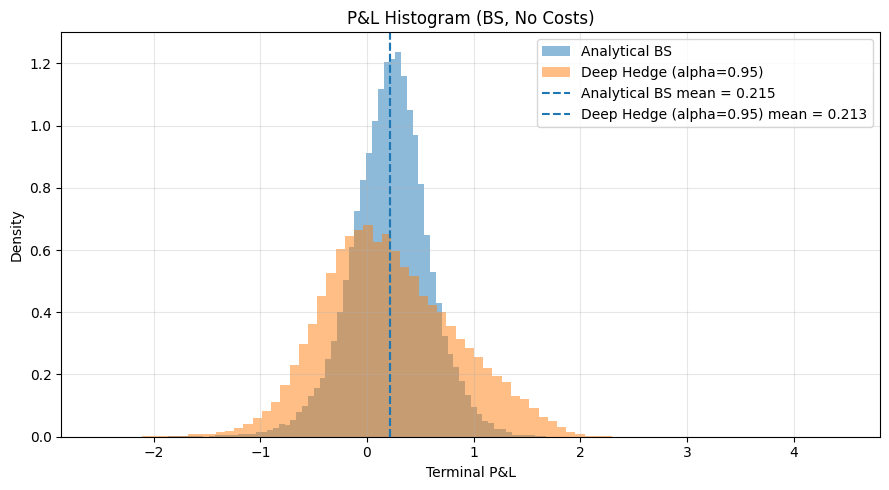

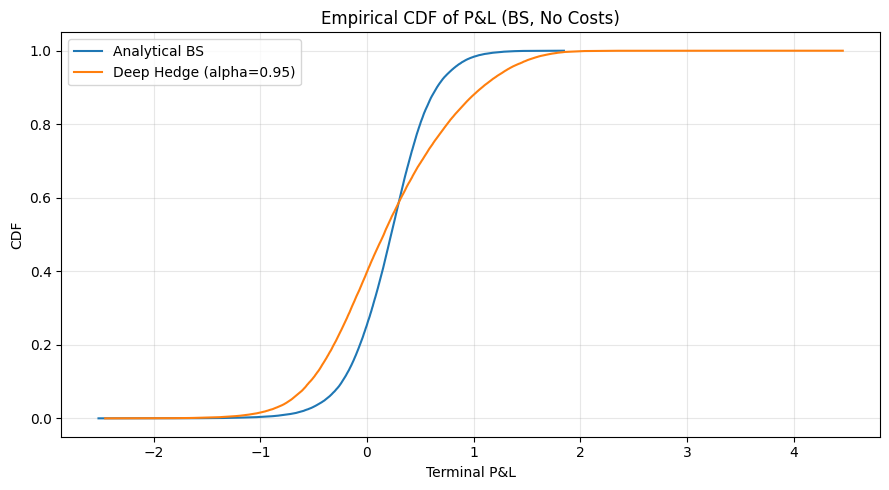

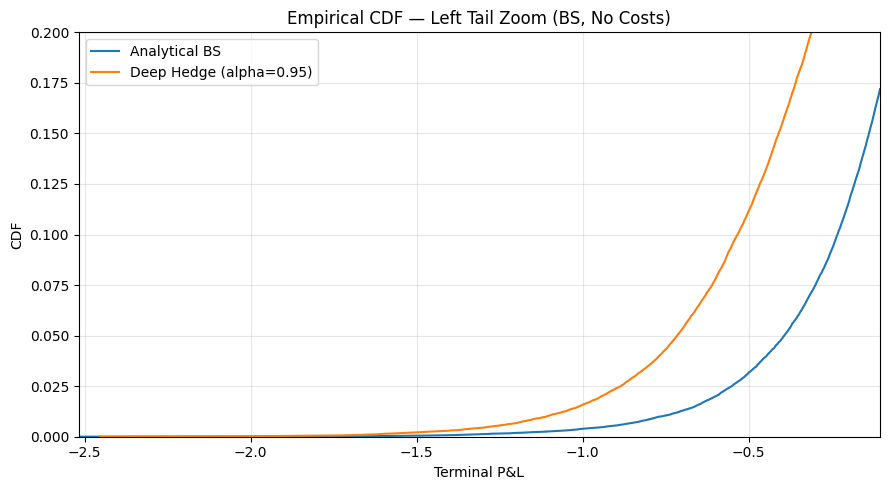

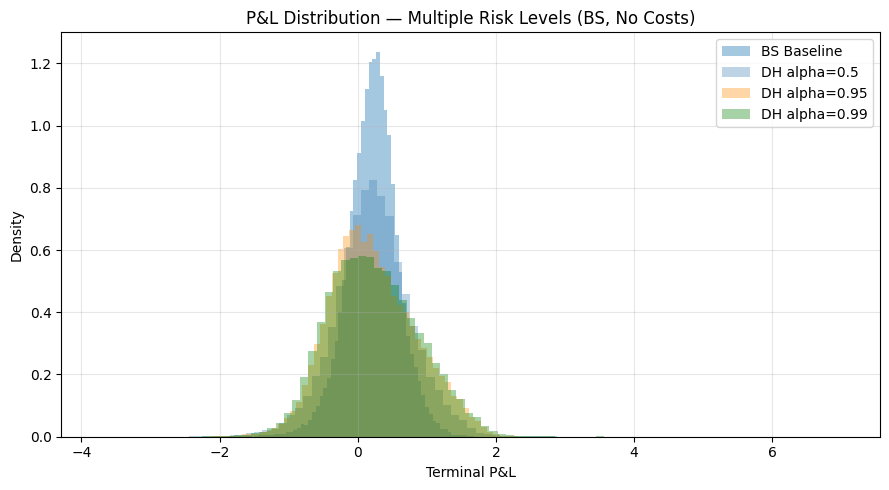

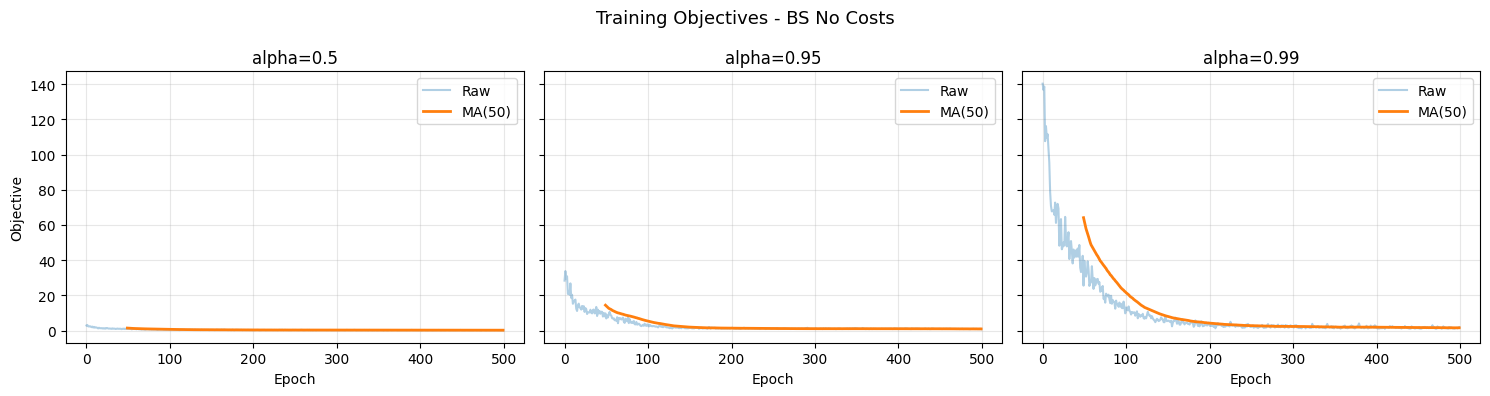

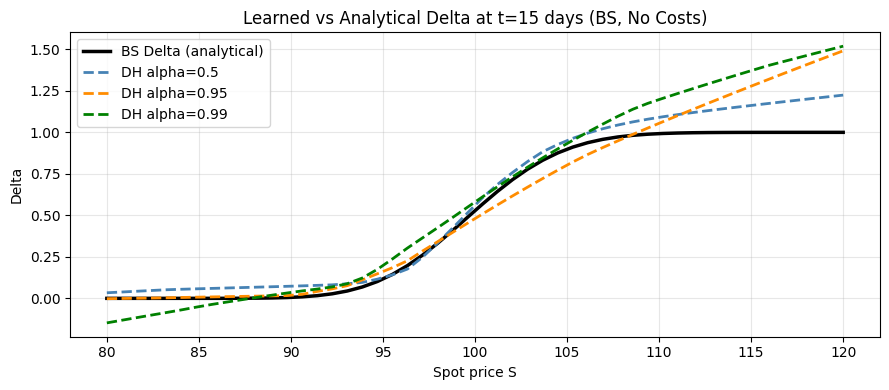

In [21]:
# 5. Plot Diagnostics
# ── 4. P&L diagnostics - main alpha
plot_pnl_diagnostics(pnl_baseline=bs_pnl_0,
                     pnl_model=dh_pnls_0[0.95],
                     baseline_name="Analytical BS",
                     model_name="Deep Hedge (alpha=0.95)",
                     title_suffix="(BS, No Costs)")

# ── 5. Overlaid PnL histogram — all alpha levels ─────────────
# Paper Figure 6/7 equivalent
pnl_bs_np = to_numpy(bs_pnl_0)
plt.figure(figsize=(9, 5))
plt.hist(pnl_bs_np, bins=80, density=True, alpha=0.4, label="BS Baseline")
colors = {0.5: "steelblue", 0.95: "darkorange", 0.99: "green"}
for alpha_level in alpha_levels:
    plt.hist(dh_pnls_0[alpha_level], bins=80, density=True, alpha=0.35,
             color=colors[alpha_level], label=f"DH alpha={alpha_level}")
plt.title("P&L Distribution — Multiple Risk Levels (BS, No Costs)")
plt.xlabel("Terminal P&L"); plt.ylabel("Density")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# ── 6. Training curves — all alpha levels ───────────────────
fig, axes = plt.subplots(1, len(alpha_levels), figsize=(15, 4), sharey=True)
for ax, alpha_level in zip(axes, alpha_levels):
    loss_hist = np.asarray(train_outs_0[alpha_level]["loss_history"])
    window    = 50
    ax.plot(loss_hist, alpha=0.35, label="Raw")
    if len(loss_hist) >= window:
        smoothed = np.convolve(loss_hist, np.ones(window) / window, mode="valid")
        ax.plot(np.arange(window - 1, len(loss_hist)), smoothed,
                linewidth=2, label=f"MA({window})")
    ax.set_title(f"alpha={alpha_level}")
    ax.set_xlabel("Epoch"); ax.legend(); ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Objective")
plt.suptitle("Training Objectives - BS No Costs", fontsize=13)
plt.tight_layout(); plt.show()

# ── 7. Learned delta vs analytical delta — all alpha levels ──
# Paper Figure 3 equivalent
t_idx  = 15
tau_15 = T - t_idx * (T / steps)
tau_14 = T - (t_idx - 1) * (T / steps)   # previous step tau
S_grid = torch.linspace(80, 120, 50, device=device)

bs_delta_grid = bs_pricer.delta(S_grid, K, tau_15).cpu().numpy()

# Realistic prev_delta: BS delta at t=14 for each spot on the grid
# This mimics what the network would actually receive as input at t=15
prev_realistic = bs_pricer.delta(S_grid, K, tau_14).unsqueeze(1)  # (50, 1)

log_grid = torch.log(S_grid / S0).unsqueeze(1)   # (50, 1)
x_grid   = torch.cat([log_grid, prev_realistic], dim=1)  # (50, 2)

plt.figure(figsize=(9, 4))
plt.plot(S_grid.cpu().numpy(), bs_delta_grid,
         label="BS Delta (analytical)", linewidth=2.5, color="black")
for alpha_level in alpha_levels:
    dh_models_0[alpha_level].eval()
    with torch.no_grad():
        dh_delta_grid = dh_models_0[alpha_level].forward_step(
            t_idx, x_grid).cpu().numpy()
    plt.plot(S_grid.cpu().numpy(), dh_delta_grid, linewidth=2,
             linestyle="--", color=colors[alpha_level],
             label=f"DH alpha={alpha_level}")

plt.xlabel("Spot price S"); plt.ylabel("Delta")
plt.title("Learned vs Analytical Delta at t=15 days (BS, No Costs)")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

### B-S with transaction costs

Now we introduce market friction by setting our transaction cost rate to 0.5%. The traditional Black-Scholes delta ignores these costs and will over-trade, racking up huge fees. Our Deep Hedging model, trained with these costs included in its PnL function, should learn to trade less aggressively, resulting in a significantly lower Turnover and a better overall CVaR.

In [22]:
# test_paths_bs and bs_pricer reused from Experiment 1 for fair comparison
print(f"Policy: {policy_type} | BatchNorm: {use_batch_norm}")
print(f"BS premium: {premium_bs:.4f}")
# ── 1. Analytical Baseline ──────────────────────────────────
print("--- Running Analytical BS Baseline (eps=0.005) ---")
bs_deltas_cost, bs_pnl_cost = run_bs_baseline(
    test_paths_bs, K, r, sigma, T,
    epsilon=epsilon, bs_pricer=bs_pricer, premium=premium_bs)

bs_metrics_cost = compute_metrics_from_pnl_and_deltas(
    bs_pnl_cost, bs_deltas_cost,
    paths=test_paths_bs, epsilon=epsilon)
print(f"Baseline CVaR(95%): {bs_metrics_cost['Loss CVaR (95%)']:.4f}")

# ── 2. Train DH (CVaR) at multiple risk levels ──────────────
alpha_levels    = [0.5, 0.95, 0.99]
colors          = {0.5: "steelblue", 0.95: "darkorange", 0.99: "green"}
dh_models_cost  = {}
dh_pnls_cost    = {}
dh_metrics_cost = {}
train_outs_cost = {}

for alpha_level in alpha_levels:
    print(f"\n--- Training DH CVaR (eps=0.005, alpha={alpha_level}) ---")
    train_out = train_model(
        env_type='bs', S0=S0, K=K, r=r, T=T, steps=steps,
        epsilon=epsilon, batch_size=batch_size, n_epochs=n_epochs,
        lr=learning_rate, sigma=sigma, premium=premium_bs,
        alpha=alpha_level, loss_type='cvar',
        policy_type=policy_type, use_batch_norm=use_batch_norm,
        hidden_dims=hidden_dim_bs)

    metrics, pnl, deltas = evaluate_model(
        train_out["model"], 'bs', test_paths_bs, K,
        epsilon=epsilon, S0=S0, T=T, premium=premium_bs)

    dh_models_cost[alpha_level]  = train_out["model"]
    dh_pnls_cost[alpha_level]    = pnl
    dh_metrics_cost[alpha_level] = metrics
    train_outs_cost[alpha_level] = train_out

# ── 3. Results tables ────────────────────────────────────────
for alpha_level in alpha_levels:
    print_results_comparison(
        title=f"BS WITH COSTS | CVaR alpha={alpha_level}",
        baseline_name="Analytical BS",
        baseline_metrics=bs_metrics_cost,
        model_name=f"DH CVaR (alpha={alpha_level})",
        model_metrics=dh_metrics_cost[alpha_level])

Policy: per_step | BatchNorm: False
BS premium: 2.4934
--- Running Analytical BS Baseline (eps=0.005) ---
Baseline CVaR(95%): 2.2071

--- Training DH CVaR (eps=0.005, alpha=0.5) ---


Training BS (CVAR):   0%|          | 0/500 [00:00<?, ?it/s]

Training completed in 13.2s | device: cuda | epochs: 500 | batch: 256

--- Training DH CVaR (eps=0.005, alpha=0.95) ---


Training BS (CVAR):   0%|          | 0/500 [00:00<?, ?it/s]

Training completed in 12.8s | device: cuda | epochs: 500 | batch: 256

--- Training DH CVaR (eps=0.005, alpha=0.99) ---


Training BS (CVAR):   0%|          | 0/500 [00:00<?, ?it/s]

Training completed in 13.4s | device: cuda | epochs: 500 | batch: 256

=== BS WITH COSTS | CVaR alpha=0.5 ===
Metric                    | Analytical BS        | DH CVaR (alpha=0.5) 
------------------------------------------------------------------------
Mean PnL                  |              -0.9085 |              -0.3986
Std PnL                   |               0.5156 |               0.7028
Loss VaR (95%)            |               1.8715 |               1.5866
Loss CVaR (95%)           |               2.2071 |               1.9911
Loss VaR (99%)            |               2.4096 |               2.2239
Loss CVaR (99%)           |               2.7284 |               2.6460
Turnover                  |               2.2481 |               1.2114
Avg Total Transaction Cost |               1.1238 |               0.6072

=== BS WITH COSTS | CVaR alpha=0.95 ===
Metric                    | Analytical BS        | DH CVaR (alpha=0.95)
-------------------------------------------------------

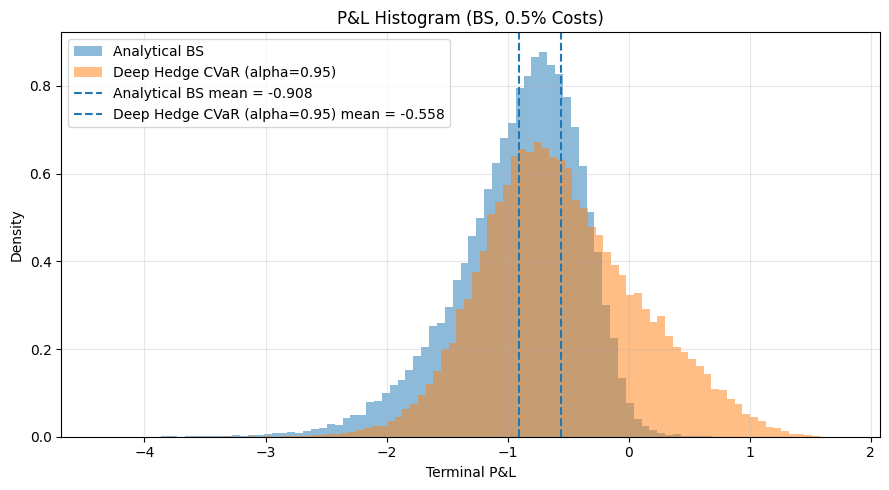

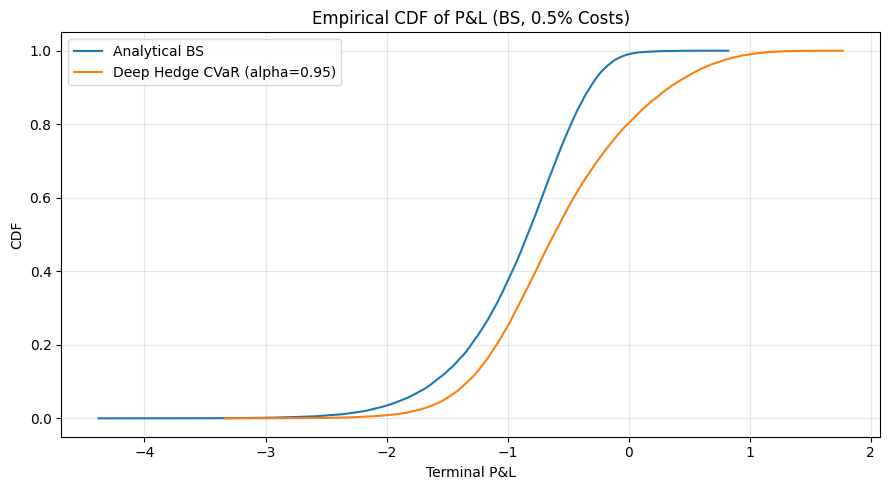

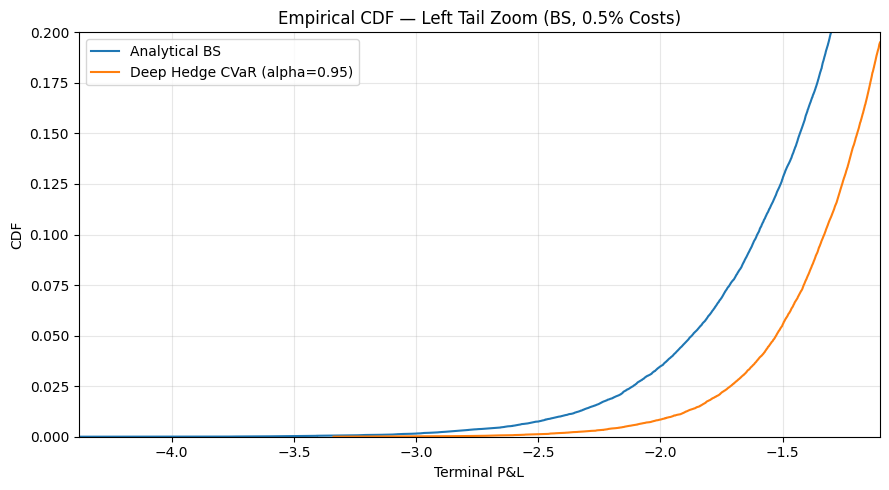

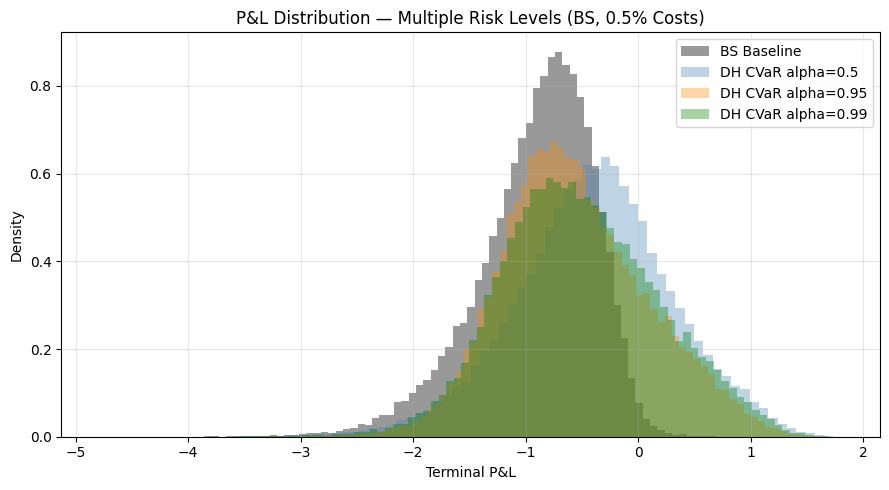

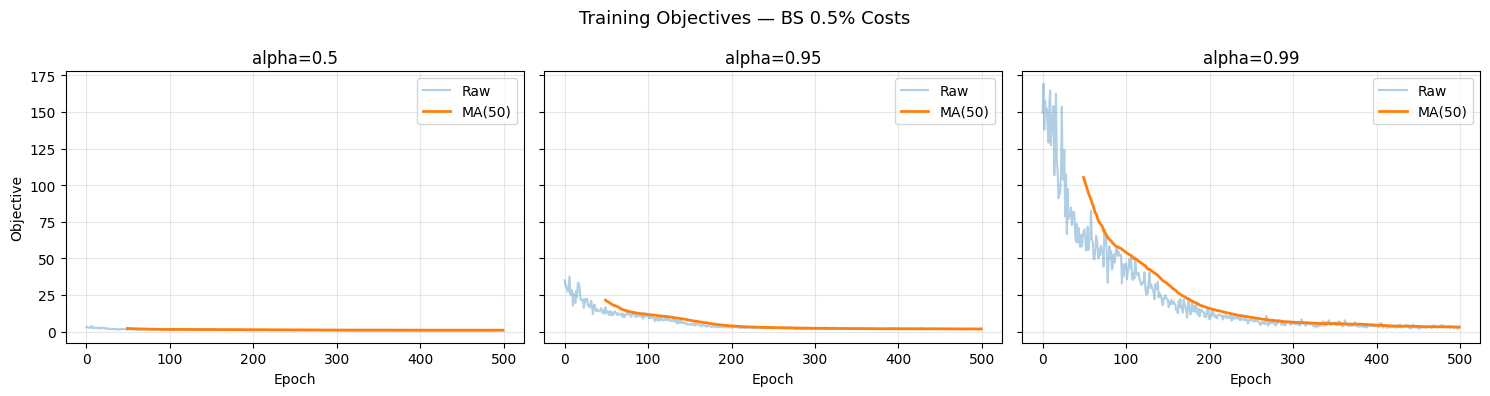

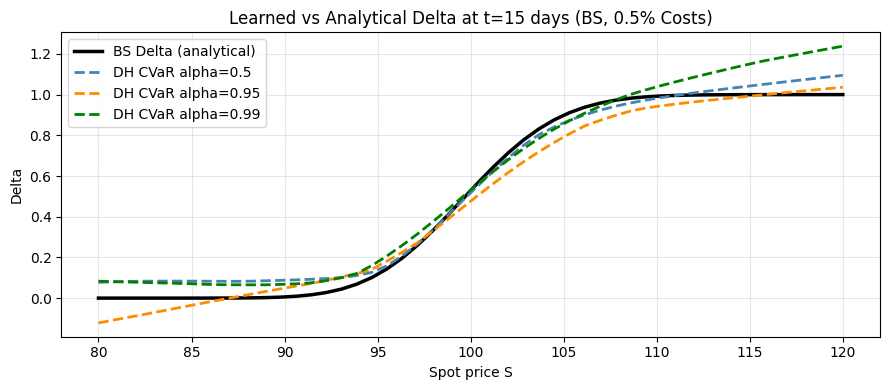


--- CVaR vs Transaction Cost Level ---


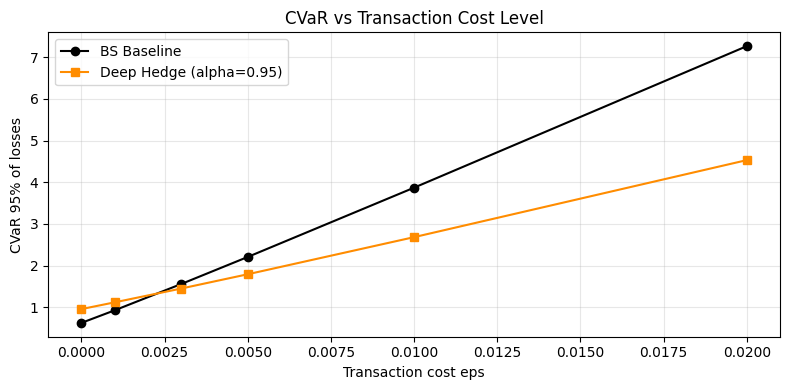

In [23]:
# ── 4. P&L diagnostics — main alpha ─────────────────────────
plot_pnl_diagnostics(pnl_baseline=bs_pnl_cost, pnl_model=dh_pnls_cost[0.95],
                     baseline_name="Analytical BS", model_name="Deep Hedge CVaR (alpha=0.95)",
                     title_suffix="(BS, 0.5% Costs)")

# ── 5. Overlaid histogram — all alpha levels ─────────────────
pnl_bs_np = to_numpy(bs_pnl_cost)
plt.figure(figsize=(9, 5))
plt.hist(pnl_bs_np, bins=80, density=True, alpha=0.4,
         label="BS Baseline", color="black")
for alpha_level in alpha_levels:
    plt.hist(dh_pnls_cost[alpha_level], bins=80, density=True,
             alpha=0.35, color=colors[alpha_level],
             label=f"DH CVaR alpha={alpha_level}")
plt.title("P&L Distribution — Multiple Risk Levels (BS, 0.5% Costs)")
plt.xlabel("Terminal P&L"); plt.ylabel("Density")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# ── 6. Training curves ───────────────────────────────────────
fig, axes = plt.subplots(1, len(alpha_levels), figsize=(15, 4), sharey=True)
for ax, alpha_level in zip(axes, alpha_levels):
    loss_hist = np.asarray(train_outs_cost[alpha_level]["loss_history"])
    window    = 50
    ax.plot(loss_hist, alpha=0.35, label="Raw")
    if len(loss_hist) >= window:
        smoothed = np.convolve(loss_hist, np.ones(window) / window, mode="valid")
        ax.plot(np.arange(window - 1, len(loss_hist)), smoothed,
                linewidth=2, label=f"MA({window})")
    ax.set_title(f"alpha={alpha_level}")
    ax.set_xlabel("Epoch"); ax.legend(); ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Objective")
plt.suptitle("Training Objectives — BS 0.5% Costs", fontsize=13)
plt.tight_layout(); plt.show()

# ── 7. Learned delta vs BS delta at t=15 ─────────────────────
t_idx  = 15
tau_15 = T - t_idx * (T / steps)
tau_14 = T - (t_idx - 1) * (T / steps)
S_grid = torch.linspace(80, 120, 50, device=device)

bs_delta_grid  = bs_pricer.delta(S_grid, K, tau_15).cpu().numpy()
prev_realistic = bs_pricer.delta(S_grid, K, tau_14).unsqueeze(1)  # (50, 1)
log_grid       = torch.log(S_grid / S0).unsqueeze(1)              # (50, 1)
x_grid         = torch.cat([log_grid, prev_realistic], dim=1)     # (50, 2)

plt.figure(figsize=(9, 4))
plt.plot(S_grid.cpu().numpy(), bs_delta_grid,
         label="BS Delta (analytical)", linewidth=2.5, color="black")
for alpha_level in alpha_levels:
    dh_models_cost[alpha_level].eval()
    with torch.no_grad():
        dh_delta_grid = dh_models_cost[alpha_level].forward_step(
            t_idx, x_grid).cpu().numpy()
    plt.plot(S_grid.cpu().numpy(), dh_delta_grid, linewidth=2,
             linestyle="--", color=colors[alpha_level],
             label=f"DH CVaR alpha={alpha_level}")
plt.xlabel("Spot price S"); plt.ylabel("Delta")
plt.title("Learned vs Analytical Delta at t=15 days (BS, 0.5% Costs)")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# ── 8. CVaR vs epsilon (professor requirement) ───────────────
print("\n--- CVaR vs Transaction Cost Level ---")
epsilon_scan = [0.0, 0.001, 0.003, 0.005, 0.01, 0.02]
cvar_bs_scan = []
cvar_dh_scan = []

for eps_scan in epsilon_scan:
    # BS baseline — recompute deltas and PnL at this epsilon
    bs_deltas_scan, pnl_bs_scan = run_bs_baseline(test_paths_bs, K, r, sigma, T, epsilon=eps_scan, bs_pricer=bs_pricer, premium=premium_bs)
    m_bs = compute_metrics_from_pnl_and_deltas(pnl_bs_scan, bs_deltas_scan, paths=test_paths_bs, epsilon=eps_scan)
    cvar_bs_scan.append(m_bs["Loss CVaR (95%)"])

    # DH alpha=0.95 — evaluate at this epsilon using trained model
    # deltas come from evaluate_model so TC is computed correctly
    m_dh, pnl_dh_scan, dh_deltas_scan = evaluate_model(dh_models_cost[0.95], 'bs', test_paths_bs, K, epsilon=eps_scan, S0=S0, T=T, premium=premium_bs)
    cvar_dh_scan.append(m_dh["Loss CVaR (95%)"])

plt.figure(figsize=(8, 4))
plt.plot(epsilon_scan, cvar_bs_scan, marker='o',
         label="BS Baseline", color="black")
plt.plot(epsilon_scan, cvar_dh_scan, marker='s',
         color="darkorange", label="Deep Hedge (alpha=0.95)")
plt.xlabel("Transaction cost eps"); plt.ylabel("CVaR 95% of losses")
plt.title("CVaR vs Transaction Cost Level")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

### B-S Hyperparameter Sensitivity on CVar

--- Network Width Sensitivity ---

Training: Small [8,8]


Training BS (CVAR):   0%|          | 0/500 [00:00<?, ?it/s]

Training completed in 12.7s | device: cuda | epochs: 500 | batch: 256

Training: Paper [16,16]


Training BS (CVAR):   0%|          | 0/500 [00:00<?, ?it/s]

Training completed in 14.3s | device: cuda | epochs: 500 | batch: 256

Training: Large [32,32]


...

Training completed in 13.4s | device: cuda | epochs: 500 | batch: 64

Training: Batch 256


Training BS (CVAR):   0%|          | 0/500 [00:00<?, ?it/s]

Training completed in 13.5s | device: cuda | epochs: 500 | batch: 256

Training: Batch 512


Training BS (CVAR):   0%|          | 0/500 [00:00<?, ?it/s]

Training completed in 13.0s | device: cuda | epochs: 500 | batch: 512

=== WIDTH SENSITIVITY (alpha=0.95, eps=0.005) ===
Config             |   Mean PnL |  CVaR(95%) |  CVaR(99%) |   Turnover
-----------------------------------------------------------------
Small [8,8]        |    -0.5922 |     2.6037 |     3.2485 |     1.6176
Paper [16,16]      |    -0.4894 |     1.7196 |     2.1313 |     1.4117
Large [32,32]      |    -0.5399 |     1.7545 |     2.1590 |     1.5036

=== BATCH SIZE SENSITIVITY (alpha=0.95, eps=0.005) ===
Config         |   Mean PnL |  CVaR(95%) |  CVaR(99%) |   Turnover
-------------------------------------------------------------
Batch 64       |    -0.5603 |     2.0165 |     2.5019 |     1.5477
Batch 256      |    -0.4979 |     1.8073 |     2.3034 |     1.4265
Batch 512      |    -0.5187 |     1.7063 |     2.1322 |     1.4711


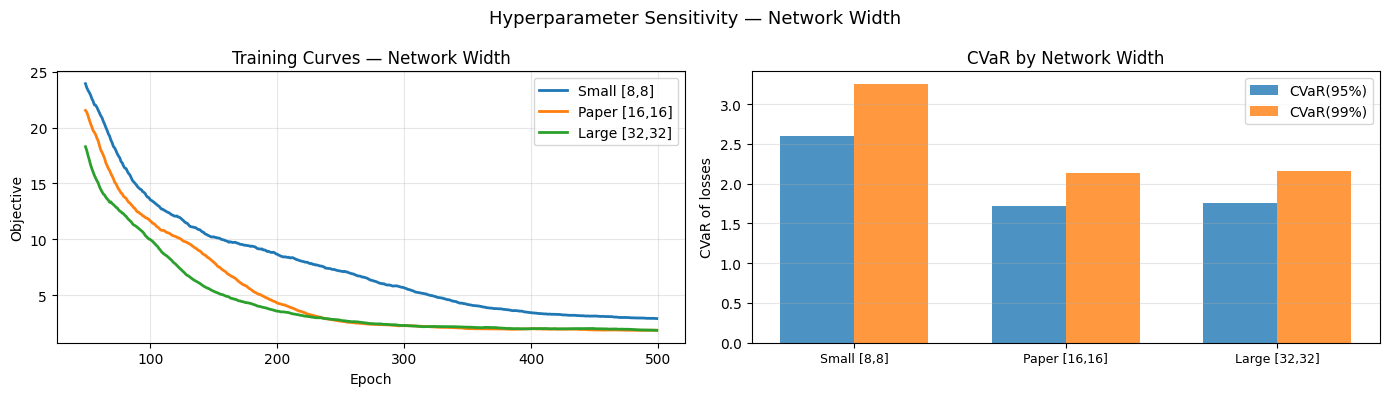

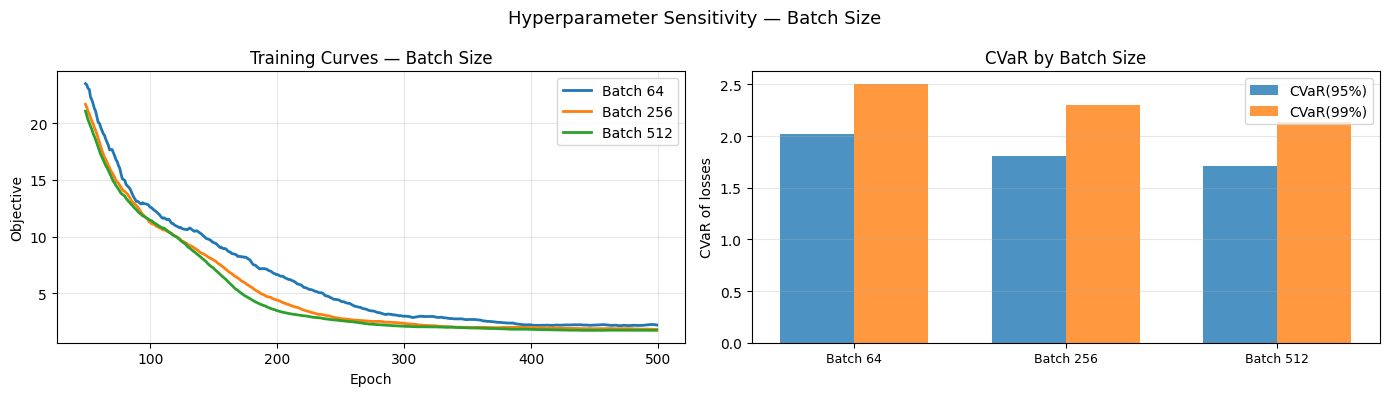

In [24]:
# ============================================================
# EXPERIMENT 3: Hyperparameter Sensitivity (professor requirement)
# Vary network width and batch size — show effect on CVaR(95%)
# Fixed: BS with costs, alpha=0.95, epsilon=0.005
# ============================================================

# ── A. Network width sensitivity ─────────────────────────────
print("--- Network Width Sensitivity ---")
width_configs = {
    'Small [8,8]':   [8,  8],
    'Paper [16,16]': [16, 16],
    'Large [32,32]': [32, 32],
}
width_results = {}

for name, hdim in width_configs.items():
    print(f"\nTraining: {name}")
    train_out = train_model(
        env_type='bs', S0=S0, K=K, r=r, T=T, steps=steps,
        epsilon=epsilon, batch_size=batch_size, n_epochs=n_epochs,
        lr=learning_rate, sigma=sigma, premium=premium_bs,
        alpha=0.95, loss_type='cvar',
        policy_type=policy_type, use_batch_norm=use_batch_norm,
        hidden_dims=hdim)

    metrics, pnl, _ = evaluate_model(
        train_out["model"], 'bs', test_paths_bs, K,
        epsilon=epsilon, S0=S0, T=T, premium=premium_bs)

    width_results[name] = {
        "CVaR (95%)":  metrics["Loss CVaR (95%)"],
        "CVaR (99%)":  metrics["Loss CVaR (99%)"],
        "Turnover":    metrics["Turnover"],
        "Mean PnL":    metrics["Mean PnL"],
        "loss_history": train_out["loss_history"],
        "pnl": pnl
    }

# ── B. Batch size sensitivity ─────────────────────────────────
print("\n--- Batch Size Sensitivity ---")
batch_configs = {
    'Batch 64':  64,
    'Batch 256': 256,   # paper default
    'Batch 512': 512,
}
batch_results = {}

for name, bsize in batch_configs.items():
    print(f"\nTraining: {name}")
    train_out = train_model(
        env_type='bs', S0=S0, K=K, r=r, T=T, steps=steps,
        epsilon=epsilon, batch_size=bsize, n_epochs=n_epochs,
        lr=learning_rate, sigma=sigma, premium=premium_bs,
        alpha=0.95, loss_type='cvar',
        policy_type=policy_type, use_batch_norm=use_batch_norm,
        hidden_dims=hidden_dim_bs)

    metrics, pnl, _ = evaluate_model(
        train_out["model"], 'bs', test_paths_bs, K,
        epsilon=epsilon, S0=S0, T=T, premium=premium_bs)

    batch_results[name] = {
        "CVaR (95%)":  metrics["Loss CVaR (95%)"],
        "CVaR (99%)":  metrics["Loss CVaR (99%)"],
        "Turnover":    metrics["Turnover"],
        "Mean PnL":    metrics["Mean PnL"],
        "loss_history": train_out["loss_history"],
        "pnl": pnl
    }

# ── C. Results table ──────────────────────────────────────────
print("\n=== WIDTH SENSITIVITY (alpha=0.95, eps=0.005) ===")
print(f"{'Config':<18} | {'Mean PnL':>10} | {'CVaR(95%)':>10} | {'CVaR(99%)':>10} | {'Turnover':>10}")
print("-" * 65)
for name, res in width_results.items():
    print(f"{name:<18} | {res['Mean PnL']:>10.4f} | {res['CVaR (95%)']:>10.4f} | {res['CVaR (99%)']:>10.4f} | {res['Turnover']:>10.4f}")

print("\n=== BATCH SIZE SENSITIVITY (alpha=0.95, eps=0.005) ===")
print(f"{'Config':<14} | {'Mean PnL':>10} | {'CVaR(95%)':>10} | {'CVaR(99%)':>10} | {'Turnover':>10}")
print("-" * 61)
for name, res in batch_results.items():
    print(f"{name:<14} | {res['Mean PnL']:>10.4f} | {res['CVaR (95%)']:>10.4f} | {res['CVaR (99%)']:>10.4f} | {res['Turnover']:>10.4f}")

# ── D. Width sensitivity plots ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Training curves
ax = axes[0]
for name, res in width_results.items():
    loss_hist = np.asarray(res["loss_history"])
    window    = 50
    if len(loss_hist) >= window:
        smoothed = np.convolve(loss_hist, np.ones(window) / window, mode="valid")
        ax.plot(np.arange(window - 1, len(loss_hist)), smoothed,
                linewidth=2, label=name)
ax.set_title("Training Curves — Network Width")
ax.set_xlabel("Epoch"); ax.set_ylabel("Objective")
ax.legend(); ax.grid(True, alpha=0.3)

# CVaR bar chart
ax = axes[1]
names  = list(width_results.keys())
c95    = [width_results[n]["CVaR (95%)"] for n in names]
c99    = [width_results[n]["CVaR (99%)"] for n in names]
x      = np.arange(len(names))
width  = 0.35
ax.bar(x - width/2, c95, width, label="CVaR(95%)", alpha=0.8)
ax.bar(x + width/2, c99, width, label="CVaR(99%)", alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(names, fontsize=9)
ax.set_title("CVaR by Network Width")
ax.set_ylabel("CVaR of losses")
ax.legend(); ax.grid(True, alpha=0.3, axis='y')

plt.suptitle("Hyperparameter Sensitivity — Network Width", fontsize=13)
plt.tight_layout(); plt.show()

# ── E. Batch size sensitivity plots ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
for name, res in batch_results.items():
    loss_hist = np.asarray(res["loss_history"])
    window    = 50
    if len(loss_hist) >= window:
        smoothed = np.convolve(loss_hist, np.ones(window) / window, mode="valid")
        ax.plot(np.arange(window - 1, len(loss_hist)), smoothed,
                linewidth=2, label=name)
ax.set_title("Training Curves — Batch Size")
ax.set_xlabel("Epoch"); ax.set_ylabel("Objective")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
names  = list(batch_results.keys())
c95    = [batch_results[n]["CVaR (95%)"] for n in names]
c99    = [batch_results[n]["CVaR (99%)"] for n in names]
x      = np.arange(len(names))
ax.bar(x - width/2, c95, width, label="CVaR(95%)", alpha=0.8)
ax.bar(x + width/2, c99, width, label="CVaR(99%)", alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(names, fontsize=9)
ax.set_title("CVaR by Batch Size")
ax.set_ylabel("CVaR of losses")
ax.legend(); ax.grid(True, alpha=0.3, axis='y')

plt.suptitle("Hyperparameter Sensitivity — Batch Size", fontsize=13)
plt.tight_layout(); plt.show()

### B-S with Entropic Risk Measure

In this experiment, we switch our loss function from CVaR to the Entropic Risk Measure ($\lambda = 1.0$) under proportional transaction costs ($\epsilon = 0.005$).

This exactly replicates the objective function used by the authors to calculate the exponential utility indifference price.

We expect the network to find a strategy that balances variance reduction with transaction cost savings.

In [25]:
# ============================================================
# EXPERIMENT 4: Black-Scholes — Entropic Risk Measure (ε=0.5%)
# Purpose: compare CVaR vs Entropic as training objectives
# ============================================================

print(f"Policy: {policy_type} | BatchNorm: {use_batch_norm}")
print(f"BS premium: {premium_bs:.4f}")

# ── 1. Train Entropic model ───────────────────────────────────
print("\n--- Training DH Entropic (eps=0.005, lambda=1.0) ---")
train_out_bs_entropic = train_model(
    env_type='bs', S0=S0, K=K, r=r, T=T, steps=steps,
    epsilon=epsilon, batch_size=batch_size, n_epochs=n_epochs,
    lr=learning_rate, sigma=sigma, premium=premium_bs,
    loss_type='entropic', lambda_param=1.0,
    policy_type=policy_type, use_batch_norm=use_batch_norm,
    hidden_dims=hidden_dim_bs)
model_bs_entropic = train_out_bs_entropic["model"]

# ── 2. Evaluate ───────────────────────────────────────────────
print("\n--- Evaluating Entropic Model ---")
metrics_bs_entropic, entropic_pnl, entropic_deltas = evaluate_model(
    model_bs_entropic, 'bs', test_paths_bs, K,
    epsilon=epsilon, S0=S0, T=T, premium=premium_bs)

# ── 3. Three-way comparison table ────────────────────────────
# CVaR reference: use alpha=0.95 from experiment 2
print_results_comparison(
    title="BS WITH COSTS | CVaR (alpha=0.95) vs Entropic (lambda=1.0)",
    baseline_name="Analytical BS",
    baseline_metrics=bs_metrics_cost,
    model_name="DH CVaR (alpha=0.95)",
    model_metrics=dh_metrics_cost[0.95])

print_results_comparison(
    title="BS WITH COSTS | Entropic (lambda=1.0)",
    baseline_name="Analytical BS",
    baseline_metrics=bs_metrics_cost,
    model_name="DH Entropic (lambda=1.0)",
    model_metrics=metrics_bs_entropic)

# Full three-way table
metric_order = ["Mean PnL", "Std PnL", "Loss VaR (95%)", "Loss CVaR (95%)",
                "Loss VaR (99%)", "Loss CVaR (99%)", "Turnover",
                "Avg Total Transaction Cost"]
print(f"\n=== THREE-WAY COMPARISON (BS, 0.5% Costs) ===")
print(f"{'Metric':<25} | {'Analytical BS':>15} | {'DH CVaR alpha=0.95':>16} | {'DH Entropic lambda=1':>16}")
print("-" * 80)
for m in metric_order:
    print(f"{m:<25} | {bs_metrics_cost[m]:>15.4f} | "
          f"{dh_metrics_cost[0.95][m]:>16.4f} | "
          f"{metrics_bs_entropic[m]:>16.4f}")

Policy: per_step | BatchNorm: False
BS premium: 2.4934

--- Training DH Entropic (eps=0.005, lambda=1.0) ---


Training BS (ENTROPIC):   0%|          | 0/500 [00:00<?, ?it/s]

Training completed in 13.6s | device: cuda | epochs: 500 | batch: 256

--- Evaluating Entropic Model ---

=== BS WITH COSTS | CVaR (alpha=0.95) vs Entropic (lambda=1.0) ===
Metric                    | Analytical BS        | DH CVaR (alpha=0.95)
------------------------------------------------------------------------
Mean PnL                  |              -0.9085 |              -0.5583
Std PnL                   |               0.5156 |               0.6437
Loss VaR (95%)            |               1.8715 |               1.5267
Loss CVaR (95%)           |               2.2071 |               1.7922
Loss VaR (99%)            |               2.4096 |               1.9530
Loss CVaR (99%)           |               2.7284 |               2.2154
Turnover                  |               2.2481 |               1.5402
Avg Total Transaction Cost |               1.1238 |               0.7731

=== BS WITH COSTS | Entropic (lambda=1.0) ===
Metric                    | Analytical BS        | DH Entr

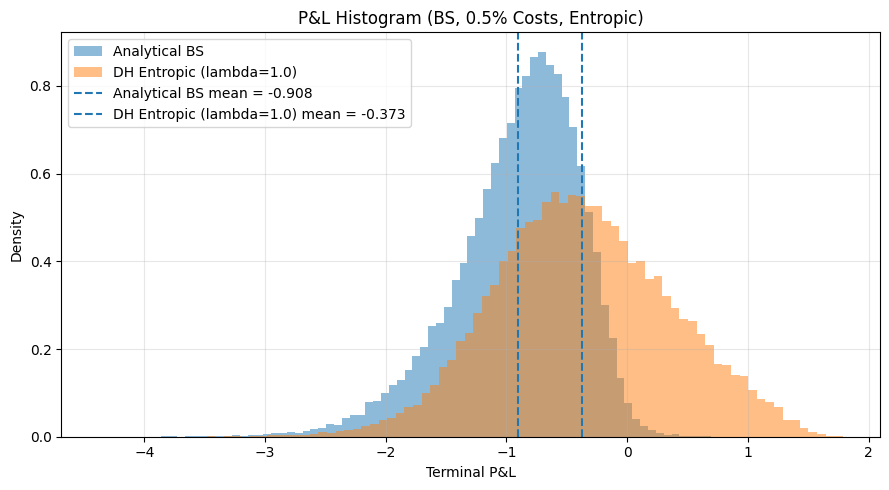

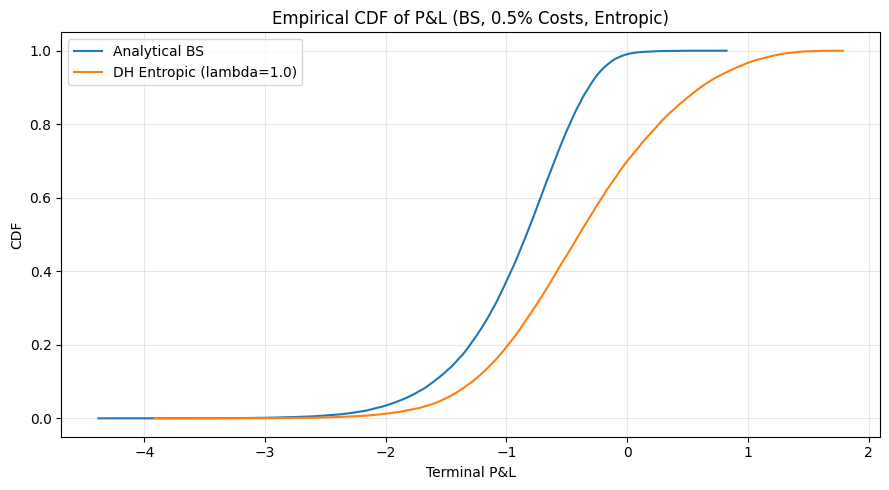

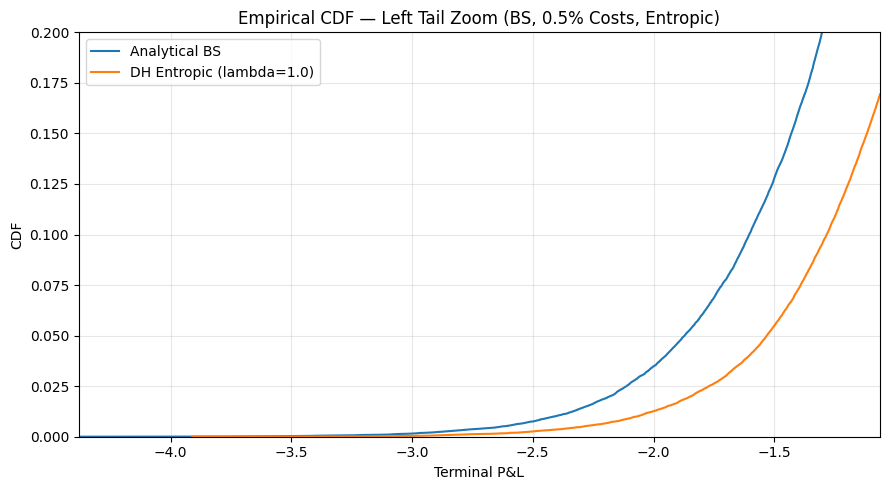

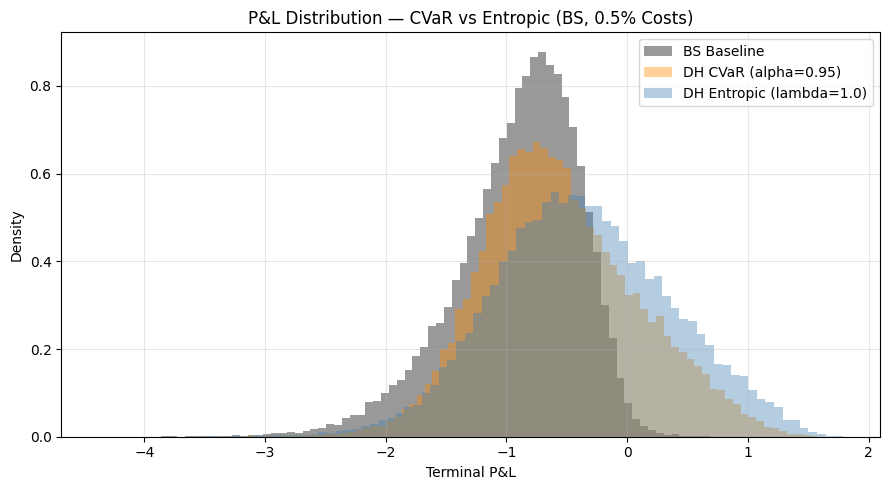

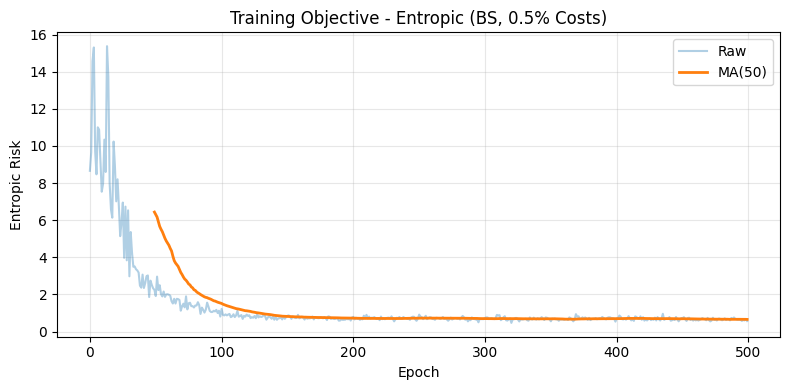

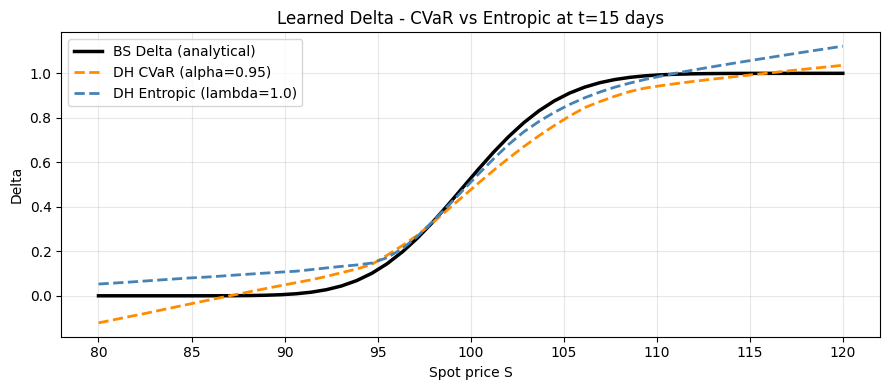

In [26]:
# ── 4. P&L diagnostics ───────────────────────────────────────
plot_pnl_diagnostics(
    pnl_baseline=bs_pnl_cost,
    pnl_model=entropic_pnl,
    baseline_name="Analytical BS",
    model_name="DH Entropic (lambda=1.0)",
    title_suffix="(BS, 0.5% Costs, Entropic)")

# ── 5. Overlaid histogram — CVaR vs Entropic ─────────────────
plt.figure(figsize=(9, 5))
plt.hist(to_numpy(bs_pnl_cost), bins=80, density=True,
         alpha=0.4, color="black", label="BS Baseline")
plt.hist(dh_pnls_cost[0.95], bins=80, density=True,
         alpha=0.4, color="darkorange", label="DH CVaR (alpha=0.95)")
plt.hist(entropic_pnl, bins=80, density=True,
         alpha=0.4, color="steelblue", label="DH Entropic (lambda=1.0)")
plt.title("P&L Distribution — CVaR vs Entropic (BS, 0.5% Costs)")
plt.xlabel("Terminal P&L"); plt.ylabel("Density")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# ── 6. Training curve ─────────────────────────────────────────
loss_hist = np.asarray(train_out_bs_entropic["loss_history"])
window    = 50
plt.figure(figsize=(8, 4))
if len(loss_hist) >= window:
    smoothed = np.convolve(loss_hist, np.ones(window) / window, mode="valid")
    plt.plot(loss_hist, alpha=0.35, label="Raw")
    plt.plot(np.arange(window - 1, len(loss_hist)), smoothed,
             linewidth=2, label=f"MA({window})")
else:
    plt.plot(loss_hist, label="Objective")
plt.title("Training Objective - Entropic (BS, 0.5% Costs)")
plt.xlabel("Epoch"); plt.ylabel("Entropic Risk")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# ── 7. Delta comparison — CVaR vs Entropic ───────────────────
t_idx  = 15
tau_15 = T - t_idx * (T / steps)
tau_14 = T - (t_idx - 1) * (T / steps)
S_grid = torch.linspace(80, 120, 50, device=device)

bs_delta_grid  = bs_pricer.delta(S_grid, K, tau_15).cpu().numpy()
prev_realistic = bs_pricer.delta(S_grid, K, tau_14).unsqueeze(1)
log_grid       = torch.log(S_grid / S0).unsqueeze(1)
x_grid         = torch.cat([log_grid, prev_realistic], dim=1)

model_bs_entropic.eval()
dh_models_cost[0.95].eval()
with torch.no_grad():
    delta_entropic = model_bs_entropic.forward_step(t_idx, x_grid).cpu().numpy()
    delta_cvar     = dh_models_cost[0.95].forward_step(t_idx, x_grid).cpu().numpy()

plt.figure(figsize=(9, 4))
plt.plot(S_grid.cpu().numpy(), bs_delta_grid,
         label="BS Delta (analytical)", linewidth=2.5, color="black")
plt.plot(S_grid.cpu().numpy(), delta_cvar, linewidth=2,
         linestyle="--", color="darkorange", label="DH CVaR (alpha=0.95)")
plt.plot(S_grid.cpu().numpy(), delta_entropic, linewidth=2,
         linestyle="--", color="steelblue", label="DH Entropic (lambda=1.0)")
plt.xlabel("Spot price S"); plt.ylabel("Delta")
plt.title("Learned Delta - CVaR vs Entropic at t=15 days")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## Heston

### Heston with transaction costs (CVaR)

Our final experiment tests the deep hedging framework in a much more complex environment: the Heston model. Here, volatility is no longer constant but follows its own stochastic process. The baseline relies on a computationally heavy finite-difference Monte Carlo approach.

Our Deep Hedging network takes three inputs at each step ($I_k$): the log-spot price, the current variance, and the previous position. It learns to balance the risks of both the asset's price movements and the volatility surface changes, all while navigating transaction costs.

In [ ]:
policy_type    = "per_step"
use_batch_norm = False
n_epochs = 1000

# 1. Generate test set
print("--- Generating Heston Test Set ---")
test_paths_h, test_vols_h, test_S2_h = generate_heston_paths(S0, v0, r, kappa, theta, sigma_v, rho, T, steps, n_paths_sim)

# 2. Pricer + Baseline
print("--- Running Numerical Heston Baseline ---")
heston_pricer = HestonPricer(S0=S0, r=r, kappa=kappa, theta=theta, xi=sigma_v,
                              rho=rho, v0=v0, device=device, dtype=torch.float64)
premium_h = heston_pricer.call_price(K, T)
print(f"Heston premium: {premium_h:.4f}")

h_deltas_base, h_pnl_base = run_heston_baseline(
    test_paths_h, test_vols_h, test_S2_h,
    K=K, T=T, epsilon=epsilon,
    heston_pricer=heston_pricer, premium=premium_h)    # ← new signature

h_metrics_base = compute_metrics_from_pnl_and_deltas(
    h_pnl_base, h_deltas_base,
    paths=test_paths_h, epsilon=epsilon, paths2=test_S2_h, S0_norm=S0)               # ← no paths2 needed
print(f"Baseline CVaR(95%): {h_metrics_base['Loss CVaR (95%)']:.4f}")

# ── 3. Train DH at multiple risk levels ──────────────────────
alpha_levels    = [0.5, 0.95, 0.99]
colors          = {0.5: "steelblue", 0.95: "darkorange", 0.99: "green"}
dh_models_h     = {}
dh_pnls_h       = {}
dh_metrics_h    = {}
train_outs_h    = {}

for alpha_level in alpha_levels:
    print(f"\n--- Training DH Heston (alpha={alpha_level}) ---")
    train_out = train_model(env_type='heston', S0=S0, K=K, r=r, T=T, steps=steps,
                            epsilon=epsilon, batch_size=batch_size, n_epochs=n_epochs,
                            lr=learning_rate, hidden_dims=hidden_dim_heston,
                            v0=v0, kappa=kappa, theta=theta, sigma_v=sigma_v, rho=rho,
                            premium=premium_h, alpha=alpha_level, loss_type='cvar',
                            policy_type=policy_type, use_batch_norm=use_batch_norm)

    metrics, pnl, deltas = evaluate_model(train_out["model"], 'heston', test_paths_h, K,
                                          epsilon=epsilon, S0=S0, T=T,
                                          test_vols=test_vols_h, test_paths2=test_S2_h,
                                          premium=premium_h, v0=v0)                      

    dh_models_h[alpha_level]  = train_out["model"]
    dh_pnls_h[alpha_level]    = pnl
    dh_metrics_h[alpha_level] = metrics
    train_outs_h[alpha_level] = train_out

# 4. Results tables 
for alpha_level in alpha_levels:
    print_results_comparison(title=f"HESTON WITH COSTS | CVaR alpha={alpha_level}",
                             baseline_name="Numerical Heston",
                             baseline_metrics=h_metrics_base,
                             model_name=f"DH CVaR (alpha={alpha_level})",
                             model_metrics=dh_metrics_h[alpha_level])


--- Generating Heston Test Set ---
--- Running Numerical Heston Baseline ---
Heston premium: 1.9552
Baseline CVaR(95%): 2.7698

--- Training DH Heston (alpha=0.5) ---


Training HESTON (CVAR):   0%|          | 0/1000 [00:00<?, ?it/s]

Training completed in 29.2s | device: cuda | epochs: 1000 | batch: 256

--- Training DH Heston (alpha=0.95) ---


Training HESTON (CVAR):   0%|          | 0/1000 [00:00<?, ?it/s]

Training completed in 30.6s | device: cuda | epochs: 1000 | batch: 256

--- Training DH Heston (alpha=0.99) ---


Training HESTON (CVAR):   0%|          | 0/1000 [00:00<?, ?it/s]

Training completed in 29.9s | device: cuda | epochs: 1000 | batch: 256

=== HESTON WITH COSTS | CVaR alpha=0.5 ===
Metric                    | Numerical Heston     | DH CVaR (alpha=0.5) 
------------------------------------------------------------------------
Mean PnL                  |              -0.8420 |              -0.1156
Std PnL                   |               0.7243 |               1.6086
Loss VaR (95%)            |               2.2124 |               3.2154
Loss CVaR (95%)           |               2.7698 |               4.9431
Loss VaR (99%)            |               3.0900 |               5.9535
Loss CVaR (99%)           |               3.6691 |               7.8660
Turnover                  |            2600.1035 |               0.4198
Avg Total Transaction Cost |               1.1369 |               0.2081

=== HESTON WITH COSTS | CVaR alpha=0.95 ===
Metric                    | Numerical Heston     | DH CVaR (alpha=0.95)
----------------------------------------------

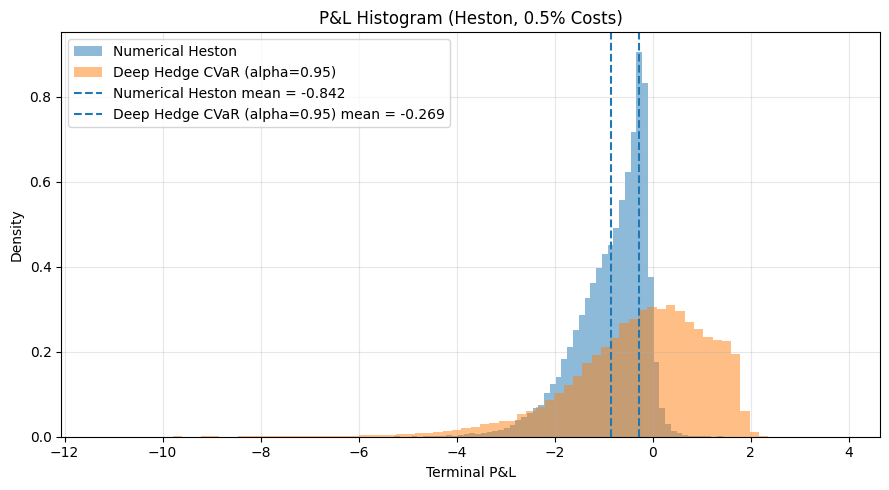

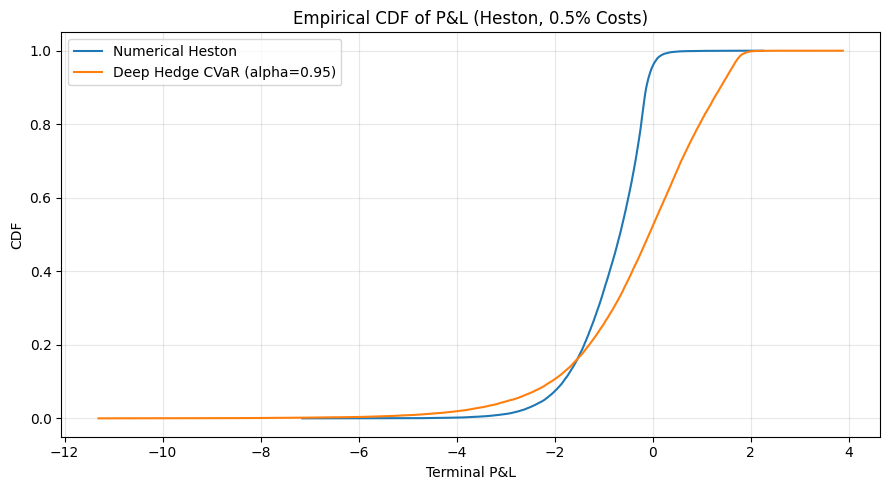

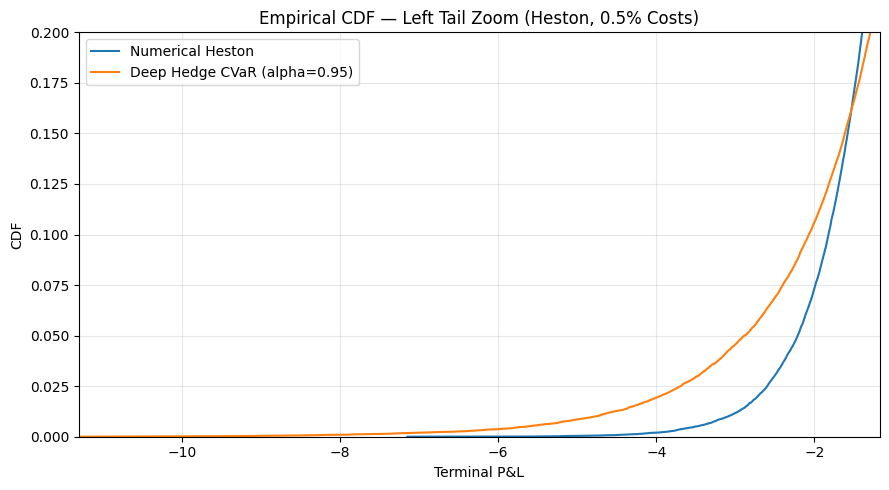

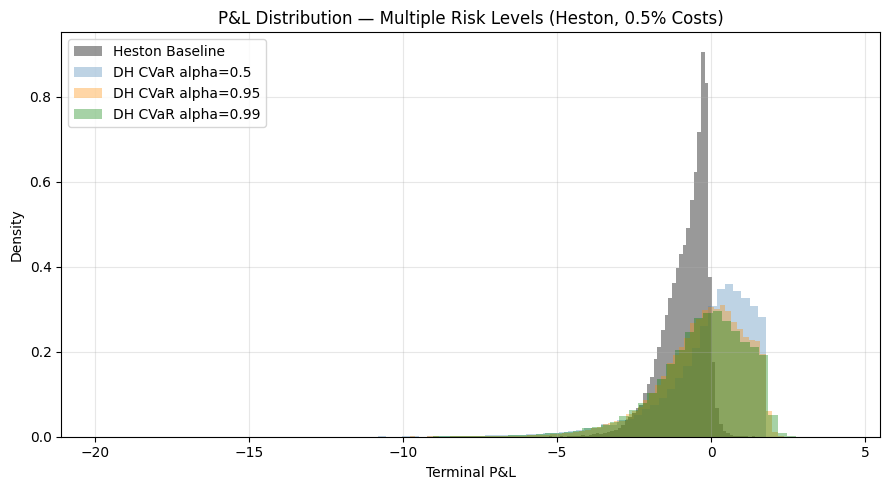

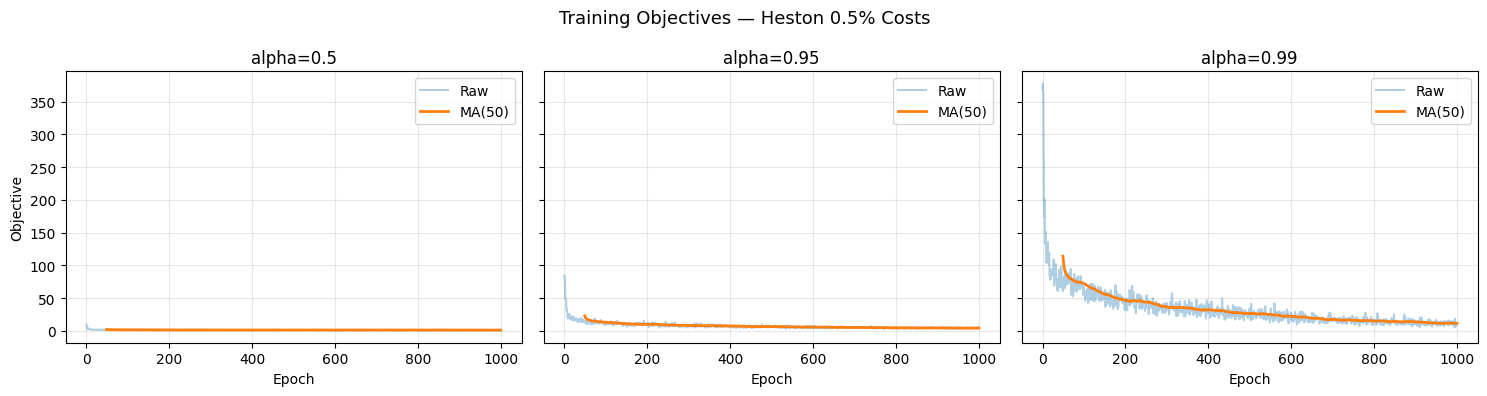


--- Generating Delta Surface ---


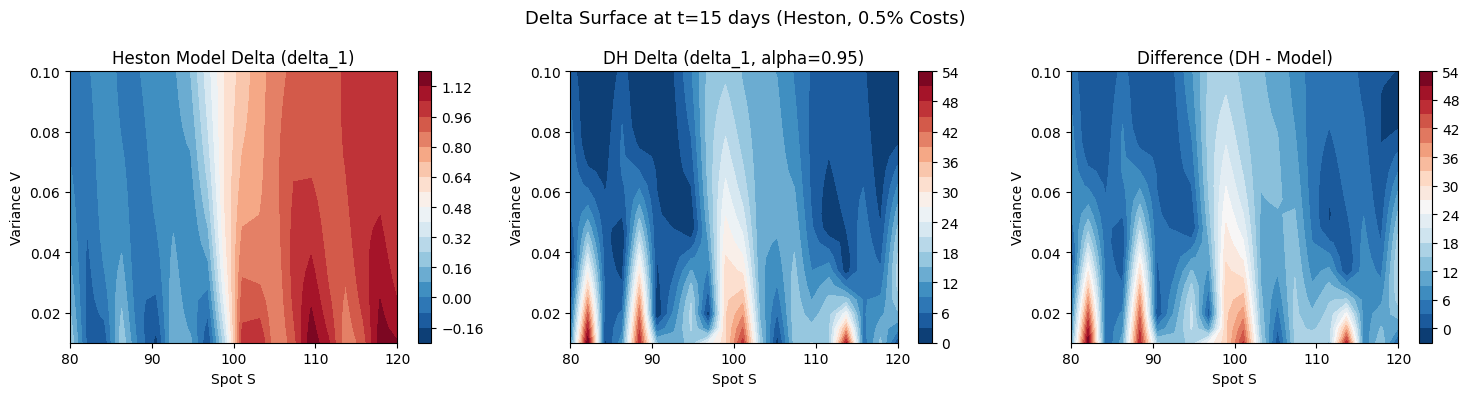

In [28]:
# ── 5. P&L diagnostics — main alpha ─────────────────────────
plot_pnl_diagnostics(pnl_baseline=h_pnl_base, pnl_model=dh_pnls_h[0.95],
                     baseline_name="Numerical Heston", model_name="Deep Hedge CVaR (alpha=0.95)",
                     title_suffix="(Heston, 0.5% Costs)")

# ── 6. Overlaid histogram — all alpha levels ─────────────────
plt.figure(figsize=(9, 5))
plt.hist(to_numpy(h_pnl_base), bins=80, density=True,
         alpha=0.4, color="black", label="Heston Baseline")
for alpha_level in alpha_levels:
    plt.hist(dh_pnls_h[alpha_level], bins=80, density=True,
             alpha=0.35, color=colors[alpha_level],
             label=f"DH CVaR alpha={alpha_level}")
plt.title("P&L Distribution — Multiple Risk Levels (Heston, 0.5% Costs)")
plt.xlabel("Terminal P&L"); plt.ylabel("Density")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# ── 7. Training curves ───────────────────────────────────────
fig, axes = plt.subplots(1, len(alpha_levels), figsize=(15, 4), sharey=True)
for ax, alpha_level in zip(axes, alpha_levels):
    loss_hist = np.asarray(train_outs_h[alpha_level]["loss_history"])
    window    = 50
    ax.plot(loss_hist, alpha=0.35, label="Raw")
    if len(loss_hist) >= window:
        smoothed = np.convolve(loss_hist, np.ones(window) / window, mode="valid")
        ax.plot(np.arange(window - 1, len(loss_hist)), smoothed,
                linewidth=2, label=f"MA({window})")
    ax.set_title(f"alpha={alpha_level}")
    ax.set_xlabel("Epoch"); ax.legend(); ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Objective")
plt.suptitle("Training Objectives — Heston 0.5% Costs", fontsize=13)
plt.tight_layout(); plt.show()

# ── 8. Delta surface — learned vs model at t=15 ──────────────
# Paper Figure 3 equivalent for Heston: visualize over (S, V) grid
print("\n--- Generating Delta Surface ---")
t_idx   = 15
tau_15  = T - t_idx * (T / steps)
tau_14  = T - (t_idx - 1) * (T / steps)

S_grid_np = np.linspace(80, 120, 20)
V_grid_np = np.linspace(0.01, 0.10, 20)
SS, VV    = np.meshgrid(S_grid_np, V_grid_np)  # (20, 20)
S_flat    = SS.flatten()   # (400,)
V_flat    = VV.flatten()   # (400,)

# Analytical Heston delta on grid
tau_flat  = np.full(len(S_flat), tau_15)
h_delta_grid = to_numpy(heston_pricer.delta(
    S_flat, V_flat, tau_flat, K)).reshape(20, 20)

# DH delta on grid (alpha=0.95)
S_t   = to_tensor(S_flat)
V_t   = to_tensor(V_flat)

# Realistic prev_delta: use model Heston delta at t=14
tau_flat_14   = np.full(len(S_flat), tau_14)
prev_d1       = to_tensor(to_numpy(heston_pricer.delta(
    S_flat, V_flat, tau_flat_14, K))).unsqueeze(1)   # (400, 1)
prev_d2       = to_tensor(to_numpy(heston_pricer.vega_swap(
    S_flat, V_flat, tau_flat_14, K))).unsqueeze(1)   # (400, 1)

log_grid_h = torch.log(S_t / S0).unsqueeze(1)        # (400, 1)
vol_norm   = (V_t / v0).unsqueeze(1)                  # (400, 1)
prev_delta = torch.cat([prev_d1, prev_d2], dim=1)     # (400, 2)
x_grid_h   = torch.cat([log_grid_h, vol_norm, prev_delta], dim=1)  # (400, 4)

dh_models_h[0.95].eval()
with torch.no_grad():
    dh_out       = dh_models_h[0.95].forward_step(t_idx, x_grid_h)  # (400, 2)
    dh_delta_grid = dh_out[:, 0].cpu().numpy().reshape(20, 20)
    dh_vega_grid  = dh_out[:, 1].cpu().numpy().reshape(20, 20)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
im0 = axes[0].contourf(SS, VV, h_delta_grid,  levels=20, cmap='RdBu_r')
axes[0].set_title("Heston Model Delta (delta_1)"); plt.colorbar(im0, ax=axes[0])
im1 = axes[1].contourf(SS, VV, dh_delta_grid, levels=20, cmap='RdBu_r')
axes[1].set_title("DH Delta (delta_1, alpha=0.95)");  plt.colorbar(im1, ax=axes[1])
im2 = axes[2].contourf(SS, VV, dh_delta_grid - h_delta_grid,
                        levels=20, cmap='RdBu_r')
axes[2].set_title("Difference (DH - Model)"); plt.colorbar(im2, ax=axes[2])
for ax in axes:
    ax.set_xlabel("Spot S"); ax.set_ylabel("Variance V")
plt.suptitle("Delta Surface at t=15 days (Heston, 0.5% Costs)", fontsize=13)
plt.tight_layout(); plt.show()

### Heston with Entropic Risk Measure

In this experiment we switch the loss function to the Entropic Risk Measure ($\lambda=1.0$) in the Heston environment with proportional transaction costs ($\epsilon=0.5%$).
This replicates the objective used by the paper authors to compute the exponential
utility indifference price in a stochastic volatility setting.
We compare it against the numerical Heston baseline and the CVaR ($\alpha=0.95$) model
trained earlier to understand the practical difference between the two risk objectives.

Policy: per_step | BatchNorm: False
Heston premium: 1.9552

--- Training DH Heston Entropic (eps=0.005, lambda=1.0) ---


Training HESTON (ENTROPIC):   0%|          | 0/1000 [00:00<?, ?it/s]

Training completed in 30.1s | device: cuda | epochs: 1000 | batch: 256

--- Evaluating Heston Entropic model ---

=== HESTON WITH COSTS | CVaR (alpha=0.95) vs Baseline ===
Metric                    | Numerical Heston     | DH CVaR (alpha=0.95)
------------------------------------------------------------------------
Mean PnL                  |              -0.8420 |              -0.2686
Std PnL                   |               0.7243 |               1.4299
Loss VaR (95%)            |               2.2124 |               2.8869
Loss CVaR (95%)           |               2.7698 |               4.0867
Loss VaR (99%)            |               3.0900 |               4.7749
Loss CVaR (99%)           |               3.6691 |               6.0774
Turnover                  |            2600.1035 |               0.7716
Avg Total Transaction Cost |               1.1369 |               0.3837

=== HESTON WITH COSTS | Entropic (lambda=1.0) vs Baseline ===
Metric                    | Numerical Hesto

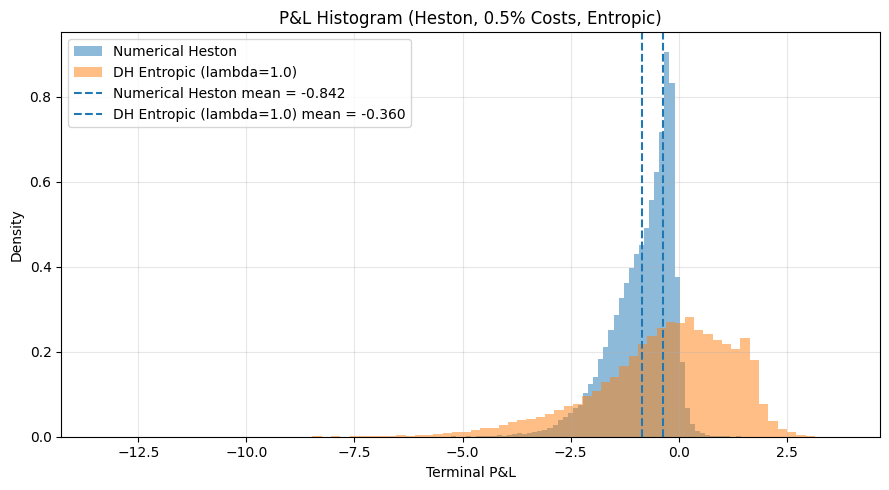

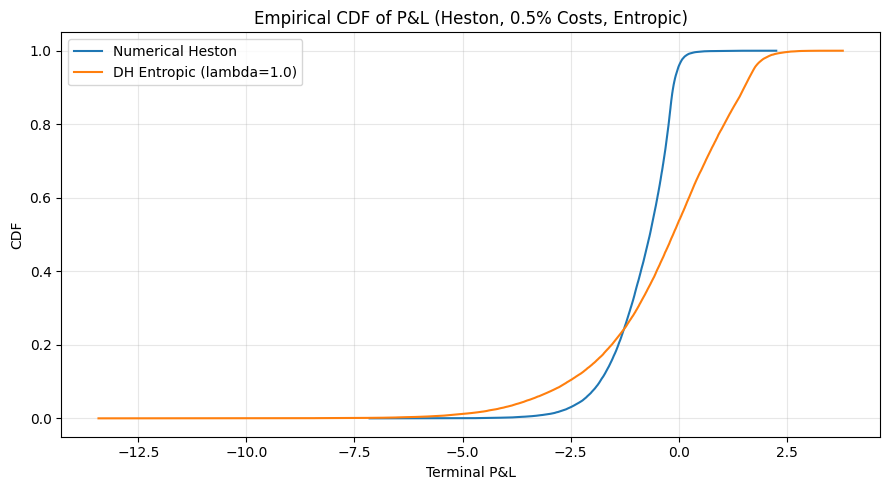

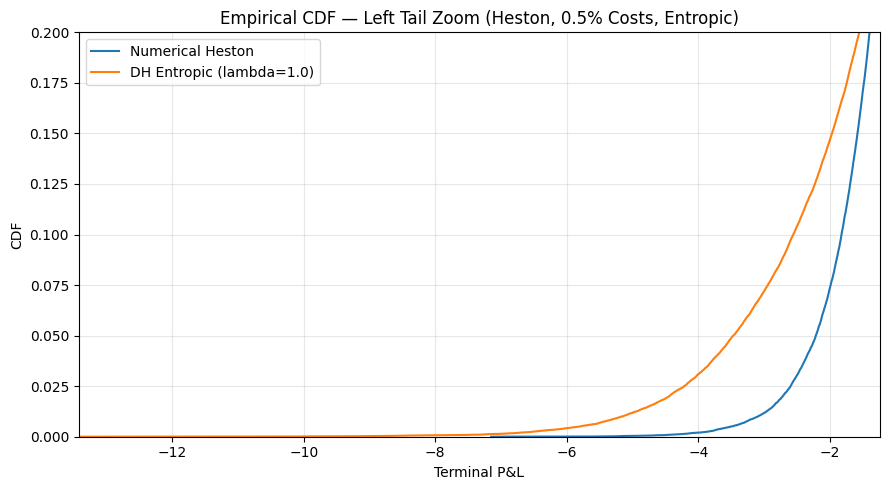

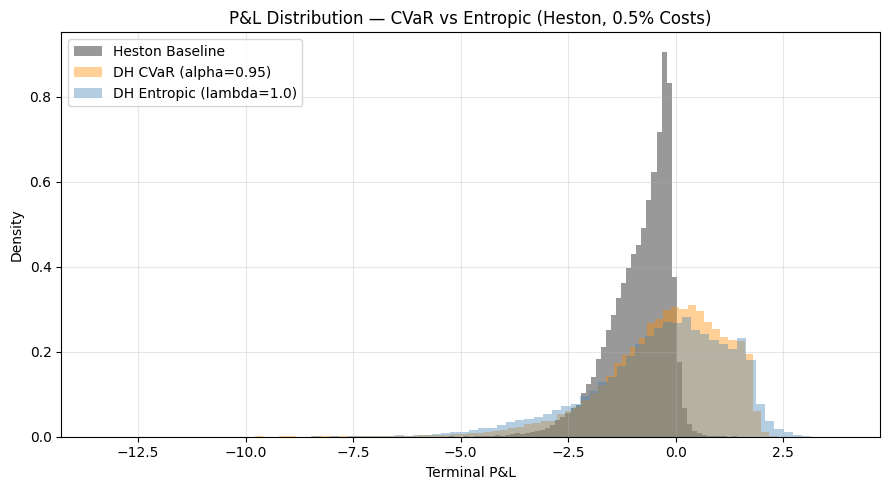

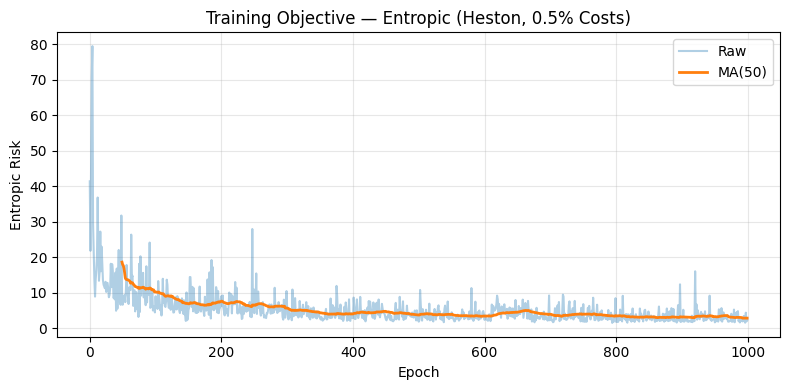


--- Generating Delta Surface: CVaR vs Entropic ---


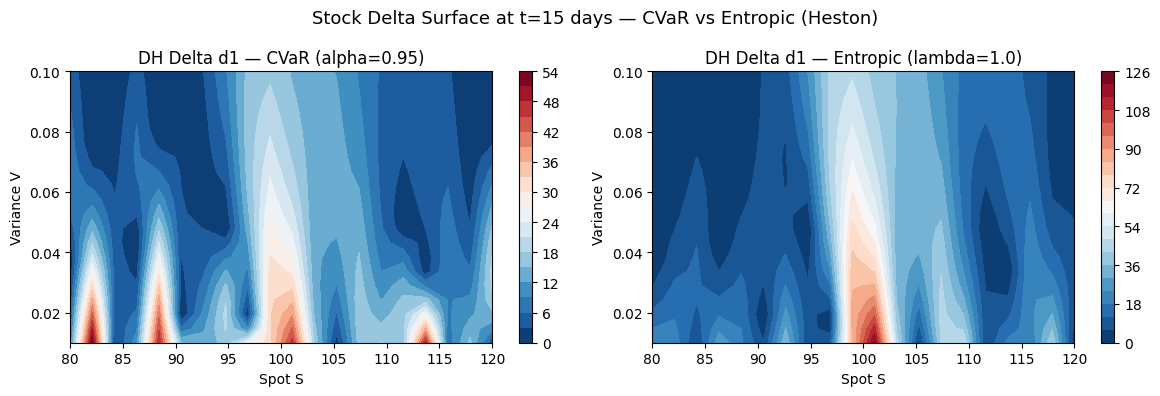

In [34]:
# ============================================================
# Heston — Entropic Risk Measure (ε=0.5%, λ=1.0)
# ============================================================

print(f"Policy: {policy_type} | BatchNorm: {use_batch_norm}")
print(f"Heston premium: {premium_h:.4f}")

# ── 1. Train Entropic model ───────────────────────────────────
print("\n--- Training DH Heston Entropic (eps=0.005, lambda=1.0) ---")
train_out_h_entropic = train_model(
    env_type='heston', S0=S0, K=K, r=r, T=T, steps=steps,
    epsilon=epsilon, batch_size=batch_size, n_epochs=n_epochs,
    lr=learning_rate, hidden_dims=hidden_dim_heston,
    v0=v0, kappa=kappa, theta=theta, sigma_v=sigma_v, rho=rho,
    premium=premium_h, loss_type='entropic', lambda_param=1.0,
    policy_type=policy_type, use_batch_norm=use_batch_norm)

# ── 2. Evaluate ───────────────────────────────────────────────
print("\n--- Evaluating Heston Entropic model ---")
metrics_h_entropic, pnl_h_entropic, deltas_h_entropic = evaluate_model(
    train_out_h_entropic["model"], 'heston', test_paths_h, K,
    epsilon=epsilon, S0=S0, T=T,
    test_vols=test_vols_h, test_paths2=test_S2_h,
    premium=premium_h, v0=v0)

# ── 3. Two-way comparison tables ─────────────────────────────
print_results_comparison(
    title="HESTON WITH COSTS | CVaR (alpha=0.95) vs Baseline",
    baseline_name="Numerical Heston",
    baseline_metrics=h_metrics_base,
    model_name="DH CVaR (alpha=0.95)",
    model_metrics=dh_metrics_h[0.95])

print_results_comparison(
    title="HESTON WITH COSTS | Entropic (lambda=1.0) vs Baseline",
    baseline_name="Numerical Heston",
    baseline_metrics=h_metrics_base,
    model_name="DH Entropic (lambda=1.0)",
    model_metrics=metrics_h_entropic)

# ── 4. Full three-way comparison table ───────────────────────
metric_order = ["Mean PnL", "Std PnL", "Loss VaR (95%)", "Loss CVaR (95%)",
                "Loss VaR (99%)", "Loss CVaR (99%)", "Turnover",
                "Avg Total Transaction Cost"]

print(f"\n=== THREE-WAY COMPARISON (Heston, 0.5% Costs) ===")
print(f"{'Metric':<25} | {'Heston Baseline':>15} | {'DH CVaR a=0.95':>15} | {'DH Entropic l=1':>15}")
print("-" * 80)
for m in metric_order:
    b  = h_metrics_base.get(m, float('nan'))
    c  = dh_metrics_h[0.95].get(m, float('nan'))
    e  = metrics_h_entropic.get(m, float('nan'))
    print(f"{m:<25} | {b:>15.4f} | {c:>15.4f} | {e:>15.4f}")

# ── 5. P&L diagnostics ───────────────────────────────────────
plot_pnl_diagnostics(
    pnl_baseline=h_pnl_base,
    pnl_model=pnl_h_entropic,
    baseline_name="Numerical Heston",
    model_name="DH Entropic (lambda=1.0)",
    title_suffix="(Heston, 0.5% Costs, Entropic)")

# ── 6. Overlaid histogram — CVaR vs Entropic ─────────────────
plt.figure(figsize=(9, 5))
plt.hist(to_numpy(h_pnl_base), bins=80, density=True,
         alpha=0.4, color="black", label="Heston Baseline")
plt.hist(to_numpy(dh_pnls_h[0.95]), bins=80, density=True,
         alpha=0.4, color="darkorange", label="DH CVaR (alpha=0.95)")
plt.hist(pnl_h_entropic, bins=80, density=True,
         alpha=0.4, color="steelblue", label="DH Entropic (lambda=1.0)")
plt.title("P&L Distribution — CVaR vs Entropic (Heston, 0.5% Costs)")
plt.xlabel("Terminal P&L"); plt.ylabel("Density")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# ── 7. Training curve ─────────────────────────────────────────
loss_hist = np.asarray(train_out_h_entropic["loss_history"])
window    = 50
plt.figure(figsize=(8, 4))
plt.plot(loss_hist, alpha=0.35, label="Raw")
if len(loss_hist) >= window:
    smoothed = np.convolve(loss_hist, np.ones(window) / window, mode="valid")
    plt.plot(np.arange(window - 1, len(loss_hist)), smoothed,
             linewidth=2, label=f"MA({window})")
plt.title("Training Objective — Entropic (Heston, 0.5% Costs)")
plt.xlabel("Epoch"); plt.ylabel("Entropic Risk")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# ── 8. Delta comparison — CVaR vs Entropic on (S,V) grid ─────
print("\n--- Generating Delta Surface: CVaR vs Entropic ---")
t_idx  = 15
tau_15 = T - t_idx * (T / steps)
tau_14 = T - (t_idx - 1) * (T / steps)

S_grid_np = np.linspace(80, 120, 20)
V_grid_np = np.linspace(0.01, 0.10, 20)
SS, VV    = np.meshgrid(S_grid_np, V_grid_np)
S_flat, V_flat = SS.flatten(), VV.flatten()

S_t = to_tensor(S_flat)
V_t = to_tensor(V_flat)

tau_flat_14 = np.full(len(S_flat), tau_14)
prev_d1 = to_tensor(to_numpy(heston_pricer.delta(
    S_flat, V_flat, tau_flat_14, K))).unsqueeze(1)     # (400, 1)
prev_d2 = to_tensor(to_numpy(heston_pricer.vega_swap(
    S_flat, V_flat, tau_flat_14, K))).unsqueeze(1)     # (400, 1)

log_grid_h = torch.log(S_t / S0).unsqueeze(1)         # (400, 1)
vol_norm   = (V_t / v0).unsqueeze(1)                   # (400, 1)
prev_delta = torch.cat([prev_d1, prev_d2], dim=1)      # (400, 2)
x_grid_h   = torch.cat([log_grid_h, vol_norm, prev_delta], dim=1)  # (400, 4)

dh_models_h[0.95].eval()
train_out_h_entropic["model"].eval()

with torch.no_grad():
    out_cvar     = dh_models_h[0.95].forward_step(t_idx, x_grid_h)
    out_entropic = train_out_h_entropic["model"].forward_step(t_idx, x_grid_h)

    d1_cvar     = out_cvar[:,     0].cpu().numpy().reshape(20, 20)
    d1_entropic = out_entropic[:, 0].cpu().numpy().reshape(20, 20)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
im0 = axes[0].contourf(SS, VV, d1_cvar,     levels=20, cmap='RdBu_r')
axes[0].set_title("DH Delta d1 — CVaR (alpha=0.95)")
plt.colorbar(im0, ax=axes[0])
im1 = axes[1].contourf(SS, VV, d1_entropic, levels=20, cmap='RdBu_r')
axes[1].set_title("DH Delta d1 — Entropic (lambda=1.0)")
plt.colorbar(im1, ax=axes[1])
for ax in axes:
    ax.set_xlabel("Spot S"); ax.set_ylabel("Variance V")
plt.suptitle("Stock Delta Surface at t=15 days — CVaR vs Entropic (Heston)", fontsize=13)
plt.tight_layout(); plt.show()

### Heston CVaR vs Transaction Cost Level

This experiment scans across a range of transaction cost levels ε and measures
the 95% CVaR of losses for both the numerical Heston baseline and the trained
Deep Hedging model (CVaR α=0.95).

It answers the key practical question: **at what cost level does Deep Hedging
start outperforming the classical model hedge?** The classical baseline ignores
transaction costs entirely when computing its deltas, so its CVaR degrades
faster as ε grows. The Deep Hedging model, trained at ε=0.005, has already
learned to trade less aggressively — but note it was not retrained at each ε,
so the crossover point is a lower bound on its true advantage.

--- Heston CVaR vs Transaction Cost Level ---
  Scanning epsilon = 0.0000...
  Scanning epsilon = 0.0010...
  Scanning epsilon = 0.0030...
  Scanning epsilon = 0.0050...
  Scanning epsilon = 0.0100...
  Scanning epsilon = 0.0200...

=== HESTON CVaR vs EPSILON SCAN ===
 epsilon |  Base CVaR95 |    DH CVaR95 |  Base CVaR99 |    DH CVaR99 |  Base Mean |    DH Mean
-------------------------------------------------------------------------------------
  0.0000 |       0.8648 |       3.4718 |       1.5441 |       5.3138 |     0.2949 |     0.1151
  0.0010 |       1.2168 |       3.5935 |       1.9475 |       5.4646 |     0.0675 |     0.0384
  0.0030 |       1.9713 |       3.8388 |       2.7911 |       5.7692 |    -0.3872 |    -0.1151
  0.0050 |       2.7698 |       4.0867 |       3.6691 |       6.0774 |    -0.8420 |    -0.2686
  0.0100 |       4.8581 |       4.7139 |       5.9600 |       6.8595 |    -1.9788 |    -0.6522
  0.0200 |       9.1785 |       6.0041 |      10.7528 |       8.4647 |    -

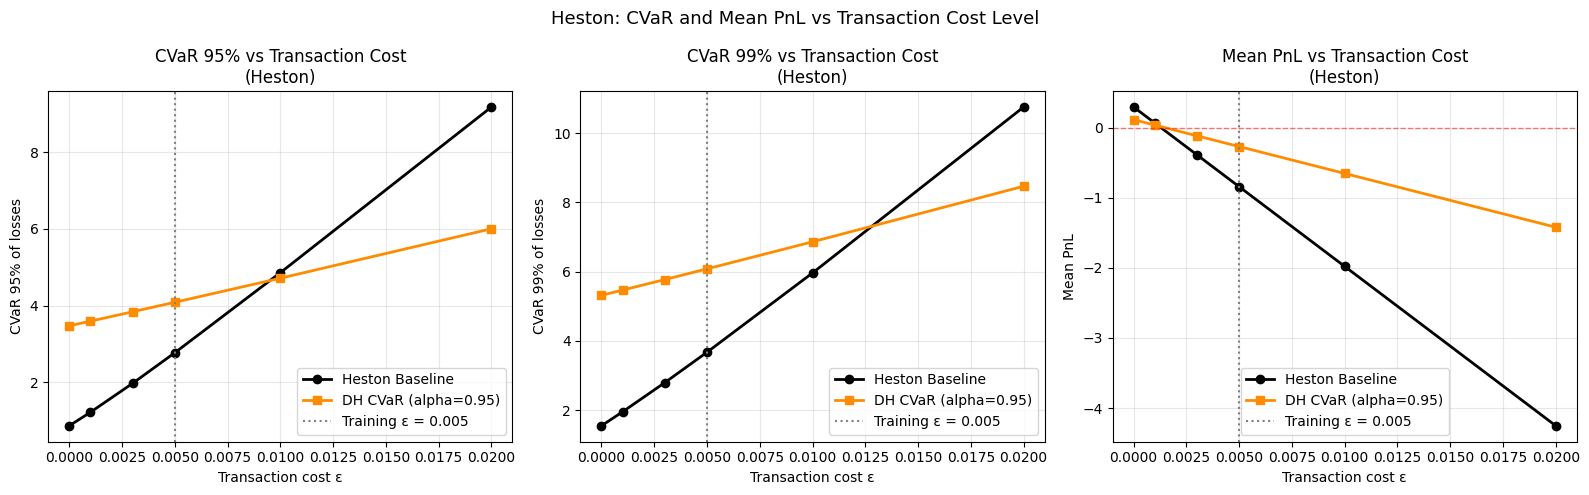

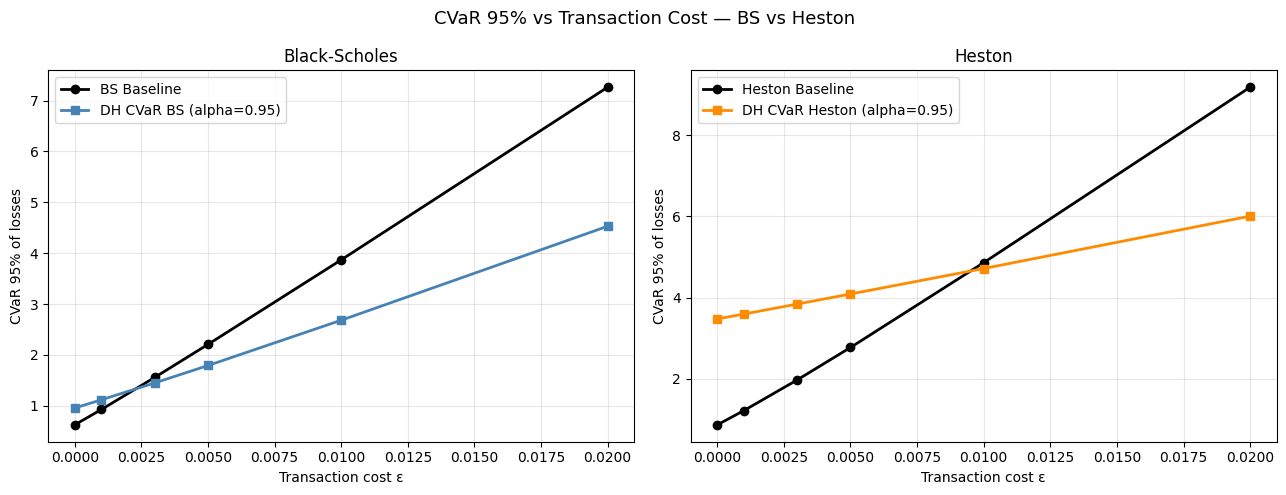

In [30]:
# ============================================================
# Heston CVaR vs Transaction Cost Level
# ============================================================

print("--- Heston CVaR vs Transaction Cost Level ---")

epsilon_scan_h = [0.0, 0.001, 0.003, 0.005, 0.01, 0.02]

cvar_95_base_h = []
cvar_95_dh_h   = []
cvar_99_base_h = []
cvar_99_dh_h   = []
mean_base_h    = []
mean_dh_h      = []

for eps_s in epsilon_scan_h:
    print(f"  Scanning epsilon = {eps_s:.4f}...")

    # ── Numerical Heston baseline at this epsilon ─────────────
    d_base_s, pnl_base_s = run_heston_baseline(
        test_paths_h, test_vols_h, test_S2_h,
        K=K, T=T, epsilon=eps_s,
        heston_pricer=heston_pricer, premium=premium_h)

    m_base_s = compute_metrics_from_pnl_and_deltas(
        pnl_base_s, d_base_s,
        paths=test_paths_h, epsilon=eps_s, paths2=test_S2_h, S0_norm=S0)

    cvar_95_base_h.append(m_base_s["Loss CVaR (95%)"])
    cvar_99_base_h.append(m_base_s["Loss CVaR (99%)"])
    mean_base_h.append(m_base_s["Mean PnL"])

    # ── Deep Hedge CVaR model (trained at eps=0.005) ──────────
    # We evaluate the already-trained model at different epsilon values.
    # This shows how robust the learned policy is outside its training cost.
    m_dh_s, _, _ = evaluate_model(
        dh_models_h[0.95], 'heston', test_paths_h, K,
        epsilon=eps_s, S0=S0, T=T,
        test_vols=test_vols_h, test_paths2=test_S2_h,
        premium=premium_h, v0=v0)

    cvar_95_dh_h.append(m_dh_s["Loss CVaR (95%)"])
    cvar_99_dh_h.append(m_dh_s["Loss CVaR (99%)"])
    mean_dh_h.append(m_dh_s["Mean PnL"])

# ── Numeric summary table ─────────────────────────────────────
print(f"\n=== HESTON CVaR vs EPSILON SCAN ===")
print(f"{'epsilon':>8} | {'Base CVaR95':>12} | {'DH CVaR95':>12} | "
      f"{'Base CVaR99':>12} | {'DH CVaR99':>12} | {'Base Mean':>10} | {'DH Mean':>10}")
print("-" * 85)
for i, eps_s in enumerate(epsilon_scan_h):
    print(f"{eps_s:>8.4f} | {cvar_95_base_h[i]:>12.4f} | {cvar_95_dh_h[i]:>12.4f} | "
          f"{cvar_99_base_h[i]:>12.4f} | {cvar_99_dh_h[i]:>12.4f} | "
          f"{mean_base_h[i]:>10.4f} | {mean_dh_h[i]:>10.4f}")

# ── Plots ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: CVaR 95%
axes[0].plot(epsilon_scan_h, cvar_95_base_h, 'o-',
             color='black', linewidth=2, label='Heston Baseline')
axes[0].plot(epsilon_scan_h, cvar_95_dh_h,   's-',
             color='darkorange', linewidth=2, label='DH CVaR (alpha=0.95)')
axes[0].axvline(x=epsilon, color='gray', linestyle=':', linewidth=1.5,
                label=f'Training ε = {epsilon}')
axes[0].set_xlabel('Transaction cost ε')
axes[0].set_ylabel('CVaR 95% of losses')
axes[0].set_title('CVaR 95% vs Transaction Cost\n(Heston)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Middle: CVaR 99%
axes[1].plot(epsilon_scan_h, cvar_99_base_h, 'o-',
             color='black', linewidth=2, label='Heston Baseline')
axes[1].plot(epsilon_scan_h, cvar_99_dh_h,   's-',
             color='darkorange', linewidth=2, label='DH CVaR (alpha=0.95)')
axes[1].axvline(x=epsilon, color='gray', linestyle=':', linewidth=1.5,
                label=f'Training ε = {epsilon}')
axes[1].set_xlabel('Transaction cost ε')
axes[1].set_ylabel('CVaR 99% of losses')
axes[1].set_title('CVaR 99% vs Transaction Cost\n(Heston)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Right: Mean PnL (shows profitability degradation under costs)
axes[2].plot(epsilon_scan_h, mean_base_h, 'o-',
             color='black', linewidth=2, label='Heston Baseline')
axes[2].plot(epsilon_scan_h, mean_dh_h,   's-',
             color='darkorange', linewidth=2, label='DH CVaR (alpha=0.95)')
axes[2].axvline(x=epsilon, color='gray', linestyle=':', linewidth=1.5,
                label=f'Training ε = {epsilon}')
axes[2].axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
axes[2].set_xlabel('Transaction cost ε')
axes[2].set_ylabel('Mean PnL')
axes[2].set_title('Mean PnL vs Transaction Cost\n(Heston)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Heston: CVaR and Mean PnL vs Transaction Cost Level', fontsize=13)
plt.tight_layout()
plt.show()

# ── Side-by-side with BS scan (from cell 64) ─────────────────
try:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].plot(epsilon_scan,   cvar_bs_scan,    'o-', color='black',
                 linewidth=2, label='BS Baseline')
    axes[0].plot(epsilon_scan,   cvar_dh_scan,    's-', color='steelblue',
                 linewidth=2, label='DH CVaR BS (alpha=0.95)')
    axes[0].set_xlabel('Transaction cost ε')
    axes[0].set_ylabel('CVaR 95% of losses')
    axes[0].set_title('Black-Scholes')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(epsilon_scan_h, cvar_95_base_h,  'o-', color='black',
                 linewidth=2, label='Heston Baseline')
    axes[1].plot(epsilon_scan_h, cvar_95_dh_h,    's-', color='darkorange',
                 linewidth=2, label='DH CVaR Heston (alpha=0.95)')
    axes[1].set_xlabel('Transaction cost ε')
    axes[1].set_ylabel('CVaR 95% of losses')
    axes[1].set_title('Heston')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.suptitle('CVaR 95% vs Transaction Cost — BS vs Heston', fontsize=13)
    plt.tight_layout()
    plt.show()

except NameError:
    # BS scan variables not in scope — skip the comparison panel
    print("Note: run BS experiment (cell 64) first to see BS vs Heston comparison.")

### Heston Hyperparameter Sensitivity

This experiment studies how sensitive the Deep Hedging model is to two key
hyperparameters in the Heston environment: network width and batch size.

For each configuration we train from scratch, evaluate on the same fixed
out-of-sample test set, and report CVaR 95%, CVaR 99%, Turnover and Mean PnL.
All other settings are held constant: α=0.95, ε=0.005, 1000 epochs, per-step policy.

This directly mirrors the BS sensitivity study and allows a side-by-side
comparison of how much architecture choices matter in a stochastic volatility
setting vs a constant-volatility one.

--- Heston Network Width Sensitivity ---

  Training: Small  [8, 8]


Training HESTON (CVAR):   0%|          | 0/1000 [00:00<?, ?it/s]

Training completed in 30.6s | device: cuda | epochs: 1000 | batch: 256

  Training: Paper [17,17]


Training HESTON (CVAR):   0%|          | 0/1000 [00:00<?, ?it/s]

Training completed in 30.3s | device: cuda | epochs: 1000 | batch: 256

  Training: Large [32,32]


...

Training completed in 29.3s | device: cuda | epochs: 1000 | batch: 64

  Training: Batch 256


Training HESTON (CVAR):   0%|          | 0/1000 [00:00<?, ?it/s]

Training completed in 31.1s | device: cuda | epochs: 1000 | batch: 256

  Training: Batch 512


Training HESTON (CVAR):   0%|          | 0/1000 [00:00<?, ?it/s]

Training completed in 30.6s | device: cuda | epochs: 1000 | batch: 512

=== HESTON WIDTH SENSITIVITY (alpha=0.95, eps=0.005) ===
Config             |   Mean PnL |    Std PnL |  CVaR(95%) |  CVaR(99%) |   Turnover
---------------------------------------------------------------------------
Small  [8, 8]      |    -0.3407 |     1.5670 |     4.5969 |     7.1292 |     0.8861
Paper [17,17]      |    -0.3195 |     1.4617 |     4.1766 |     6.2962 |     0.8909
Large [32,32]      |    -0.2768 |     1.3839 |     3.9674 |     5.8220 |     0.7699

=== HESTON BATCH SIZE SENSITIVITY (alpha=0.95, eps=0.005) ===
Config             |   Mean PnL |    Std PnL |  CVaR(95%) |  CVaR(99%) |   Turnover
---------------------------------------------------------------------------
Batch  64          |    -0.2220 |     1.6583 |     4.9127 |     8.1287 |     0.6397
Batch 256          |    -0.3161 |     1.4365 |     4.0778 |     5.8126 |     0.8781
Batch 512          |    -0.3281 |     1.4300 |     4.1315 |     6.22

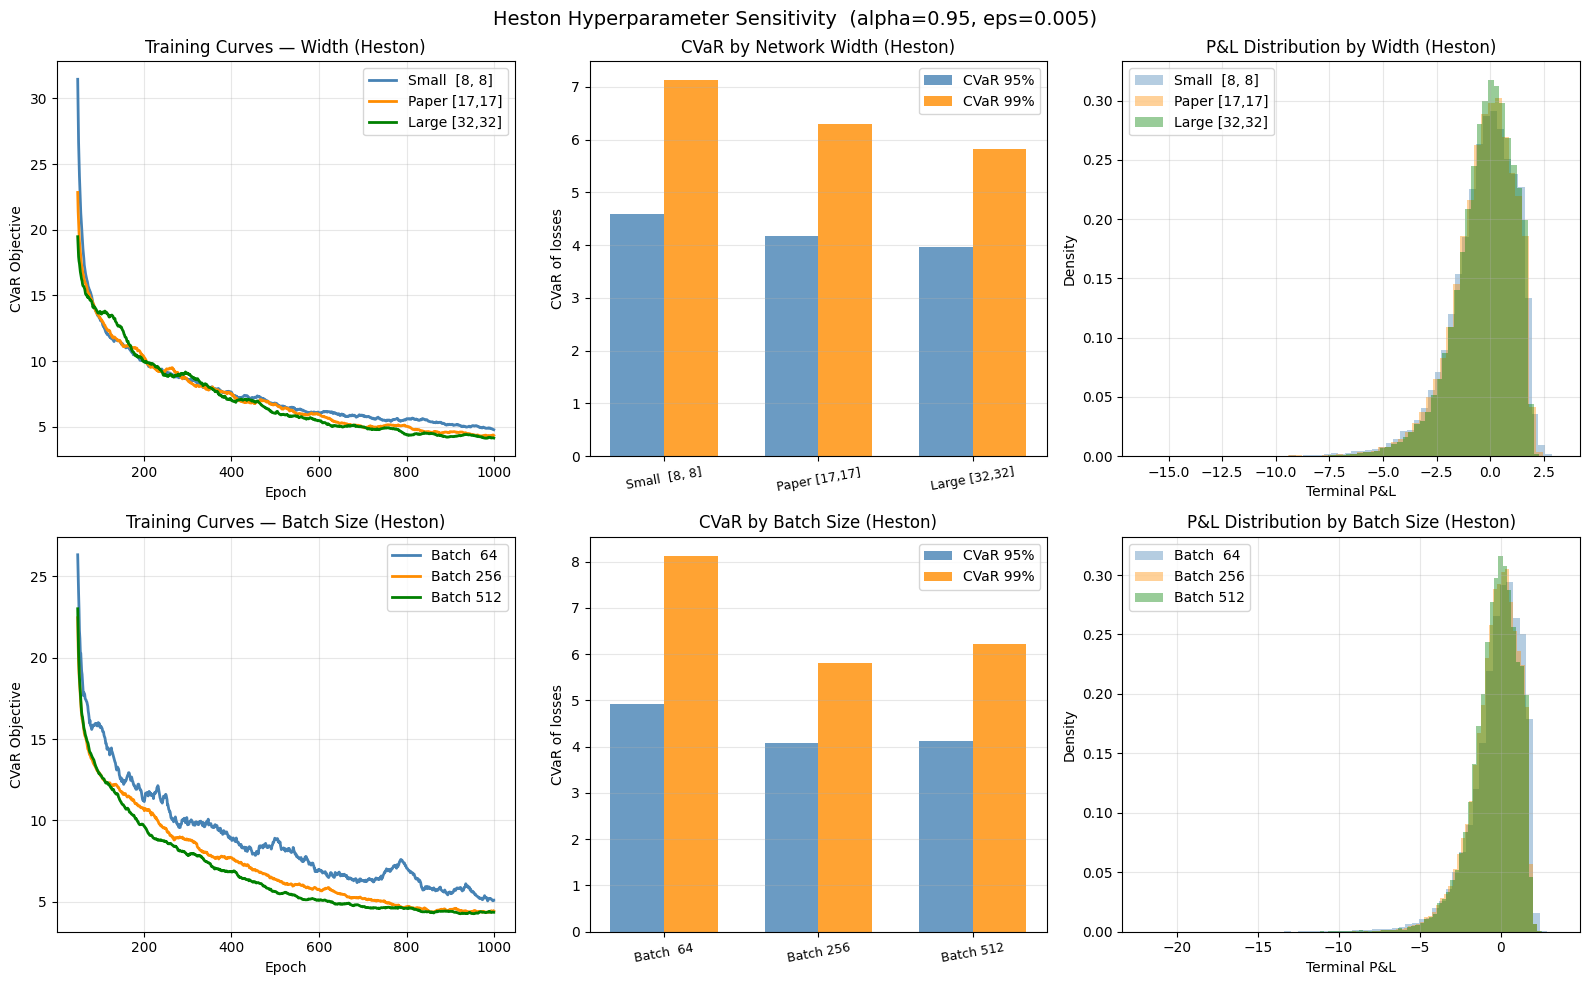

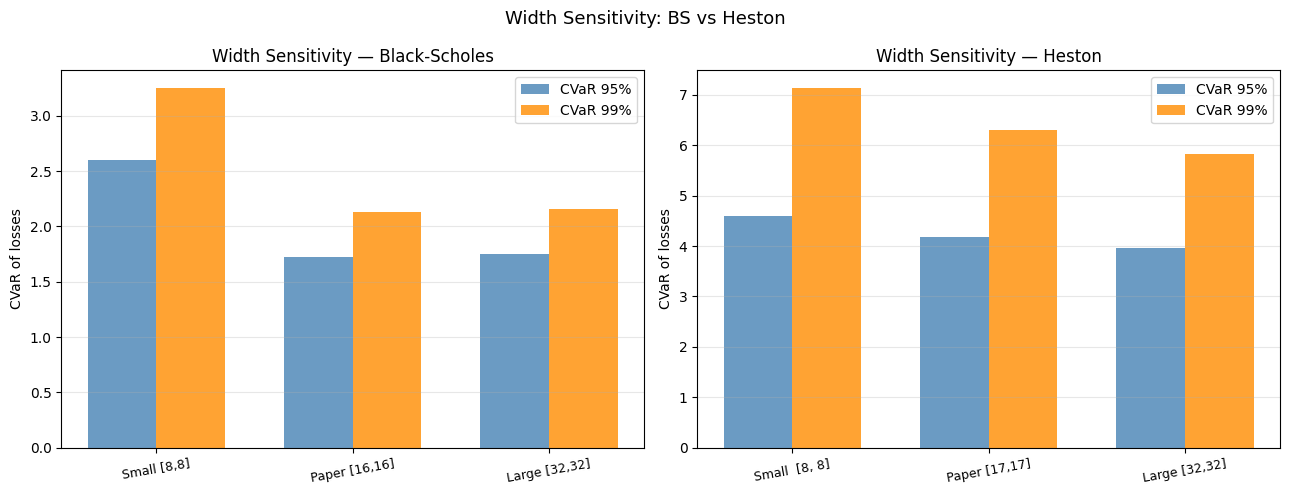

In [31]:
# ============================================================
# Heston Hyperparameter Sensitivity
# ============================================================

# ── A. Network width sensitivity ─────────────────────────────
print("--- Heston Network Width Sensitivity ---")

width_configs_h = {
    'Small  [8, 8]':   [8,  8],
    'Paper [17,17]':   [17, 17],   # paper default for Heston (d+15 = 2+15)
    'Large [32,32]':   [32, 32],
}
width_results_h = {}

for name, hdim in width_configs_h.items():
    print(f"\n  Training: {name}")
    train_out = train_model(
        env_type='heston', S0=S0, K=K, r=r, T=T, steps=steps,
        epsilon=epsilon, batch_size=batch_size, n_epochs=n_epochs,
        lr=learning_rate, hidden_dims=hdim,
        v0=v0, kappa=kappa, theta=theta, sigma_v=sigma_v, rho=rho,
        premium=premium_h, alpha=0.95, loss_type='cvar',
        policy_type=policy_type, use_batch_norm=use_batch_norm)

    metrics, pnl, _ = evaluate_model(
        train_out["model"], 'heston', test_paths_h, K,
        epsilon=epsilon, S0=S0, T=T,
        test_vols=test_vols_h, test_paths2=test_S2_h,
        premium=premium_h, v0=v0)

    width_results_h[name] = {
        "CVaR (95%)":   metrics["Loss CVaR (95%)"],
        "CVaR (99%)":   metrics["Loss CVaR (99%)"],
        "Turnover":     metrics["Turnover"],
        "Mean PnL":     metrics["Mean PnL"],
        "Std PnL":      metrics["Std PnL"],
        "loss_history": train_out["loss_history"],
        "pnl":          pnl,
    }

# ── B. Batch size sensitivity ─────────────────────────────────
print("\n--- Heston Batch Size Sensitivity ---")

batch_configs_h = {
    'Batch  64':  64,
    'Batch 256':  256,   # paper default
    'Batch 512':  512,
}
batch_results_h = {}

for name, bsize in batch_configs_h.items():
    print(f"\n  Training: {name}")
    train_out = train_model(
        env_type='heston', S0=S0, K=K, r=r, T=T, steps=steps,
        epsilon=epsilon, batch_size=bsize, n_epochs=n_epochs,
        lr=learning_rate, hidden_dims=hidden_dim_heston,
        v0=v0, kappa=kappa, theta=theta, sigma_v=sigma_v, rho=rho,
        premium=premium_h, alpha=0.95, loss_type='cvar',
        policy_type=policy_type, use_batch_norm=use_batch_norm)

    metrics, pnl, _ = evaluate_model(
        train_out["model"], 'heston', test_paths_h, K,
        epsilon=epsilon, S0=S0, T=T,
        test_vols=test_vols_h, test_paths2=test_S2_h,
        premium=premium_h, v0=v0)

    batch_results_h[name] = {
        "CVaR (95%)":   metrics["Loss CVaR (95%)"],
        "CVaR (99%)":   metrics["Loss CVaR (99%)"],
        "Turnover":     metrics["Turnover"],
        "Mean PnL":     metrics["Mean PnL"],
        "Std PnL":      metrics["Std PnL"],
        "loss_history": train_out["loss_history"],
        "pnl":          pnl,
    }

# ── C. Numeric summary tables ─────────────────────────────────
print("\n=== HESTON WIDTH SENSITIVITY (alpha=0.95, eps=0.005) ===")
print(f"{'Config':<18} | {'Mean PnL':>10} | {'Std PnL':>10} | "
      f"{'CVaR(95%)':>10} | {'CVaR(99%)':>10} | {'Turnover':>10}")
print("-" * 75)
for name, res in width_results_h.items():
    print(f"{name:<18} | {res['Mean PnL']:>10.4f} | {res['Std PnL']:>10.4f} | "
          f"{res['CVaR (95%)']:>10.4f} | {res['CVaR (99%)']:>10.4f} | "
          f"{res['Turnover']:>10.4f}")

print("\n=== HESTON BATCH SIZE SENSITIVITY (alpha=0.95, eps=0.005) ===")
print(f"{'Config':<18} | {'Mean PnL':>10} | {'Std PnL':>10} | "
      f"{'CVaR(95%)':>10} | {'CVaR(99%)':>10} | {'Turnover':>10}")
print("-" * 75)
for name, res in batch_results_h.items():
    print(f"{name:<18} | {res['Mean PnL']:>10.4f} | {res['Std PnL']:>10.4f} | "
          f"{res['CVaR (95%)']:>10.4f} | {res['CVaR (99%)']:>10.4f} | "
          f"{res['Turnover']:>10.4f}")

# ── D. Plots ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

colors_w = ['steelblue', 'darkorange', 'green']
colors_b = ['steelblue', 'darkorange', 'green']

# ── Row 1: Width sensitivity ──────────────────────────────────

# D1. Training curves — width
ax = axes[0, 0]
for (name, res), col in zip(width_results_h.items(), colors_w):
    loss_hist = np.asarray(res["loss_history"])
    window    = 50
    smoothed  = np.convolve(loss_hist, np.ones(window) / window, mode="valid")
    ax.plot(np.arange(window - 1, len(loss_hist)), smoothed,
            linewidth=2, color=col, label=name)
ax.set_title("Training Curves — Width (Heston)")
ax.set_xlabel("Epoch"); ax.set_ylabel("CVaR Objective")
ax.legend(); ax.grid(True, alpha=0.3)

# D2. CVaR bar chart — width
ax = axes[0, 1]
names_w  = list(width_results_h.keys())
cvar95_w = [width_results_h[n]["CVaR (95%)"] for n in names_w]
cvar99_w = [width_results_h[n]["CVaR (99%)"] for n in names_w]
x        = np.arange(len(names_w))
width_b  = 0.35
ax.bar(x - width_b/2, cvar95_w, width_b, label='CVaR 95%', color='steelblue', alpha=0.8)
ax.bar(x + width_b/2, cvar99_w, width_b, label='CVaR 99%', color='darkorange', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(names_w, rotation=10, fontsize=9)
ax.set_ylabel("CVaR of losses")
ax.set_title("CVaR by Network Width (Heston)")
ax.legend(); ax.grid(True, alpha=0.3, axis='y')

# D3. P&L distributions — width
ax = axes[0, 2]
for (name, res), col in zip(width_results_h.items(), colors_w):
    ax.hist(res["pnl"], bins=60, density=True, alpha=0.4, color=col, label=name)
ax.set_title("P&L Distribution by Width (Heston)")
ax.set_xlabel("Terminal P&L"); ax.set_ylabel("Density")
ax.legend(); ax.grid(True, alpha=0.3)

# ── Row 2: Batch size sensitivity ────────────────────────────

# D4. Training curves — batch size
ax = axes[1, 0]
for (name, res), col in zip(batch_results_h.items(), colors_b):
    loss_hist = np.asarray(res["loss_history"])
    window    = 50
    smoothed  = np.convolve(loss_hist, np.ones(window) / window, mode="valid")
    ax.plot(np.arange(window - 1, len(loss_hist)), smoothed,
            linewidth=2, color=col, label=name)
ax.set_title("Training Curves — Batch Size (Heston)")
ax.set_xlabel("Epoch"); ax.set_ylabel("CVaR Objective")
ax.legend(); ax.grid(True, alpha=0.3)

# D5. CVaR bar chart — batch size
ax = axes[1, 1]
names_b  = list(batch_results_h.keys())
cvar95_b = [batch_results_h[n]["CVaR (95%)"] for n in names_b]
cvar99_b = [batch_results_h[n]["CVaR (99%)"] for n in names_b]
x        = np.arange(len(names_b))
ax.bar(x - width_b/2, cvar95_b, width_b, label='CVaR 95%', color='steelblue', alpha=0.8)
ax.bar(x + width_b/2, cvar99_b, width_b, label='CVaR 99%', color='darkorange', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(names_b, rotation=10, fontsize=9)
ax.set_ylabel("CVaR of losses")
ax.set_title("CVaR by Batch Size (Heston)")
ax.legend(); ax.grid(True, alpha=0.3, axis='y')

# D6. P&L distributions — batch size
ax = axes[1, 2]
for (name, res), col in zip(batch_results_h.items(), colors_b):
    ax.hist(res["pnl"], bins=60, density=True, alpha=0.4, color=col, label=name)
ax.set_title("P&L Distribution by Batch Size (Heston)")
ax.set_xlabel("Terminal P&L"); ax.set_ylabel("Density")
ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle("Heston Hyperparameter Sensitivity  (alpha=0.95, eps=0.005)", fontsize=14)
plt.tight_layout()
plt.show()

# ── E. Side-by-side comparison with BS sensitivity ───────────
try:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # BS width results (from cell 66)
    names_bs_w  = list(width_results.keys())
    cvar95_bs_w = [width_results[n]["CVaR (95%)"] for n in names_bs_w]
    x_bs = np.arange(len(names_bs_w))

    axes[0].bar(x_bs - width_b/2, cvar95_bs_w, width_b,
                label='CVaR 95%', color='steelblue', alpha=0.8)
    axes[0].bar(x_bs + width_b/2,
                [width_results[n]["CVaR (99%)"] for n in names_bs_w],
                width_b, label='CVaR 99%', color='darkorange', alpha=0.8)
    axes[0].set_xticks(x_bs)
    axes[0].set_xticklabels(names_bs_w, rotation=10, fontsize=9)
    axes[0].set_ylabel("CVaR of losses")
    axes[0].set_title("Width Sensitivity — Black-Scholes")
    axes[0].legend(); axes[0].grid(True, alpha=0.3, axis='y')

    x_h = np.arange(len(names_w))
    axes[1].bar(x_h - width_b/2, cvar95_w, width_b,
                label='CVaR 95%', color='steelblue', alpha=0.8)
    axes[1].bar(x_h + width_b/2, cvar99_w, width_b,
                label='CVaR 99%', color='darkorange', alpha=0.8)
    axes[1].set_xticks(x_h)
    axes[1].set_xticklabels(names_w, rotation=10, fontsize=9)
    axes[1].set_ylabel("CVaR of losses")
    axes[1].set_title("Width Sensitivity — Heston")
    axes[1].legend(); axes[1].grid(True, alpha=0.3, axis='y')

    plt.suptitle("Width Sensitivity: BS vs Heston", fontsize=13)
    plt.tight_layout()
    plt.show()

except NameError:
    print("Note: run BS sensitivity (cell 66) first to see BS vs Heston comparison.")

## Asymptotic movements 

### Black & Scholes

In Section 5.3 of the paper, the authors prove that their deep hedging framework successfully learns the theoretical asymptotic convergence of transaction costs. Specifically, as proportional transaction costs ($\epsilon$) approach zero, the difference between the utility indifference price with costs ($p_\epsilon$) and the frictionless price ($p_0$) scales at a rate of $O(\epsilon^{2/3})$.

We replicate this by training the network over a decreasing sequence of $\epsilon$ values using the Entropic Risk Measure, and plotting the log-differences to extract the regression slope. We expect a slope of approximately 0.67.

--- Running Transaction Cost Asymptotics O(eps^(2/3)) ---
Epsilon sequence: ['0.01562', '0.00781', '0.00391', '0.00195', '0.00098']

Training for epsilon = 0.01562...


Training BS (ENTROPIC):   0%|          | 0/500 [00:00<?, ?it/s]

Training completed in 13.5s | device: cuda | epochs: 500 | batch: 256


Training BS (ENTROPIC):   0%|          | 0/500 [00:00<?, ?it/s]

Training completed in 30.0s | device: cuda | epochs: 500 | batch: 256
  p_eps=4.248894 | p0=2.493378 | p_eps - p0=1.755516e+00

Training for epsilon = 0.00781...


...

Training completed in 28.3s | device: cuda | epochs: 500 | batch: 256
  p_eps=2.742177 | p0=2.493378 | p_eps - p0=2.487993e-01

Training for epsilon = 0.00098...


Training BS (ENTROPIC):   0%|          | 0/500 [00:00<?, ?it/s]

Training completed in 29.2s | device: cuda | epochs: 500 | batch: 256


Training BS (ENTROPIC):   0%|          | 0/500 [00:00<?, ?it/s]

Training completed in 28.5s | device: cuda | epochs: 500 | batch: 256
  p_eps=2.611326 | p0=2.493378 | p_eps - p0=1.179485e-01

Empirical slope: 0.978
Theoretical slope: 0.667
Points used: 5/5


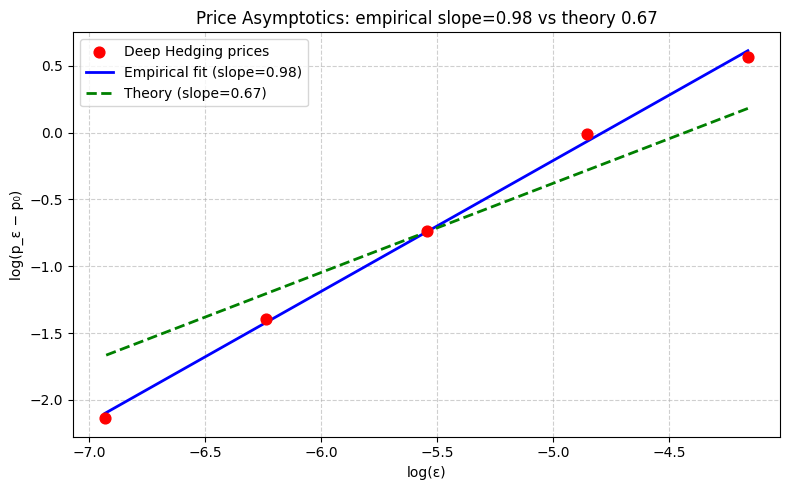

In [32]:
# ============================================================
# EXPERIMENT 6: Transaction Cost Asymptotics O(ε^{2/3})
# Purpose: verify theoretical indifference price scaling
# Paper Section 5.3 — Figure 10 equivalent
# ============================================================

print("--- Running Transaction Cost Asymptotics O(eps^(2/3)) ---")

# Frictionless baseline price p0 = BS risk-neutral price
# Paper justification: in continuous time p^0 = q (risk-neutral price)
p0 = premium_bs   # already a float — no .item() needed

# Epsilon sequence matching paper log-scale axis (~[-7, -4.5])
# 2^{-6}, 2^{-7}, 2^{-8}, 2^{-9}, 2^{-10}
epsilons = [2**(-i-5) for i in range(1, 6)]
print(f"Epsilon sequence: {[f'{e:.5f}' for e in epsilons]}")

price_diffs = []
valid_eps   = []

# Use fewer epochs — we only need the slope, not perfect convergence
n_epochs_asym = 500

for eps in epsilons:
    print(f"\nTraining for epsilon = {eps:.5f}...")

    # ── Train WITH option liability: approximates π(-Z) ──────
    train_out_with = train_model(env_type='bs', S0=S0, K=K, r=r, T=T, steps=steps,
                                 epsilon=eps, batch_size=batch_size, n_epochs=n_epochs_asym,
                                 lr=learning_rate, sigma=sigma,
                                 loss_type='entropic', lambda_param=1.0,
                                 premium=0.0, include_payoff=True,
                                 policy_type=policy_type, use_batch_norm=use_batch_norm,
                                 hidden_dims=hidden_dim_bs)

    _, pnl_with, _ = evaluate_model(train_out_with["model"], 'bs', test_paths_bs, K,
                                    epsilon=eps, S0=S0, T=T,
                                    premium=0.0, include_payoff=True)
    risk_with = entropic_loss(to_tensor(pnl_with), lambda_param=1.0).item()

    # ── Train WITHOUT option liability: approximates π(0) ────
    train_out_without = train_model(env_type='bs', S0=S0, K=K, r=r, T=T, steps=steps,
                                    epsilon=eps, batch_size=batch_size, n_epochs=n_epochs_asym,
                                    lr=learning_rate, sigma=sigma,
                                    loss_type='entropic', lambda_param=1.0,
                                    premium=0.0, include_payoff=False,
                                    policy_type=policy_type, use_batch_norm=use_batch_norm,
                                    hidden_dims=hidden_dim_bs)

    _, pnl_without, _ = evaluate_model(train_out_without["model"], 'bs', test_paths_bs, K,
                                       epsilon=eps, S0=S0, T=T,
                                       premium=0.0, include_payoff=False)
    risk_without = entropic_loss(to_tensor(pnl_without), lambda_param=1.0).item()

    # Indifference price: p(Z) = π(-Z) - π(0)
    p_eps = risk_with - risk_without
    diff  = p_eps - p0
    print(f"  p_eps={p_eps:.6f} | p0={p0:.6f} | p_eps - p0={diff:.6e}")

    if diff > 0:
        valid_eps.append(eps)
        price_diffs.append(diff)
    else:
        print("  Skipping: p_eps - p0 <= 0 (training noise)")

# ── Log-log regression + plot ─────────────────────────────────
if len(valid_eps) < 2:
    print("Not enough valid points for regression.")
else:
    log_eps   = np.log(np.array(valid_eps))
    log_diffs = np.log(np.array(price_diffs))

    slope_emp, intercept_emp = np.polyfit(log_eps, log_diffs, 1)
    slope_theory             = 2 / 3
    intercept_theory         = np.mean(log_diffs - slope_theory * log_eps)

    print(f"\nEmpirical slope: {slope_emp:.3f}")
    print(f"Theoretical slope: {slope_theory:.3f}")
    print(f"Points used: {len(valid_eps)}/{len(epsilons)}")

    plt.figure(figsize=(8, 5))
    plt.scatter(log_eps, log_diffs, color='red', zorder=5,
                s=60, label='Deep Hedging prices')
    plt.plot(log_eps, slope_emp * log_eps + intercept_emp,
             color='blue', linewidth=2,
             label=f'Empirical fit (slope={slope_emp:.2f})')
    plt.plot(log_eps, slope_theory * log_eps + intercept_theory,
             color='green', linestyle='--', linewidth=2,
             label='Theory (slope=0.67)')
    plt.xlabel('log(ε)'); plt.ylabel('log(p_ε − p₀)')
    plt.title(f'Price Asymptotics: empirical slope={slope_emp:.2f} vs theory 0.67')
    plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout(); plt.show()

### Heston Price Asymptotics $O(\epsilon^{2/3})$

Paper Section 5.3 — Figure 11 equivalent.

As proportional transaction costs ε → 0, the exponential utility indifference
price p_ε converges to the frictionless price p₀ at the theoretical rate:

    p_ε − p₀ = O(ε^{2/3})

The paper verifies this numerically for Black-Scholes (Figure 10, slope ≈ 0.67)
and then extends it to Heston with d=2 hedging instruments (Figure 11, slope ≈ 0.71),
for which no theoretical result existed at the time of publication.

We replicate Figure 11 here: train the entropic deep hedging model at five
decreasing ε values, recover the indifference price at each point as
p_ε = π(-Z; ε) − π(0; ε), and fit a line in log-log space.

--- Heston Price Asymptotics O(eps^{2/3}) ---
Epsilon sequence: ['0.01562', '0.00781', '0.00391', '0.00195', '0.00098']

--- epsilon = 0.01562 ---
  Training with option payoff...


Training HESTON (ENTROPIC):   0%|          | 0/500 [00:00<?, ?it/s]

Training completed in 37.2s | device: cuda | epochs: 500 | batch: 256
  Training without option payoff...


Training HESTON (ENTROPIC):   0%|          | 0/500 [00:00<?, ?it/s]

Training completed in 39.6s | device: cuda | epochs: 500 | batch: 256
  π(-Z)=10.297855 | π(0)=0.280607 | p_ε=10.017248 | p₀=1.955174 | p_ε−p₀=8.0621e+00

--- epsilon = 0.00781 ---
  Training with option payoff...


...

Training completed in 40.0s | device: cuda | epochs: 500 | batch: 256
  π(-Z)=10.520584 | π(0)=0.083399 | p_ε=10.437185 | p₀=1.955174 | p_ε−p₀=8.4820e+00

--- epsilon = 0.00098 ---
  Training with option payoff...


Training HESTON (ENTROPIC):   0%|          | 0/500 [00:00<?, ?it/s]

Training completed in 32.1s | device: cuda | epochs: 500 | batch: 256
  Training without option payoff...


Training HESTON (ENTROPIC):   0%|          | 0/500 [00:00<?, ?it/s]

Training completed in 21.4s | device: cuda | epochs: 500 | batch: 256
  π(-Z)=12.215128 | π(0)=0.032878 | p_ε=12.182250 | p₀=1.955174 | p_ε−p₀=1.0227e+01

5/5 valid points for regression
Heston empirical slope : -0.022
Theoretical slope      : 0.667
Paper reported slope   : 0.71  (Figure 11)

   epsilon |      p_eps |   p_eps - p0 |   log(eps) |  log(diff)
------------------------------------------------------------
   0.01562 |   1.970799 | 8.062074e+00 |    -4.1589 |     2.0872
   0.00781 |   1.962987 | 1.170923e+01 |    -4.8520 |     2.4604
   0.00391 |   1.959081 | 7.925593e+00 |    -5.5452 |     2.0701
   0.00195 |   1.957128 | 8.482011e+00 |    -6.2383 |     2.1379
   0.00098 |   1.956151 | 1.022708e+01 |    -6.9315 |     2.3250


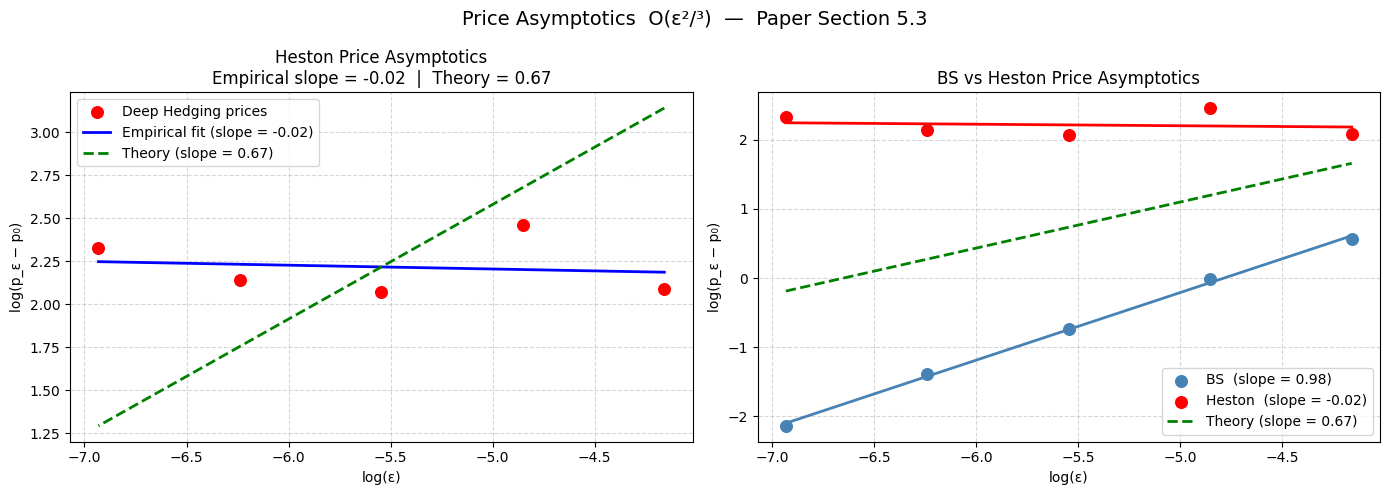

In [33]:
# ============================================================
# Heston Asymptotics O(ε^{2/3})  — Paper Section 5.3, Figure 11
# ============================================================

print("--- Heston Price Asymptotics O(eps^{2/3}) ---")

# p0: frictionless Heston indifference price.
# In continuous time this equals the risk-neutral price, so we use premium_h.
p0_h = float(premium_h)

# Epsilon sequence — same log-scale as the BS experiment and the paper
# 2^{-6}, 2^{-7}, 2^{-8}, 2^{-9}, 2^{-10}
epsilons_h = [2**(-i - 5) for i in range(1, 6)]
print(f"Epsilon sequence: {[f'{e:.5f}' for e in epsilons_h]}")

price_diffs_h = []
valid_eps_h   = []

# Fewer epochs — we only need the slope, not perfect convergence
n_epochs_asym_h = 500

for eps in epsilons_h:
    print(f"\n--- epsilon = {eps:.5f} ---")

    # ── π(-Z ; ε): hedge WITH the option liability ────────────
    print("  Training with option payoff...")
    out_with_h = train_model(
        env_type='heston', S0=S0, K=K, r=r, T=T, steps=steps,
        epsilon=eps, batch_size=batch_size, n_epochs=n_epochs_asym_h,
        lr=learning_rate, hidden_dims=hidden_dim_heston,
        v0=v0, kappa=kappa, theta=theta, sigma_v=sigma_v, rho=rho,
        premium=0.0, include_payoff=True,
        loss_type='entropic', lambda_param=1.0,
        policy_type=policy_type, use_batch_norm=use_batch_norm)

    _, pnl_with_h, _ = evaluate_model(
        out_with_h["model"], 'heston', test_paths_h, K,
        epsilon=eps, S0=S0, T=T,
        test_vols=test_vols_h, test_paths2=test_S2_h,
        premium=0.0, include_payoff=True, v0=v0)

    risk_with_h = entropic_loss(to_tensor(pnl_with_h), lambda_param=1.0).item()

    # ── π(0 ; ε): hedge WITHOUT the option liability ──────────
    print("  Training without option payoff...")
    out_without_h = train_model(
        env_type='heston', S0=S0, K=K, r=r, T=T, steps=steps,
        epsilon=eps, batch_size=batch_size, n_epochs=n_epochs_asym_h,
        lr=learning_rate, hidden_dims=hidden_dim_heston,
        v0=v0, kappa=kappa, theta=theta, sigma_v=sigma_v, rho=rho,
        premium=0.0, include_payoff=False,
        loss_type='entropic', lambda_param=1.0,
        policy_type=policy_type, use_batch_norm=use_batch_norm)

    _, pnl_without_h, _ = evaluate_model(
        out_without_h["model"], 'heston', test_paths_h, K,
        epsilon=eps, S0=S0, T=T,
        test_vols=test_vols_h, test_paths2=test_S2_h,
        premium=0.0, include_payoff=False, v0=v0)

    risk_without_h = entropic_loss(to_tensor(pnl_without_h), lambda_param=1.0).item()

    # ── Indifference price at this ε ─────────────────────────
    # p(Z; ε) = π(-Z; ε) − π(0; ε)   [paper eq. 3.2]
    p_eps_h = risk_with_h - risk_without_h
    diff_h  = p_eps_h - p0_h

    print(f"  π(-Z)={risk_with_h:.6f} | π(0)={risk_without_h:.6f} "
          f"| p_ε={p_eps_h:.6f} | p₀={p0_h:.6f} | p_ε−p₀={diff_h:.4e}")

    if diff_h > 0:
        valid_eps_h.append(eps)
        price_diffs_h.append(diff_h)
    else:
        print("  Skipping: p_ε − p₀ ≤ 0 (training noise at very small ε)")

# ── Log-log regression + plot ─────────────────────────────────
print(f"\n{len(valid_eps_h)}/{len(epsilons_h)} valid points for regression")

if len(valid_eps_h) < 2:
    print("Not enough valid points — increase n_epochs_asym_h or use larger epsilons.")
else:
    log_eps_h   = np.log(np.array(valid_eps_h))
    log_diffs_h = np.log(np.array(price_diffs_h))

    # Empirical slope via OLS
    slope_h, intercept_h = np.polyfit(log_eps_h, log_diffs_h, 1)

    # Theoretical reference line (slope = 2/3), shifted to pass through data centroid
    slope_theory    = 2 / 3
    intercept_theory = np.mean(log_diffs_h - slope_theory * log_eps_h)

    print(f"Heston empirical slope : {slope_h:.3f}")
    print(f"Theoretical slope      : {slope_theory:.3f}")
    print(f"Paper reported slope   : 0.71  (Figure 11)")

    # ── Numeric summary table ─────────────────────────────────
    print(f"\n{'epsilon':>10} | {'p_eps':>10} | {'p_eps - p0':>12} | {'log(eps)':>10} | {'log(diff)':>10}")
    print("-" * 60)
    for eps, diff in zip(valid_eps_h, price_diffs_h):
        print(f"{eps:>10.5f} | {eps + p0_h:>10.6f} | {diff:>12.6e} | "
              f"{np.log(eps):>10.4f} | {np.log(diff):>10.4f}")

    # ── Plot ──────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: log-log plot (paper Figure 11 equivalent)
    axes[0].scatter(log_eps_h, log_diffs_h,
                    color='red', s=70, zorder=5, label='Deep Hedging prices')
    axes[0].plot(log_eps_h, slope_h * log_eps_h + intercept_h,
                 color='blue', linewidth=2,
                 label=f'Empirical fit (slope = {slope_h:.2f})')
    axes[0].plot(log_eps_h, slope_theory * log_eps_h + intercept_theory,
                 color='green', linestyle='--', linewidth=2,
                 label='Theory (slope = 0.67)')
    axes[0].set_xlabel('log(ε)')
    axes[0].set_ylabel('log(p_ε − p₀)')
    axes[0].set_title(f'Heston Price Asymptotics\nEmpirical slope = {slope_h:.2f}  |  Theory = 0.67')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.5)

    # Right: side-by-side comparison with the BS result from cell 78
    # (reuses valid_eps / price_diffs computed there — skip if not available)
    try:
        log_eps_bs   = np.log(np.array(valid_eps))
        log_diffs_bs = np.log(np.array(price_diffs))
        slope_bs, intercept_bs = np.polyfit(log_eps_bs, log_diffs_bs, 1)
        intercept_bs_theory = np.mean(log_diffs_bs - slope_theory * log_eps_bs)

        axes[1].scatter(log_eps_bs, log_diffs_bs,
                        color='steelblue', s=70, zorder=5,
                        label=f'BS  (slope = {slope_bs:.2f})')
        axes[1].plot(log_eps_bs, slope_bs * log_eps_bs + intercept_bs,
                     color='steelblue', linewidth=2)
        axes[1].scatter(log_eps_h, log_diffs_h,
                        color='red', s=70, zorder=5,
                        label=f'Heston  (slope = {slope_h:.2f})')
        axes[1].plot(log_eps_h, slope_h * log_eps_h + intercept_h,
                     color='red', linewidth=2)

        # shared theory line
        all_log_eps = np.concatenate([log_eps_bs, log_eps_h])
        x_line      = np.linspace(all_log_eps.min(), all_log_eps.max(), 50)
        intercept_shared = np.mean(
            np.concatenate([log_diffs_bs, log_diffs_h]) -
            slope_theory * all_log_eps)
        axes[1].plot(x_line, slope_theory * x_line + intercept_shared,
                     'g--', linewidth=2, label='Theory (slope = 0.67)')

        axes[1].set_xlabel('log(ε)')
        axes[1].set_ylabel('log(p_ε − p₀)')
        axes[1].set_title('BS vs Heston Price Asymptotics')
        axes[1].legend()
        axes[1].grid(True, linestyle='--', alpha=0.5)

    except NameError:
        # BS asymptotics not yet computed — show Heston only
        axes[1].axis('off')
        axes[1].text(0.5, 0.5, 'Run BS asymptotics\n(cell 78) to see\nside-by-side comparison',
                     ha='center', va='center', fontsize=12, transform=axes[1].transAxes)

    plt.suptitle('Price Asymptotics  O(ε²/³)  —  Paper Section 5.3', fontsize=14)
    plt.tight_layout()
    plt.show()